alpha

In [58]:
import torch
import numpy as np
from pathlib import Path
seeds = list(range(30))
alphas = [0.1,0.5,1.0,2,5,10]
 #/nfs/gatsbystor/cdomine/cifar_testing/cifar/main_3/
n_samples=[10, 20, 50, 100, 200, 500, 1000]
#random_seed=0--mode=finetuning--n_samples=10--alpha=1.0--alpha_policy=first_vs_rest--model=resnet
base_path = Path("/nfs/gatsbystor/cdomine/cifar_testing/cifar/extentions_all_pretrain_block_123/")
 #base_path = Path("/nfs/nhome/live/cdomine/nested_feature/experiments/cifar/data/cifar/main_3/")

 
run_data = {
    'losses': {a:{s: [] for s in n_samples} for a in alphas},
    'accs': {a: {s: [] for s in n_samples} for a in alphas},
    'models': {a: {s: [] for s in n_samples} for a in alphas},
    'l2_regs': {a: {s: [] for s in n_samples} for a in alphas}
}
for alpha in alphas:
    for seed in seeds:
        for n_sample in n_samples :
            folder_name = (
                f"random_seed={seed}--mode=finetuning--n_samples={n_sample}--alpha_load={alpha}"
            )
    
            dir_path = base_path / folder_name
            if dir_path.exists():
              #    print(f" {seed}, Alpha {alpha}, Sample {n_sample}, Accs"),
                # Load and append data to the lists
                if (dir_path / "losses.npy").exists():
                    run_data['losses'][alpha][n_sample].append(np.load(dir_path / "losses.npy",allow_pickle=True))
                    print(f"✅ Loaded Seed {seed}, Alpha {alpha}, Sample {n_sample}, Losses")
                if (dir_path / "l2_regs.npy").exists():
                    run_data['l2_regs'][alpha][n_sample].append(np.load(dir_path / "l2_regs.npy",allow_pickle=True))
                    print(f"✅ Loaded Seed {seed}, Alpha {alpha}, Sample {n_sample}, l2_regs")
                if (dir_path / "accs.npy").exists():
                    run_data['accs'][alpha][n_sample].append(np.load(dir_path / "accs.npy",allow_pickle=True))
                   #   print(f"✅ Loaded Seed {seed}, Alpha {alpha}, Sample {n_sample}, Accs"),
            else:
                print(f"Missing directory: {folder_name}")


✅ Loaded Seed 0, Alpha 0.1, Sample 10, Losses
✅ Loaded Seed 0, Alpha 0.1, Sample 20, Losses
✅ Loaded Seed 0, Alpha 0.1, Sample 50, Losses
✅ Loaded Seed 0, Alpha 0.1, Sample 100, Losses
✅ Loaded Seed 0, Alpha 0.1, Sample 200, Losses
✅ Loaded Seed 0, Alpha 0.1, Sample 500, Losses
✅ Loaded Seed 0, Alpha 0.1, Sample 1000, Losses
✅ Loaded Seed 1, Alpha 0.1, Sample 10, Losses
✅ Loaded Seed 1, Alpha 0.1, Sample 20, Losses
✅ Loaded Seed 1, Alpha 0.1, Sample 50, Losses
✅ Loaded Seed 1, Alpha 0.1, Sample 100, Losses
✅ Loaded Seed 1, Alpha 0.1, Sample 200, Losses
✅ Loaded Seed 1, Alpha 0.1, Sample 500, Losses
✅ Loaded Seed 1, Alpha 0.1, Sample 1000, Losses
✅ Loaded Seed 2, Alpha 0.1, Sample 10, Losses
✅ Loaded Seed 2, Alpha 0.1, Sample 20, Losses
✅ Loaded Seed 2, Alpha 0.1, Sample 50, Losses
✅ Loaded Seed 2, Alpha 0.1, Sample 100, Losses
✅ Loaded Seed 2, Alpha 0.1, Sample 200, Losses
✅ Loaded Seed 2, Alpha 0.1, Sample 500, Losses
✅ Loaded Seed 2, Alpha 0.1, Sample 1000, Losses
✅ Loaded Seed 3, Al

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

def _err_from_vals(vals, error_type="se"):
    vals = np.asarray(vals, dtype=float)
    mean = float(np.mean(vals))
    std = float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0
    err = std if error_type == "std" else std / np.sqrt(len(vals))
    return mean, err

def plot_merged_run_and_csv(
    run_data,
    metric_name,
    type_val,
    alphas,
    seeds,
    samples,
    log_x=True,
    use_one_minus_acc=True,
    error_type="se",
):
    assert error_type in {"std", "se"}

    fig, ax = plt.subplots(figsize=(10, 6))

    # 1. Calculate inverse alphas and update LogNorm
    inv_alphas = [1.0 / a for a in alphas]
    cmap = plt.colormaps["viridis"]
    # We now normalize based on the range of 1/alpha
    norm = LogNorm(vmin=min(inv_alphas), vmax=max(inv_alphas))

    metric_lower = str(metric_name).lower()
    do_one_minus_run = use_one_minus_acc and ("acc" in metric_lower or "accuracy" in metric_lower)

    # --------- RUN_DATA PLOT ----------
    for alpha in alphas:
        inv_alpha = 1.0 / alpha # Define the transformed value
        means, errs = [], []

        for sample in samples:
            vals = []
            for seed in seeds:
                try:
                    data_matrix = run_data[metric_name][alpha][sample]
                    v = data_matrix[seed]
                    data_dict = v.item() if hasattr(v, "item") else v

                    y = np.max(data_dict[type_val])
                    if do_one_minus_run:
                        y = 1.0 - y

                    if y <= 0: continue
                    vals.append(y)

                except (KeyError, IndexError, TypeError, ValueError):
                    continue

            if len(vals) == 0:
                means.append(np.nan)
                errs.append(np.nan)
            else:
                m, e = _err_from_vals(vals, error_type)
                means.append(m)
                errs.append(e)

        if np.all(np.isnan(means)):
            continue

        # 2. Use inv_alpha for the label and the color mapping
        ax.errorbar(
            samples,
            means,
            yerr=errs,
            label=f"α = {inv_alpha:.2f}", 
            color=cmap(norm(inv_alpha)), 
            marker="o",
            linestyle="-",
            linewidth=2.5,
            capsize=4,
            alpha=0.95,
            zorder=3,
        )

    # --------- Styling ----------
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if log_x:
        ax.set_xscale("log")

    ax.set_xlabel("Sample Size", fontsize=11)
    # 3. Updated Y-label logic if needed, but keeping your request for 1-Acc
    ax.set_ylabel("1 − Accuracy" if do_one_minus_run else metric_name, fontsize=11)

    ax.legend(frameon=False, bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.yaxis.grid(True, linestyle="--", alpha=0.3)

    # 4. Optional: Updated Colorbar for 1/alpha
     # sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
     # sm.set_array([])
     # cbar = fig.colorbar(sm, ax=ax, pad=0.02)
     # cbar.set_label(r"$1/\alpha$", rotation=270, labelpad=15)

    plt.tight_layout()
    plt.show()

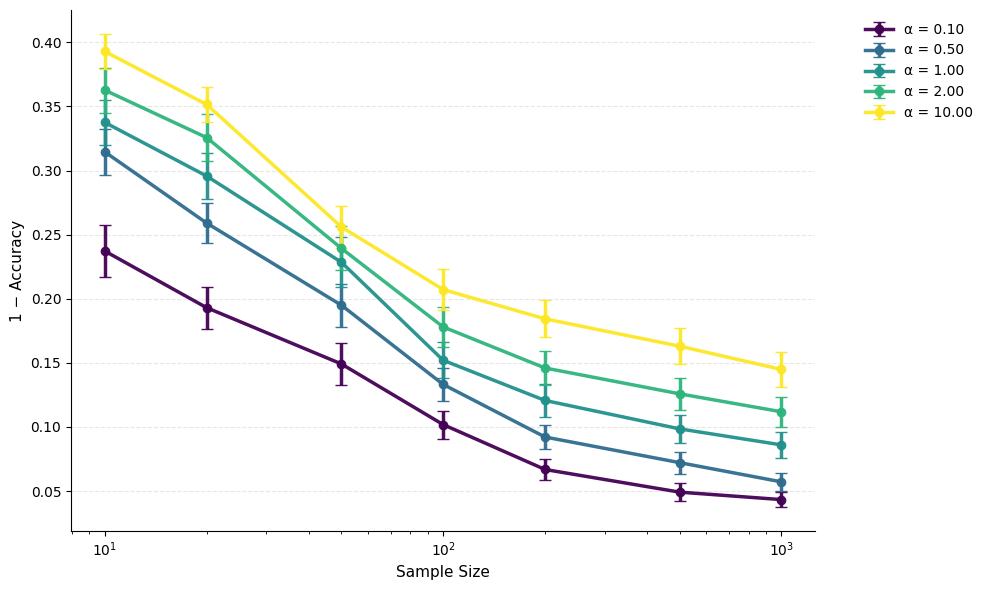

In [62]:
plot_merged_run_and_csv(
    run_data=run_data,
    #csv_path="/nfs/nhome/live/cdomine/nested_feature/experiments/cifar/data/cifar/resnet_acc_max.csv",
    metric_name="accs",
    type_val="valid",
    alphas = [10,2,1.0,0.5,0.1],

    seeds=list(range(30)),
    samples=[10, 20, 50, 100, 200, 500, 1000],
    error_type="se")

Gamma

In [ ]:

/nfs/scistore19/locatgrp/cdomine/multi-task/data/cifar/finetune_fc/
import torch
import numpy as np
from pathlib import Path
seeds = list(range(30))
alphas = [0.1,0.5,1.0,2,5,10]
 #/nfs/gatsbystor/cdomine/cifar_testing/cifar/main_3/
n_samples=[10, 20, 50, 100, 200, 500, 1000]
#random_seed=0--mode=finetuning--n_samples=10--alpha=1.0--alpha_policy=first_vs_rest--model=resnet
base_path = Path("/nfs/gatsbystor/cdomine/cifar_testing/cifar/extentions_all_pretrain_fc/")
 #base_path = Path("/nfs/nhome/live/cdomine/nested_feature/experiments/cifar/data/cifar/main_3/")

 
run_data = {
    'losses': {a:{s: [] for s in n_samples} for a in alphas},
    'accs': {a: {s: [] for s in n_samples} for a in alphas},
    'models': {a: {s: [] for s in n_samples} for a in alphas},
    'l2_regs': {a: {s: [] for s in n_samples} for a in alphas}
}
for alpha in alphas:
    for seed in seeds:
        for n_sample in n_samples :
            folder_name = (
                f"random_seed={seed}--mode=finetuning--n_samples={n_sample}--finetune_scaling_last={alpha}"
            )
            dir_path = base_path / folder_name
            if dir_path.exists():
              #    print(f" {seed}, Alpha {alpha}, Sample {n_sample}, Accs"),
                # Load and append data to the lists
                if (dir_path / "losses.npy").exists():
                    run_data['losses'][alpha][n_sample].append(np.load(dir_path / "losses.npy",allow_pickle=True))
                    print(f"✅ Loaded Seed {seed}, Alpha {alpha}, Sample {n_sample}, Losses")
                if (dir_path / "l2_regs.npy").exists():
                    run_data['l2_regs'][alpha][n_sample].append(np.load(dir_path / "l2_regs.npy",allow_pickle=True))
                    print(f"✅ Loaded Seed {seed}, Alpha {alpha}, Sample {n_sample}, l2_regs")
                if (dir_path / "accs.npy").exists():
                    run_data['accs'][alpha][n_sample].append(np.load(dir_path / "accs.npy",allow_pickle=True))
                   #   print(f"✅ Loaded Seed {seed}, Alpha {alpha}, Sample {n_sample}, Accs"),
            else:
                print(f"Missing directory: {folder_name}")

✅ Loaded Seed 0, Alpha 0.1, Sample 10, Losses
✅ Loaded Seed 0, Alpha 0.1, Sample 20, Losses
✅ Loaded Seed 0, Alpha 0.1, Sample 50, Losses
✅ Loaded Seed 0, Alpha 0.1, Sample 100, Losses
✅ Loaded Seed 0, Alpha 0.1, Sample 200, Losses
✅ Loaded Seed 0, Alpha 0.1, Sample 500, Losses
✅ Loaded Seed 0, Alpha 0.1, Sample 1000, Losses
✅ Loaded Seed 1, Alpha 0.1, Sample 10, Losses
✅ Loaded Seed 1, Alpha 0.1, Sample 20, Losses
✅ Loaded Seed 1, Alpha 0.1, Sample 50, Losses
✅ Loaded Seed 1, Alpha 0.1, Sample 100, Losses
✅ Loaded Seed 1, Alpha 0.1, Sample 200, Losses
✅ Loaded Seed 1, Alpha 0.1, Sample 500, Losses
✅ Loaded Seed 1, Alpha 0.1, Sample 1000, Losses
✅ Loaded Seed 2, Alpha 0.1, Sample 10, Losses
✅ Loaded Seed 2, Alpha 0.1, Sample 20, Losses
✅ Loaded Seed 2, Alpha 0.1, Sample 50, Losses
✅ Loaded Seed 2, Alpha 0.1, Sample 100, Losses
✅ Loaded Seed 2, Alpha 0.1, Sample 200, Losses
✅ Loaded Seed 2, Alpha 0.1, Sample 500, Losses
✅ Loaded Seed 2, Alpha 0.1, Sample 1000, Losses
✅ Loaded Seed 3, Al

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm


def _err_from_vals(vals, error_type="se"):
    vals = np.asarray(vals, dtype=float)
    mean = float(np.mean(vals))
    std = float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0
    err = std if error_type == "std" else std / np.sqrt(len(vals))
    return mean, err


def plot_merged_run_and_csv(
    run_data,
    metric_name,
    type_val,
    alphas,
    seeds,
    samples,
    log_x=True,
    use_one_minus_acc=True,
    error_type="se",
):
    assert error_type in {"std", "se"}

    fig, ax = plt.subplots(figsize=(10, 6))

    # ---- colormap with LOG-scaled alpha ----
    cmap = plt.colormaps["viridis"] if hasattr(plt, "colormaps") else plt.cm.get_cmap("viridis")
    norm = LogNorm(vmin=min(alphas), vmax=max(alphas))

    metric_lower = str(metric_name).lower()
    do_one_minus_run = use_one_minus_acc and ("acc" in metric_lower or "accuracy" in metric_lower)

    # --------- RUN_DATA PLOT ----------
    for alpha in alphas:
        means, errs = [], []

        for sample in samples:
            vals = []
            for seed in seeds:
                try:
                    data_matrix = run_data[metric_name][alpha][sample]
                    v = data_matrix[seed]
                    data_dict = v.item() if hasattr(v, "item") else v

                    y = np.max(data_dict[type_val])
                    if do_one_minus_run:
                        y = 1.0 - y

                    # protect log plots
                    if y <= 0:
                        continue

                    vals.append(y)

                except (KeyError, IndexError, TypeError, ValueError):
                    continue

            if len(vals) == 0:
                means.append(np.nan)
                errs.append(np.nan)
            else:
                m, e = _err_from_vals(vals, error_type)
                means.append(m)
                errs.append(e)

        if np.all(np.isnan(means)):
            print(f"[WARN] α={alpha} produced all-NaN. Skipping.")
            continue

        ax.errorbar(
            samples,
            means,
            yerr=errs,
            label=f"gamma={alpha}",
            color=cmap(norm(alpha)),
            marker="o",
            linestyle="-",
            linewidth=2.5,
            capsize=4,
            alpha=0.95,
            zorder=3,
        )

    # --------- Styling ----------
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if log_x:
        ax.set_xscale("log")

    ax.set_xlabel("Sample Size", fontsize=11)
    ax.set_ylabel("1 − Accuracy", fontsize=11)

    ax.legend(frameon=False)
    ax.yaxis.grid(True, linestyle="--", alpha=0.3)

    # --------- Log-scaled colorbar ----------
    # sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    # sm.set_array([])
    # cbar = plt.colorbar(sm, ax=ax, pad=0.02)
    # cbar.set_label("c_pt (alpha)", rotation=270, labelpad=15)

    plt.tight_layout()
    plt.show()
plot_merged_run_and_csv(
    run_data=run_data,
    #csv_path="/nfs/nhome/live/cdomine/nested_feature/experiments/cifar/data/cifar/resnet_acc_max.csv",
    metric_name="accs",
    type_val="valid",
    alphas = [0.1,0.5,1.0,2,10],
    seeds=list(range(30)),
    samples=[10, 20, 50, 100, 200, 500, 1000],
    error_type="se")

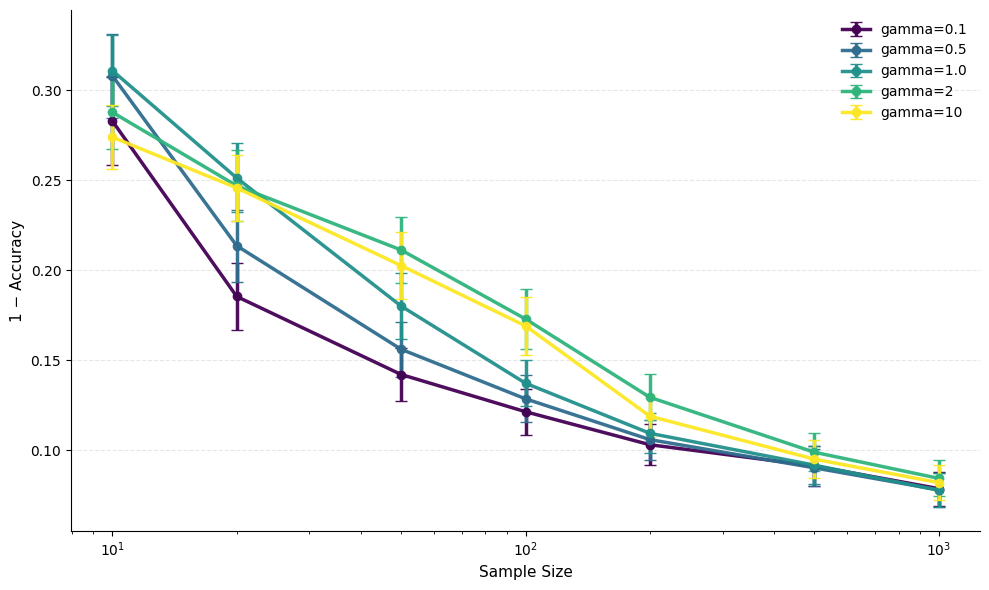

In [57]:
plot_merged_run_and_csv(
    run_data=run_data,
    #csv_path="/nfs/nhome/live/cdomine/nested_feature/experiments/cifar/data/cifar/resnet_acc_max.csv",
    metric_name="accs",
    type_val="valid",
    alphas = [0.1,0.5,1.0,2,10],
    seeds=list(range(30)),
    samples=[10, 20, 50, 100, 200, 500, 1000],
    error_type="se")

In [65]:
import torch
import numpy as np
import pandas as pd
from pathlib import Path

# --- Configuration ---
seeds = list(range(20))
n_samples= [10, 50, 100, 200, 500, 1000]
alphas = [0.1,0.5,1.0,2,5,10]
base_path = Path("/nfs/nhome/live/cdomine/old_sam/multi-task/data/cifar/ensd_fc/")

# Nested dictionary for structured access
run_data = {
    "df": {a: {s: [] for s in n_samples} for a in alphas},
}
all_long = []  # Stores long-format rows for every run
all_wide = []  # Stores wide-format per run

# --- Data Loading Loop ---
for alpha in alphas:
    for seed in seeds:
        for n_sample in n_samples:
            # Construct folder name based on experimental parameters
            folder_name = (
                f"random_seed={seed}--n_samples={n_sample}--finetune_scaling_last={alpha}"
            )
           
            dir_path = base_path / folder_name
            csv_path = dir_path / "df.csv"

            if not csv_path.exists():
                print(f'not downloaded {csv_path}')
                continue

            # --- Read CSV (long format: value, variable, layer) ---
            df = pd.read_csv(csv_path)

            # Cleanup: drop stray index column if present
            if "Unnamed: 0" in df.columns:
                df = df.drop(columns=["Unnamed: 0"])

            # Ensure expected columns exist
            expected = {"value", "variable", "layer"}
            missing = expected - set(df.columns)
            if missing:
                raise ValueError(f"{csv_path} is missing columns: {missing}")

            # Enforce data types
            df["value"] = df["value"].astype(float)
            df["layer"] = df["layer"].astype(int)

            # Add metadata for filtering/grouping
            df["alpha"] = float(alpha)
            df["seed"] = int(seed)
            df["n_samples"] = int(n_sample)

            # Save in nested structure and global list
            run_data["df"][alpha][n_sample].append(df)
            all_long.append(df)
            # --- Optional: build wide-format for this run ---
            # Transforms: Layer | Variable_A_Value | Variable_B_Value
            df_wide = (
                df.pivot(index="layer", columns="variable", values="value")
                  .reset_index()
            )
            df_wide["alpha"] = float(alpha)
            df_wide["seed"] = int(seed)
            df_wide["n_samples"] = int(n_sample)
            all_wide.append(df_wide)

# --- Final Aggregation ---
if all_long:
    df_all_long = pd.concat(all_long, ignore_index=True)
else:
    df_all_long = pd.DataFrame()

if all_wide:
    df_all_wide = pd.concat(all_wide, ignore_index=True)
else:
    df_all_wide = pd.DataFrame()
print("All long-format rows:", df_all_long.shape)
print("All wide-format rows:", df_all_wide.shape)

All long-format rows: (20160, 6)
All wide-format rows: (5040, 8)


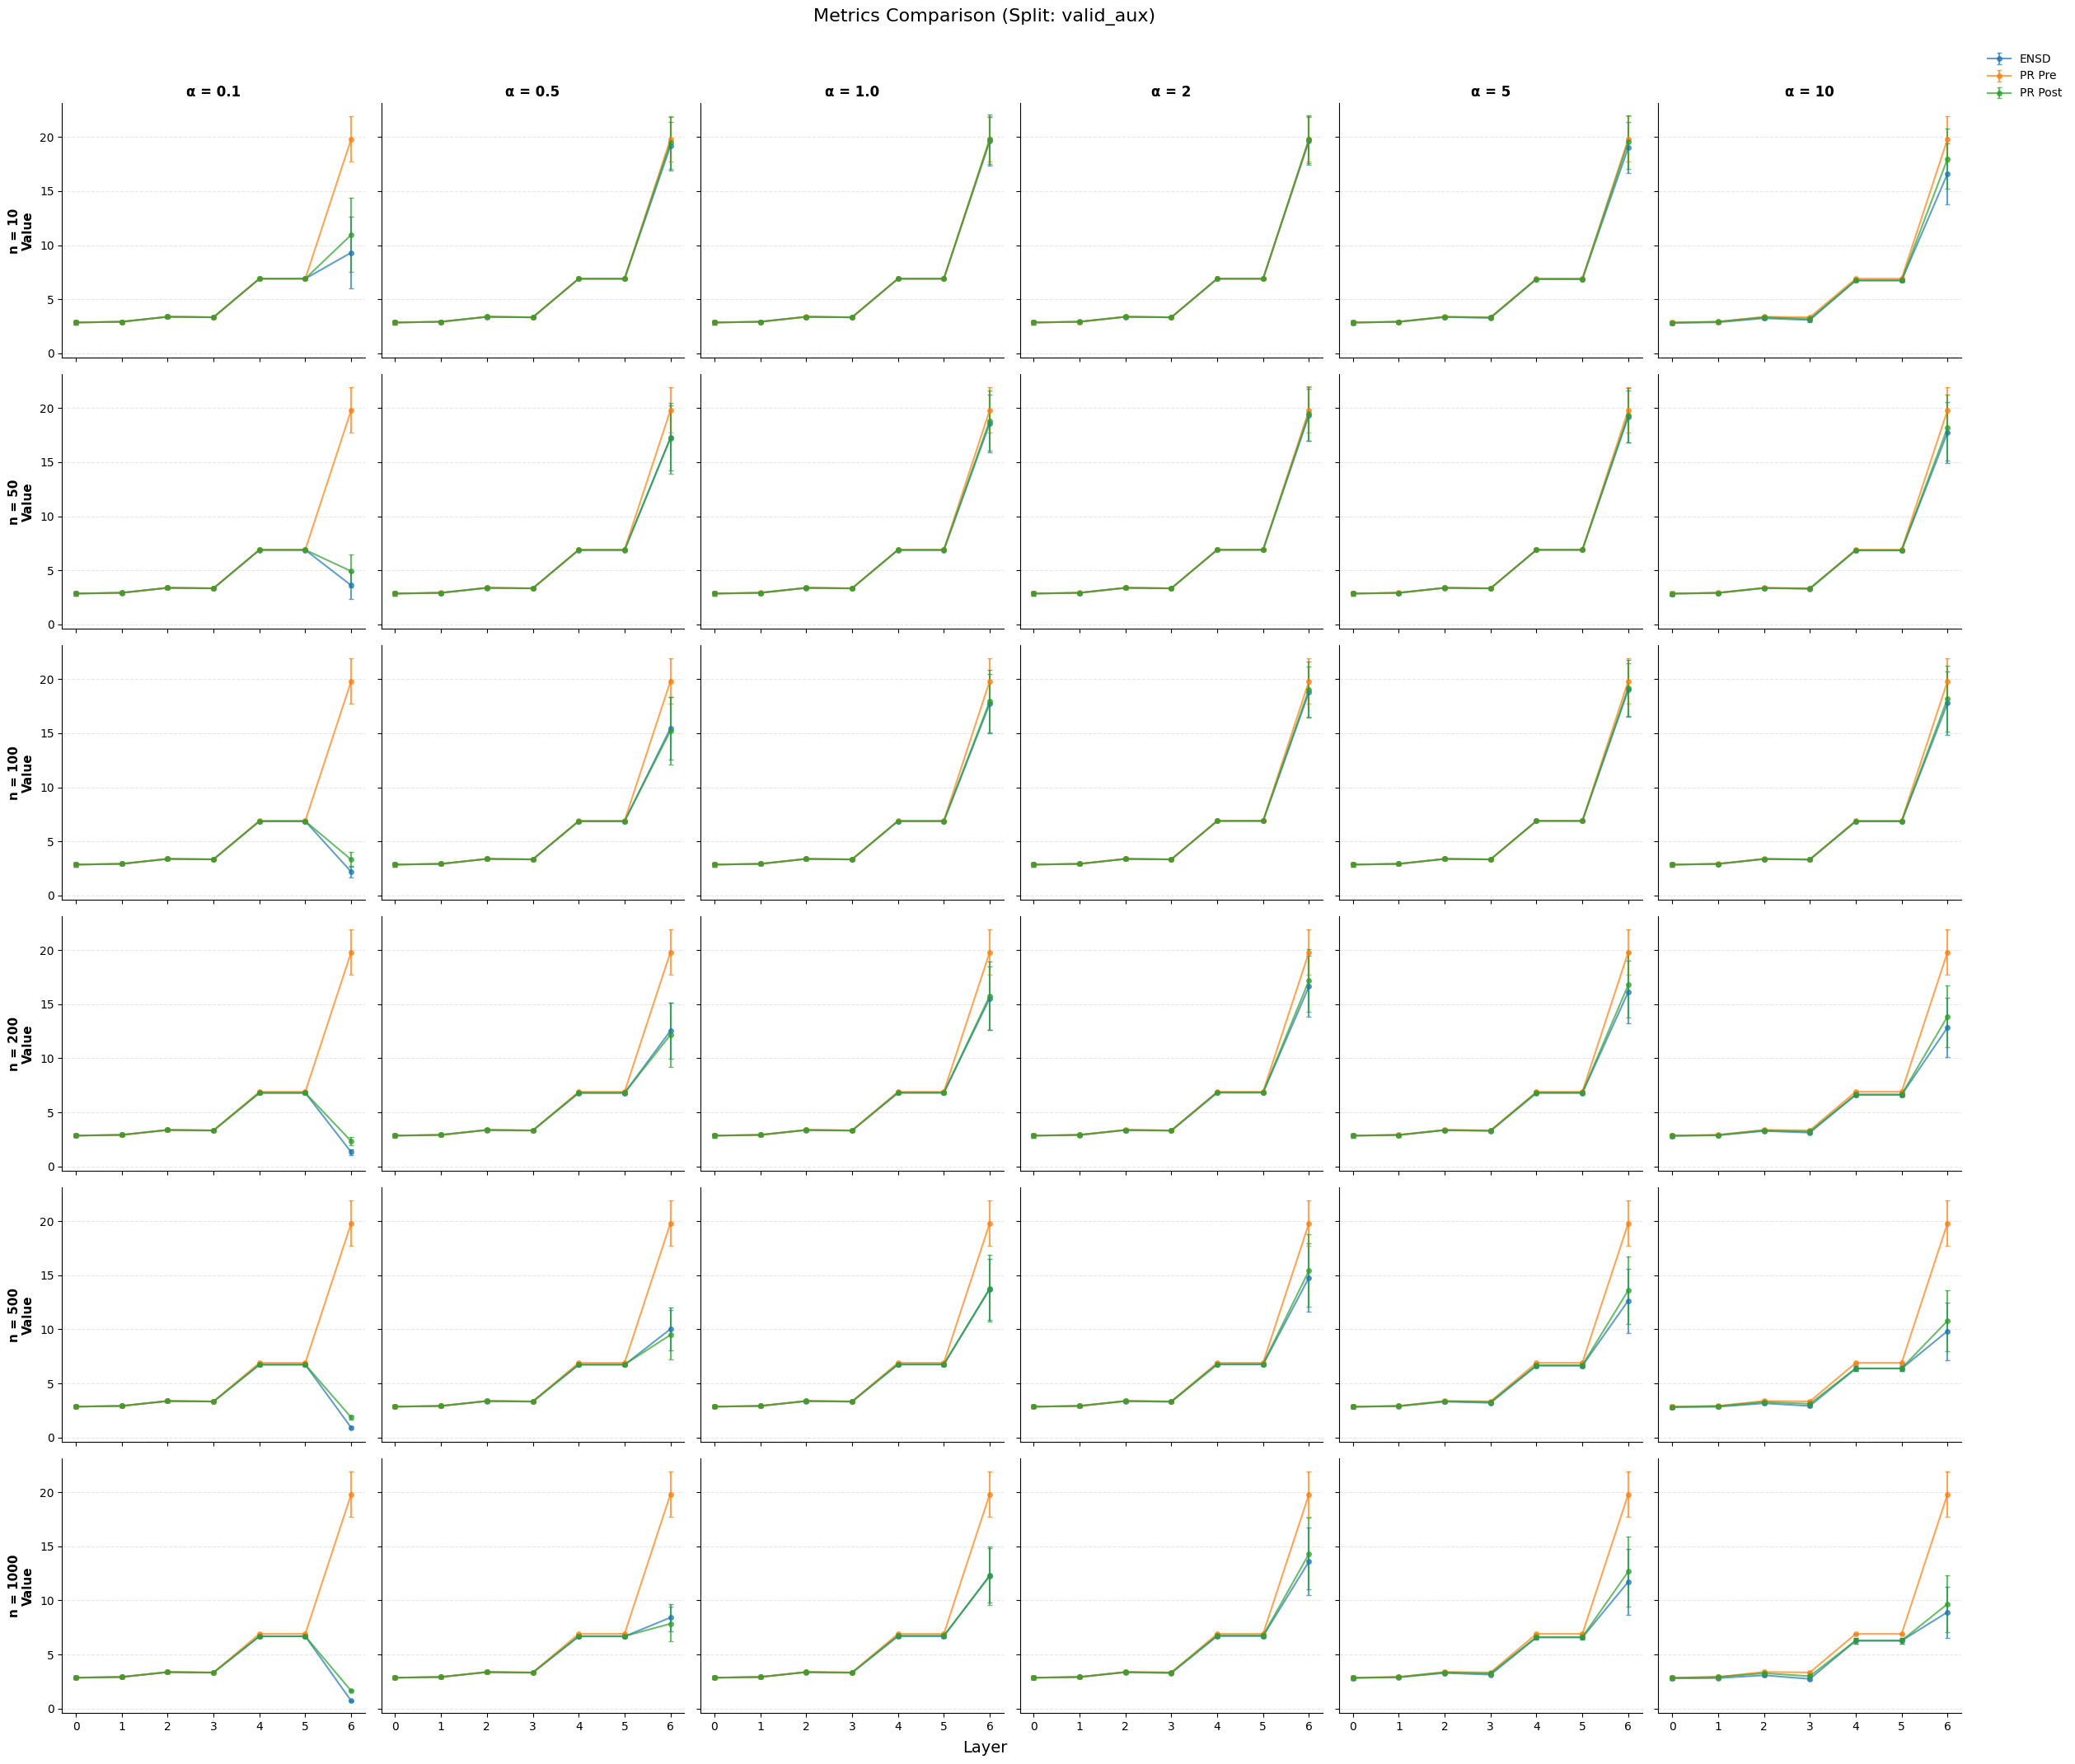

In [67]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_values_by_alpha_grid(
    run_data,
    split_name=None,
    *,
    n_samples=[100],
    alphas=(0.1, 0.5, 1.0),
    seeds=None,
    variables=("ENSD", "PR Pre", "PR Post"),
    split_col=("split", "dataset", "name"),
):
    """
    Creates a single large figure grid.
    Rows = n_samples
    Cols = alphas
    """
    num_samples = len(n_samples)
    num_alphas = len(alphas)

    # Create the grid
    fig, axes = plt.subplots(
        num_samples, num_alphas, 
        figsize=(4 * num_alphas, 3.5 * num_samples),
        sharex=True, 
        sharey=True,
        squeeze=False # Ensures axes is always a 2D array [row, col]
    )

    for row_idx, n_sample in enumerate(n_samples):
        for col_idx, alpha in enumerate(alphas):
            ax = axes[row_idx, col_idx]
            
            # Data retrieval
            df_list = run_data["df"].get(alpha, {}).get(n_sample, [])
            
            if not df_list:
                ax.set_title(f"n={n_sample}, α={alpha} (No Data)", fontsize=10)
                continue

            rows = []
            for df in df_list:
                d = df.copy()
                if seeds is not None and "seed" in d.columns:
                    d = d[d["seed"].isin(seeds)]
                if split_name is not None:
                    found_col = next((c for c in split_col if c in d.columns), None)
                    if found_col is not None:
                        d = d[d[found_col] == split_name]
                
                # Filter specifically for your 3 variables
                d = d[d["variable"].isin(variables)]
                if not d.empty:
                    rows.append(d)

            if not rows:
                continue

            df_all = pd.concat(rows, ignore_index=True)
            stats = (
                df_all.groupby(["variable", "layer"])["value"]
                .agg(mean="mean", std="std")
                .reset_index()
            )

            # Plotting
            for var in variables:
                sub = stats[stats["variable"] == var]
                ax.errorbar(
                    sub["layer"], sub["mean"], yerr=sub["std"].fillna(0),
                    marker="o", markersize=4, label=var, linewidth=1.5, capsize=2, alpha=0.7
                )

            # Labels and Styling
            if row_idx == 0:
                ax.set_title(f"α = {alpha}", fontsize=12, fontweight='bold')
            if col_idx == 0:
                ax.set_ylabel(f"n = {n_sample}\nValue", fontsize=11, fontweight='bold')
            
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.grid(True, axis='y', linestyle='--', alpha=0.3)

    # Global labels
    fig.supxlabel("Layer", fontsize=14)
    fig.suptitle(f"Metrics Comparison (Split: {split_name})", fontsize=16, y=1.02)
    
    # Single legend for the whole figure
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(1.05, 1), frameon=False)

    plt.tight_layout()
    plt.show()

# Execution
plot_values_by_alpha_grid(
    run_data,
    split_name="valid_aux",
    n_samples=[10, 50, 100, 200, 500, 1000],
    alphas=[ .1, 0.5, 1.0, 2, 5, 10],
    seeds=seeds,
    variables=["ENSD", "PR Pre", "PR Post"]
)

In [138]:
NEW GAMMA

SyntaxError: invalid syntax (3598365641.py, line 1)

In [ ]:
import os
import pandas as pd
import numpy as np
import plotnine as gg
from pathlib import Path

# Updated paths
base_path = Path("/nfs/scistore19/locatgrp/cdomine/multi-task/data/cifar/finetune_fc/")
output_path = '/nfs/scistore19/locatgrp/cdomine/multi-task/data/cifar/finetune_fc_max.csv'

data_list = []

for folder in os.listdir(base_path):
    folder_path = base_path / folder
    acc_file = folder_path / 'accs.npy'
    
    if not acc_file.exists():
        continue

    try:
        # Load accuracy dict
        acc_data = np.load(acc_file, allow_pickle=True).item()

        # Max value per metric
        new_df = pd.DataFrame({
            k: [v.max()] for k, v in acc_data.items() if len(v) > 0
        })

        # Parse new folder naming convention
        parts = folder.split('--')
        params = {p.split('=')[0]: p.split('=')[1] for p in parts}

        new_df['rs'] = int(params.get('random_seed', -1))
        new_df['n_samples'] = int(params.get('n_samples', 0))
        # <-- updated scaling key
        new_df['scaling'] = float(params.get('finetune_scaling_last', 1.0))
        new_df['model'] = params.get('model', 'unknown')

        # consistent with plotting code
        new_df['mode'] = 'finetuning'

        data_list.append(new_df)

    except Exception as e:
        print(f"Skipping {folder} due to error: {e}")

# Combine & save
df = pd.concat(data_list, ignore_index=True)
df.to_csv(output_path, index=False)



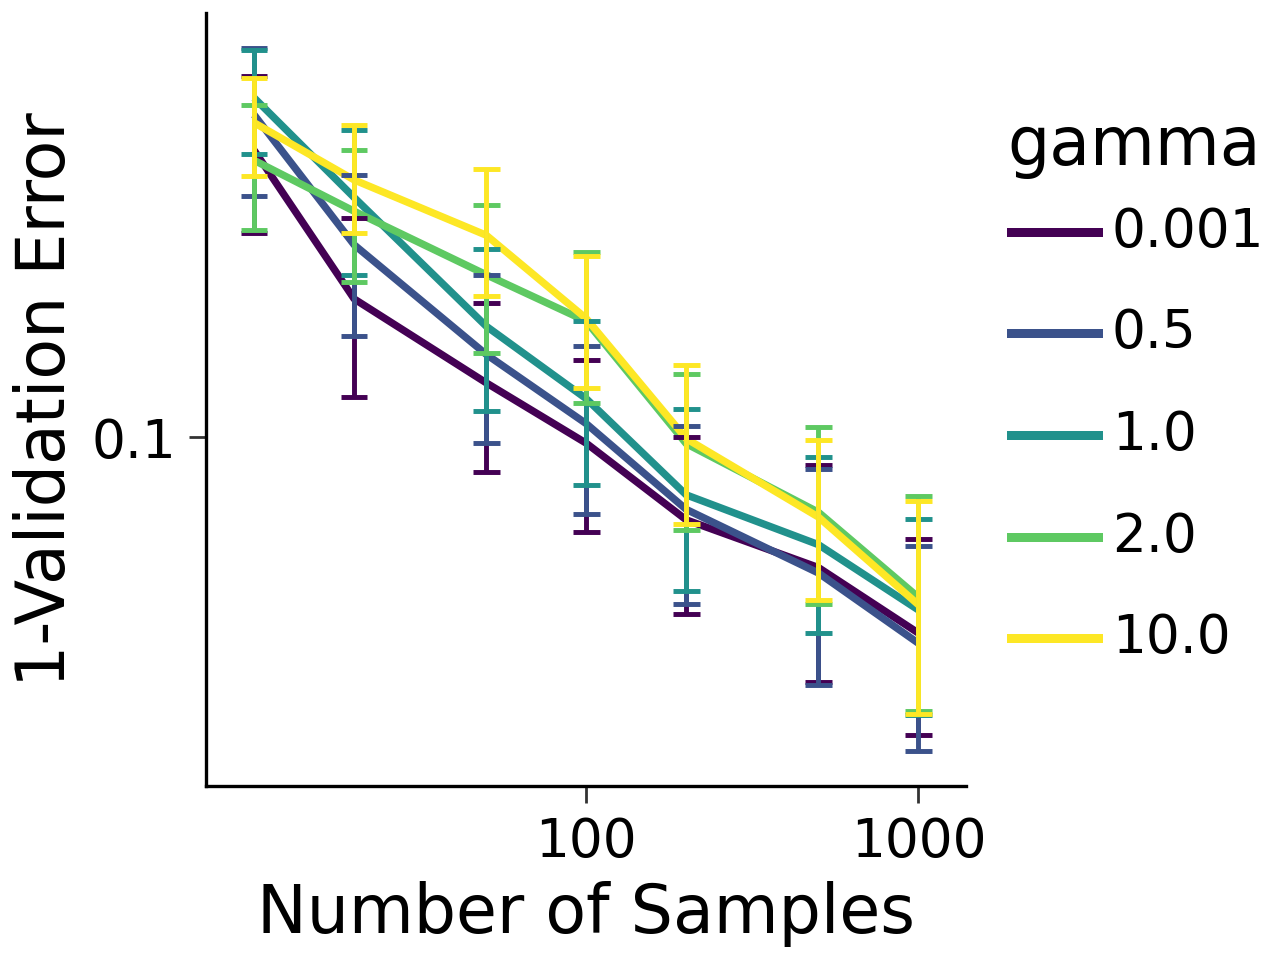

In [145]:
x_breaks = [100, 1000, 10000] 
y_breaks = [0.1, 0.4]    

# Filter out multiple unwanted scaling values
df_plot = df[~df['scaling'].isin([5.0, 20.0,0.1 ,0.01])].copy()

(
    gg.ggplot(
        df_plot,
        gg.aes(
            x='n_samples',
            y='1-valid',
            color='factor(scaling)',
            group='scaling'
        )
    ) +
    gg.stat_summary(geom='line', size=1.5) +
    gg.stat_summary(
        geom='errorbar',
        size=1.0,
        width=0.08
    ) +
    gg.scale_x_log10(breaks=x_breaks) +
    gg.scale_y_log10(breaks=y_breaks) +
    gg.scale_color_cmap_d(name='gamma') +
    gg.theme_classic(base_size=24) +
    gg.labs(
        x="Number of Samples",
        y="1-Validation Error",
        color="Alpha Load"
    ) +
    gg.theme(
        panel_grid_major=gg.element_blank(),
        panel_grid_minor=gg.element_blank(),
        axis_text=gg.element_text(color="black"),
        axis_line=gg.element_line(size=1.2)
    )
)


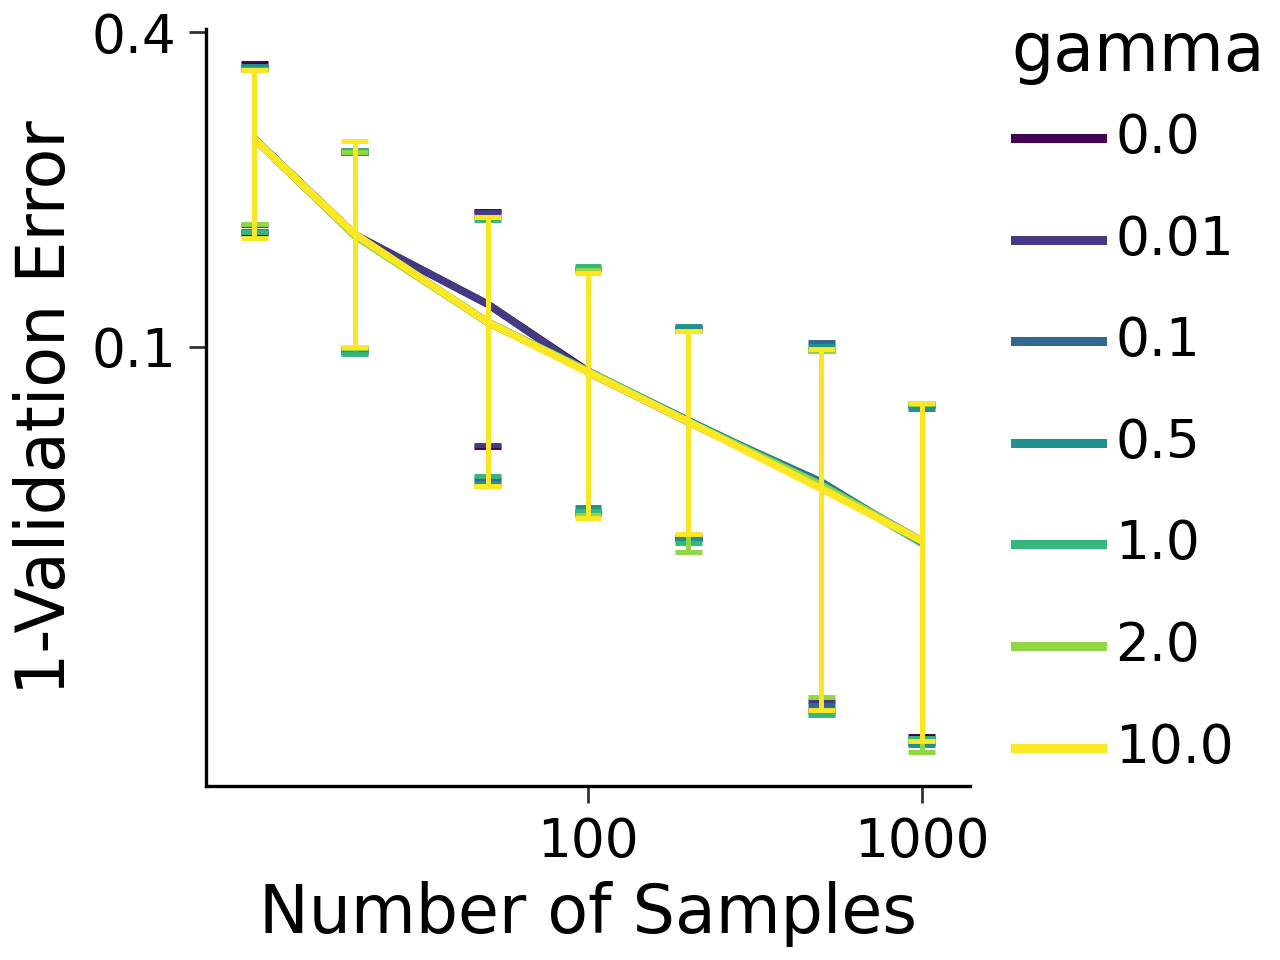

In [160]:
import os
import pandas as pd
import numpy as np
import plotnine as gg
from pathlib import Path

# Updated paths
base_path = Path("/nfs/scistore19/locatgrp/cdomine/multi-task/data/cifar/finetune_fc_new/")
output_path = '/nfs/scistore19/locatgrp/cdomine/multi-task/data/cifar/finetune_fc_max.csv'

data_list = []

for folder in os.listdir(base_path):
    folder_path = base_path / folder
    acc_file = folder_path / 'accs.npy'
    
    if not acc_file.exists():
        continue

    try:
        # Load accuracy dict
        acc_data = np.load(acc_file, allow_pickle=True).item()

        # Max value per metric
        new_df = pd.DataFrame({
            k: [v.max()] for k, v in acc_data.items() if len(v) > 0
        })

        # Parse new folder naming convention
        parts = folder.split('--')
        params = {p.split('=')[0]: p.split('=')[1] for p in parts}

        new_df['rs'] = int(params.get('random_seed', -1))
        new_df['n_samples'] = int(params.get('n_samples', 0))
        # <-- updated scaling key
        new_df['scaling'] = float(params.get('finetune_scaling_last', 1.0))
        new_df['model'] = params.get('model', 'unknown')

        # consistent with plotting code
        new_df['mode'] = 'finetuning'

        data_list.append(new_df)

    except Exception as e:
        print(f"Skipping {folder} due to error: {e}")

# Combine & save
df = pd.concat(data_list, ignore_index=True)
df.to_csv(output_path, index=False)

x_breaks = [100, 1000, 10000] 
y_breaks = [0.1, 0.4]    

# Filter out multiple unwanted scaling values
df_plot = df[~df['scaling'].isin([5.0, 20])].copy()

(
    gg.ggplot(
        df_plot,
        gg.aes(
            x='n_samples',
            y='1-valid',
            color='factor(scaling)',
            group='scaling'
        )
    ) +
    gg.stat_summary(geom='line', size=1.5) +
    gg.stat_summary(
        geom='errorbar',
        size=1.0,
        width=0.08
    ) +
    gg.scale_x_log10(breaks=x_breaks) +
    gg.scale_y_log10(breaks=y_breaks) +
    gg.scale_color_cmap_d(name='gamma') +
    gg.theme_classic(base_size=24) +
    gg.labs(
        x="Number of Samples",
        y="1-Validation Error",
        color="Alpha Load"
    ) +
    gg.theme(
        panel_grid_major=gg.element_blank(),
        panel_grid_minor=gg.element_blank(),
        axis_text=gg.element_text(color="black"),
        axis_line=gg.element_line(size=1.2)
    )
)


In [108]:


import torch
import numpy as np
from pathlib import Path
seeds = list(range(30))
alphas = [0.1,0.5,1.0,2,5,10]
 #/nfs/gatsbystor/cdomine/cifar_testing/cifar/main_3/
n_samples=[10, 20, 50, 100, 200, 500, 1000]
#random_seed=0--mode=finetuning--n_samples=10--alpha=1.0--alpha_policy=first_vs_rest--model=resnet
base_path = Path("/nfs/scistore19/locatgrp/cdomine/multi-task/data/cifar/finetune_fc/")
 #base_path = Path("/nfs/nhome/live/cdomine/nested_feature/experiments/cifar/data/cifar/main_3/")

 
run_data = {
    'losses': {a:{s: [] for s in n_samples} for a in alphas},
    'accs': {a: {s: [] for s in n_samples} for a in alphas},
    'models': {a: {s: [] for s in n_samples} for a in alphas},
    'l2_regs': {a: {s: [] for s in n_samples} for a in alphas}
}
for alpha in alphas:
    for seed in seeds:
        for n_sample in n_samples :
            folder_name = (
                f"random_seed={seed}--n_samples={n_sample}--finetune_scaling_last={alpha}--model=resnet"
            )
           
            dir_path = base_path / folder_name
            if dir_path.exists():
              #    print(f" {seed}, Alpha {alpha}, Sample {n_sample}, Accs"),
                # Load and append data to the lists
                if (dir_path / "losses.npy").exists():
                    run_data['losses'][alpha][n_sample].append(np.load(dir_path / "losses.npy",allow_pickle=True))
                    print(f"✅ Loaded Seed {seed}, Alpha {alpha}, Sample {n_sample}, Losses")
                if (dir_path / "l2_regs.npy").exists():
                    run_data['l2_regs'][alpha][n_sample].append(np.load(dir_path / "l2_regs.npy",allow_pickle=True))
                    print(f"✅ Loaded Seed {seed}, Alpha {alpha}, Sample {n_sample}, l2_regs")
                if (dir_path / "accs.npy").exists():
                    run_data['accs'][alpha][n_sample].append(np.load(dir_path / "accs.npy",allow_pickle=True))
                   #   print(f"✅ Loaded Seed {seed}, Alpha {alpha}, Sample {n_sample}, Accs"),
            else:
                print(f"Missing directory: {folder_name}")

✅ Loaded Seed 0, Alpha 0.1, Sample 10, Losses
✅ Loaded Seed 0, Alpha 0.1, Sample 20, Losses
✅ Loaded Seed 0, Alpha 0.1, Sample 50, Losses
✅ Loaded Seed 0, Alpha 0.1, Sample 100, Losses
✅ Loaded Seed 0, Alpha 0.1, Sample 200, Losses
✅ Loaded Seed 0, Alpha 0.1, Sample 500, Losses
✅ Loaded Seed 0, Alpha 0.1, Sample 1000, Losses
✅ Loaded Seed 1, Alpha 0.1, Sample 10, Losses
✅ Loaded Seed 1, Alpha 0.1, Sample 20, Losses
✅ Loaded Seed 1, Alpha 0.1, Sample 50, Losses
✅ Loaded Seed 1, Alpha 0.1, Sample 100, Losses
✅ Loaded Seed 1, Alpha 0.1, Sample 200, Losses
✅ Loaded Seed 1, Alpha 0.1, Sample 500, Losses
✅ Loaded Seed 1, Alpha 0.1, Sample 1000, Losses
✅ Loaded Seed 2, Alpha 0.1, Sample 10, Losses
✅ Loaded Seed 2, Alpha 0.1, Sample 20, Losses
✅ Loaded Seed 2, Alpha 0.1, Sample 50, Losses
✅ Loaded Seed 2, Alpha 0.1, Sample 100, Losses
✅ Loaded Seed 2, Alpha 0.1, Sample 200, Losses
✅ Loaded Seed 2, Alpha 0.1, Sample 500, Losses
✅ Loaded Seed 2, Alpha 0.1, Sample 1000, Losses
✅ Loaded Seed 3, Al

In [ ]:
import torch
import numpy as np
import pandas as pd
from pathlib import Path

# --- Configuration ---
seeds = list(range(20))
n_samples= [10, 50, 100, 200, 500, 1000]
alphas = [0.1,0.5,1.0,2,5,10]
base_path = Path("/nfs/scistore19/locatgrp/cdomine/multi-task/data/cifar/ensd_sam_scalled_2/")


# Nested dictionary for structured access
run_data = {
    "df": {a: {s: [] for s in n_samples} for a in alphas},
}
all_long = []  # Stores long-format rows for every run
all_wide = []  # Stores wide-format per run

# --- Data Loading Loop ---
for alpha in alphas:
    for seed in seeds:
        for n_sample in n_samples:
            # Construct folder name based on experimental parameters
            folder_name = (
                f"random_seed={seed}--n_samples={n_sample}--alpha_load={alpha}"
            ) 
           
            dir_path = base_path / folder_name
            csv_path = dir_path / "df.csv"

            if not csv_path.exists():
                print(f'not downloaded {csv_path}')
                continue

            # --- Read CSV (long format: value, variable, layer) ---
            df = pd.read_csv(csv_path)

            # Cleanup: drop stray index column if present
            if "Unnamed: 0" in df.columns:
                df = df.drop(columns=["Unnamed: 0"])

            # Ensure expected columns exist
            expected = {"value", "variable", "layer"}
            missing = expected - set(df.columns)
            if missing:
                raise ValueError(f"{csv_path} is missing columns: {missing}")

            # Enforce data types
            df["value"] = df["value"].astype(float)
            df["layer"] = df["layer"].astype(int)

            # Add metadata for filtering/grouping
            df["alpha"] = float(alpha)
            df["seed"] = int(seed)
            df["n_samples"] = int(n_sample)

            # Save in nested structure and global list
            run_data["df"][alpha][n_sample].append(df)
            all_long.append(df)
            # --- Optional: build wide-format for this run ---
            # Transforms: Layer | Variable_A_Value | Variable_B_Value
            df_wide = (
                df.pivot(index="layer", columns="variable", values="value")
                  .reset_index()
            )
            df_wide["alpha"] = float(alpha)
            df_wide["seed"] = int(seed)
            df_wide["n_samples"] = int(n_sample)
            all_wide.append(df_wide)

# --- Final Aggregation ---
if all_long:
    df_all_long = pd.concat(all_long, ignore_index=True)
else:
    df_all_long = pd.DataFrame()

if all_wide:
    df_all_wide = pd.concat(all_wide, ignore_index=True)
else:
    df_all_wide = pd.DataFrame()
print("All long-format rows:", df_all_long.shape)
print("All wide-format rows:", df_all_wide.shape)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

def plot_values_by_alpha_grid(
    run_data,
    split_name=None,
    *,
    n_samples=(100,),
    alphas=(0.1, 0.5, 1.0),
    seeds=None,
    variables=("ENSD", "PR Pre", "PR Post"),
    split_col=("split", "dataset", "name"),
):
    # -----------------------------
    # Global styling (ggplot-like)
    # -----------------------------
    mpl.rcParams.update({
       "font.size": 30,
        "axes.titlesize": 28,
        "axes.labelsize": 24,
        "xtick.labelsize": 28,
        "ytick.labelsize": 28,
        "legend.fontsize": 28,
        "figure.titlesize": 28,
        "axes.linewidth": 2,
    })

    num_rows = len(n_samples)
    num_cols = len(alphas)

    fig, axes = plt.subplots(
        num_rows,
        num_cols,
        figsize=(6 * num_cols, 8 * num_rows),
        sharex=True,
        sharey=True,
        squeeze=False,
    )

    for row_idx, n_sample in enumerate(n_samples):
        for col_idx, alpha in enumerate(alphas):
            ax = axes[row_idx, col_idx]

            df_list = run_data["df"].get(alpha, {}).get(n_sample, [])
            if not df_list:
                ax.set_title(f"n={n_sample}, α={alpha} (No data)")
                continue

            rows = []
            for df in df_list:
                d = df.copy()

                if seeds is not None and "seed" in d.columns:
                    d = d[d["seed"].isin(seeds)]

                if split_name is not None:
                    col = next((c for c in split_col if c in d.columns), None)
                    if col is not None:
                        d = d[d[col] == split_name]

                d = d[d["variable"].isin(variables)]
                if not d.empty:
                    rows.append(d)

            if not rows:
                continue

            df_all = pd.concat(rows, ignore_index=True)

            stats = (
                df_all.groupby(["variable", "layer"])["value"]
                .agg(mean="mean", std="std")
                .reset_index()
            )

            # -----------------------------
            # Plot with caps
            # -----------------------------
            for var in variables:
                sub = stats[stats["variable"] == var]
                ax.errorbar(
                    sub["layer"],
                    sub["mean"],
                    yerr=sub["std"].fillna(0),
                    marker="o",
                    markersize=6,
                    linewidth=2.0,
                    capsize=6,
                    capthick=1.4,
                    label=var,
                )

            # -----------------------------
            # Titles & labels
            # -----------------------------
            if row_idx == 0:
                ax.set_title(f"gamma = {alpha}", fontweight="bold")

            if col_idx == 0:
                ax.set_ylabel(f"n = {n_sample}\nValue", fontweight="bold")

            # -----------------------------
            # Classic theme styling
            # -----------------------------
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            ax.tick_params(axis="both", width=1.4, length=6)
            ax.grid(False)

    # -----------------------------
    # Global labels
    # -----------------------------
    fig.supxlabel("Layer", fontweight="bold")
    #fig.suptitle(
      #  f"Metrics Comparison (Split: {split_name})",
      ##  y=1.02,
       # fontweight="bold",
   # )

    # -----------------------------
    # One legend for all subplots
    # -----------------------------
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="upper right",
        bbox_to_anchor=(1.08, 1.0),
        frameon=False,
    )

    plt.tight_layout()
    plt.show()
plot_values_by_alpha_grid(
    run_data,
    split_name="valid_aux",
    n_samples=[500],
    alphas =[0.1,0.5,1.0,2,10],
    seeds=seeds,
    variables=["ENSD", "PR Pre", "PR Post"])

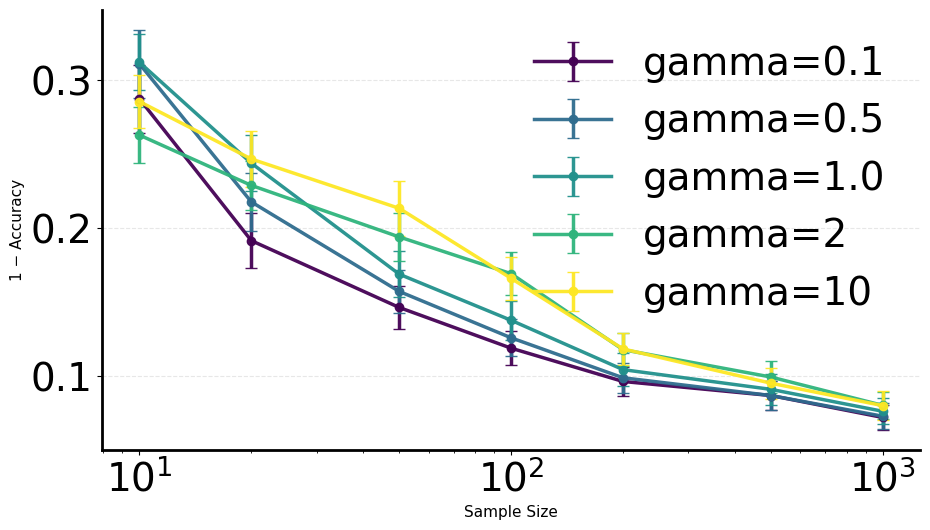

In [109]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm


def _err_from_vals(vals, error_type="se"):
    vals = np.asarray(vals, dtype=float)
    mean = float(np.mean(vals))
    std = float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0
    err = std if error_type == "std" else std / np.sqrt(len(vals))
    return mean, err


def plot_merged_run_and_csv(
    run_data,
    metric_name,
    type_val,
    alphas,
    seeds,
    samples,
    log_x=True,
    use_one_minus_acc=True,
    error_type="se",
):
    assert error_type in {"std", "se"}

    fig, ax = plt.subplots(figsize=(10, 6))

    # ---- colormap with LOG-scaled alpha ----
    cmap = plt.colormaps["viridis"] if hasattr(plt, "colormaps") else plt.cm.get_cmap("viridis")
    norm = LogNorm(vmin=min(alphas), vmax=max(alphas))

    metric_lower = str(metric_name).lower()
    do_one_minus_run = use_one_minus_acc and ("acc" in metric_lower or "accuracy" in metric_lower)

    # --------- RUN_DATA PLOT ----------
    for alpha in alphas:
        means, errs = [], []

        for sample in samples:
            vals = []
            for seed in seeds:
                try:
                    data_matrix = run_data[metric_name][alpha][sample]
                    v = data_matrix[seed]
                    data_dict = v.item() if hasattr(v, "item") else v

                    y = np.max(data_dict[type_val])
                    if do_one_minus_run:
                        y = 1.0 - y

                    # protect log plots
                    if y <= 0:
                        continue

                    vals.append(y)

                except (KeyError, IndexError, TypeError, ValueError):
                    continue

            if len(vals) == 0:
                means.append(np.nan)
                errs.append(np.nan)
            else:
                m, e = _err_from_vals(vals, error_type)
                means.append(m)
                errs.append(e)

        if np.all(np.isnan(means)):
            print(f"[WARN] α={alpha} produced all-NaN. Skipping.")
            continue

        ax.errorbar(
            samples,
            means,
            yerr=errs,
            label=f"gamma={alpha}",
            color=cmap(norm(alpha)),
            marker="o",
            linestyle="-",
            linewidth=2.5,
            capsize=4,
            alpha=0.95,
            zorder=3,
        )

    # --------- Styling ----------
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if log_x:
        ax.set_xscale("log")

    ax.set_xlabel("Sample Size", fontsize=11)
    ax.set_ylabel("1 − Accuracy", fontsize=11)

    ax.legend(frameon=False)
    ax.yaxis.grid(True, linestyle="--", alpha=0.3)

    # --------- Log-scaled colorbar ----------
    # sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    # sm.set_array([])
    # cbar = plt.colorbar(sm, ax=ax, pad=0.02)
    # cbar.set_label("c_pt (alpha)", rotation=270, labelpad=15)

    plt.tight_layout()
    plt.show()
plot_merged_run_and_csv(
    run_data=run_data,
    #csv_path="/nfs/nhome/live/cdomine/nested_feature/experiments/cifar/data/cifar/resnet_acc_max.csv",
    metric_name="accs",
    type_val="valid",
    alphas = [0.1,0.5,1.0,2,10],
    seeds=list(range(30)),
    samples=[10, 20, 50, 100, 200, 500, 1000],
    error_type="se")

cpt

In [130]:
import os
import pandas as pd
import numpy as np
import plotnine as gg
from pathlib import Path

# Updated path based on your snippet
base_path = Path("/nfs/scistore19/locatgrp/cdomine/multi-task/data/cifar/finetune_scaled_2/")
output_path = '/nfs/scistore19/locatgrp/cdomine/multi-task/data/cifar/finetune_scaled_2_max.csv'

data_list = []

for folder in os.listdir(base_path):
    folder_path = base_path / folder
    acc_file = folder_path / 'accs.npy'
    
    if acc_file.exists():
        try:
            # Load the dictionary of accuracies
            acc_data = np.load(acc_file, allow_pickle=True)[()]
            
            # Create dataframe with max values for each metric
            new_df = pd.DataFrame({
                k: [v.max()] for k, v in acc_data.items() if len(v) != 0
            })
            
            # Parse the new folder naming convention: 
            # random_seed={seed}--alpha_load={alpha}--n_samples={n_sample}--model=resnet
            parts = folder.split('--')
            params = {p.split('=')[0]: p.split('=')[1] for p in parts}
            
            new_df['rs'] = params.get('random_seed')
            new_df['scaling'] = float(params.get('alpha_load', 1.0)) # alpha_load is scaling
            new_df['n_samples'] = int(params.get('n_samples', 0))
            new_df['model'] = params.get('model')
            
            # Setting 'mode' as 'finetuning' for consistency with your plotting code
            new_df['mode'] = 'finetuning' 
            
            data_list.append(new_df)
        except Exception as e:
            print(f"Skipping {folder} due to error: {e}")

# Combine and save
df = pd.concat(data_list, ignore_index=True)
df.to_csv(output_path, index=False)




/nfs/scistore19/locatgrp/cdomine/miniforge3/envs/NPG-env/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
/nfs/scistore19/locatgrp/cdomine/miniforge3/envs/NPG-env/lib/python3.12/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_summary : Removed 1 rows containing non-finite values.
/nfs/scistore19/locatgrp/cdomine/miniforge3/envs/NPG-env/lib/python3.12/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_summary : Removed 1 rows containing non-finite values.


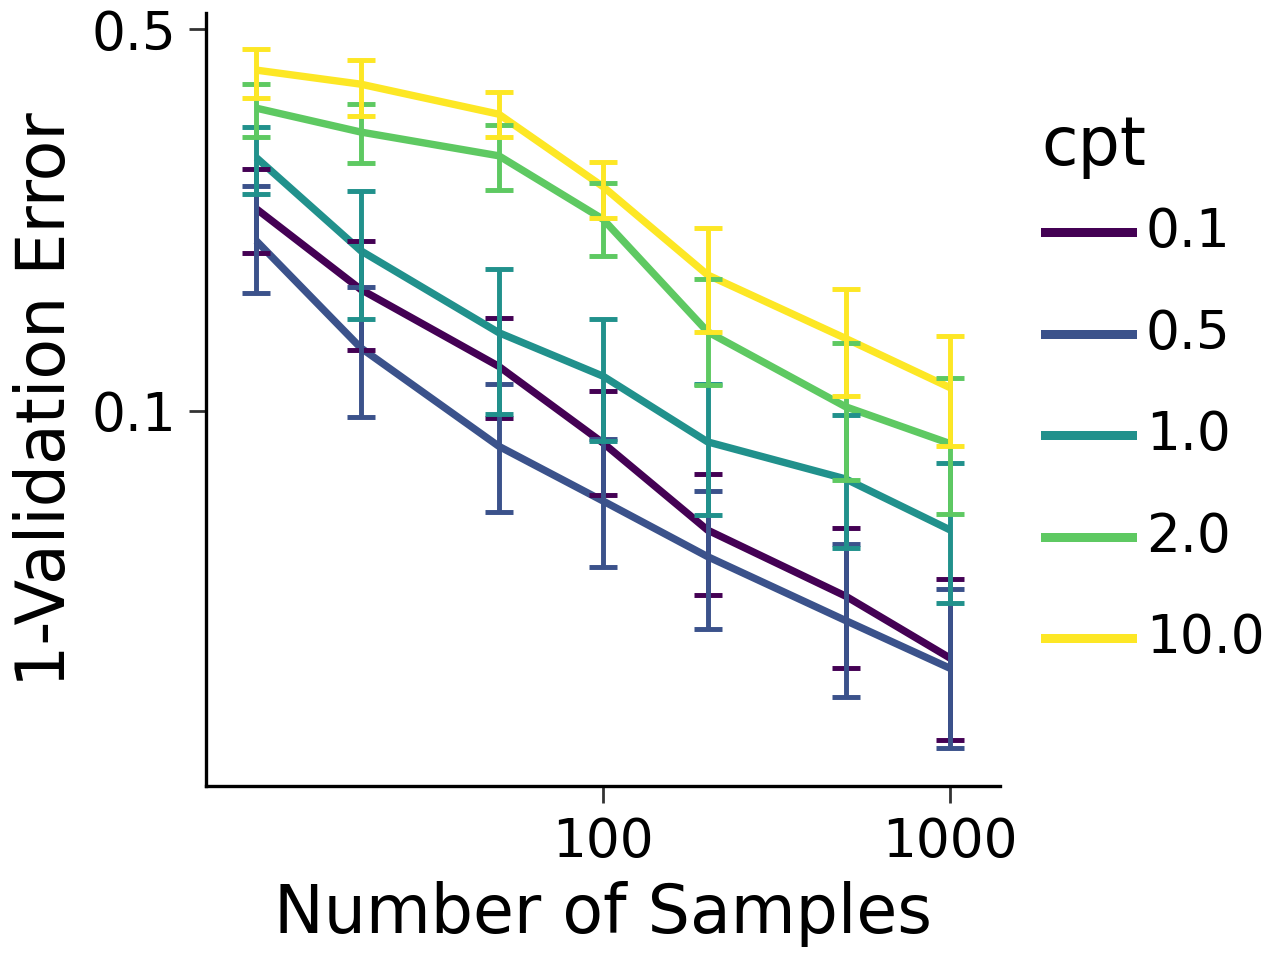

In [131]:
x_breaks = [100, 1000, 10000] 
y_breaks = [0.1, 0.5]    

df_plot = df[df['scaling'] != 5]

(
    gg.ggplot(
        df_plot,
        gg.aes(
            x='n_samples',
            y='1-valid',
            color='factor(scaling)',
            group='scaling'
        )
    ) +
    gg.stat_summary(geom='line', size=1.5) +
    gg.stat_summary(
        geom='errorbar',
        size=1.0,
        width=0.08
    ) +
    gg.scale_x_log10(breaks=x_breaks) +
    gg.scale_y_log10(breaks=y_breaks) +
    gg.scale_color_cmap_d(name='cpt') +
    gg.theme_classic(base_size=24) +
    gg.labs(
        x="Number of Samples",
        y="1-Validation Error",
        color="Alpha Load"
    ) +
    gg.theme(
        panel_grid_major=gg.element_blank(),
        panel_grid_minor=gg.element_blank(),
        axis_text=gg.element_text(color="black"),
        axis_line=gg.element_line(size=1.2)
    )
)




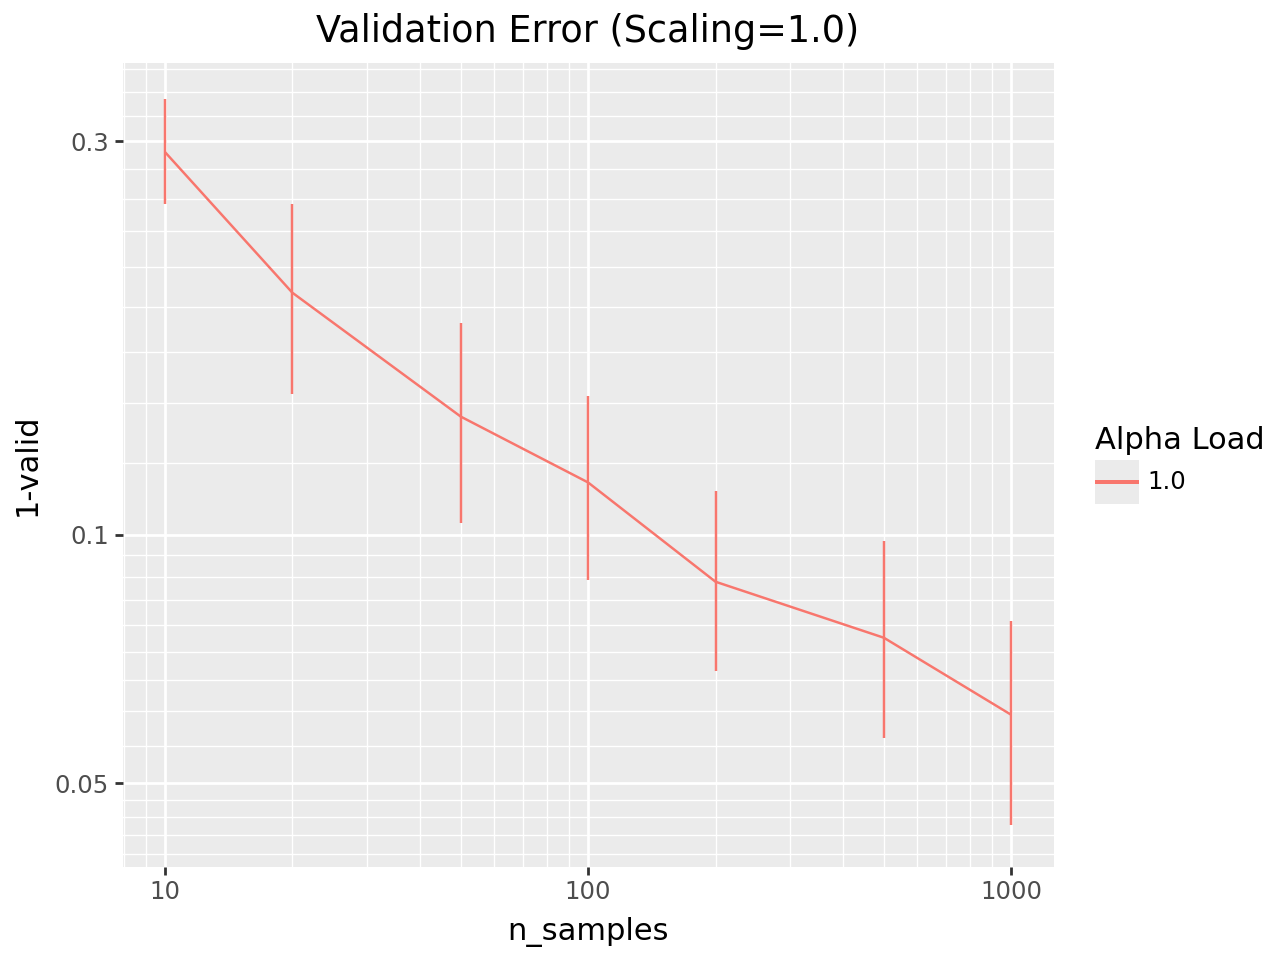

In [1]:
import torch
import numpy as np
from pathlib import Path
seeds = list(range(30))
alphas = [0.1,0.5,1.0,2,5,10]
 #/nfs/gatsbystor/cdomine/cifar_testing/cifar/main_3/
n_samples=[10, 20, 50, 100, 200, 500, 1000]
#random_seed=0--mode=finetuning--n_samples=10--alpha=1.0--alpha_policy=first_vs_rest--model=resnet
base_path = Path("/nfs/scistore19/locatgrp/cdomine/multi-task/data/cifar/finetune_scaled_2/")
 #base_path = Path("/nfs/nhome/live/cdomine/nested_feature/experiments/cifar/data/cifar/main_3/")
run_data = {
    'losses': {a:{s: [] for s in n_samples} for a in alphas},
    'accs': {a: {s: [] for s in n_samples} for a in alphas},
    'models': {a: {s: [] for s in n_samples} for a in alphas},
    'l2_regs': {a: {s: [] for s in n_samples} for a in alphas}
}
for alpha in alphas:
    for seed in seeds:
        for n_sample in n_samples :
            folder_name = (
                f"random_seed={seed}--alpha_load={alpha}--n_samples={n_sample}--model=resnet"
            )
            dir_path = base_path / folder_name
            if dir_path.exists():
              #    print(f" {seed}, Alpha {alpha}, Sample {n_sample}, Accs"),
                # Load and append data to the lists
                if (dir_path / "losses.npy").exists():
                    run_data['losses'][alpha][n_sample].append(np.load(dir_path / "losses.npy",allow_pickle=True))
                    print(f"✅ Loaded Seed {seed}, Alpha {alpha}, Sample {n_sample}, Losses")
                if (dir_path / "l2_regs.npy").exists():
                    run_data['l2_regs'][alpha][n_sample].append(np.load(dir_path / "l2_regs.npy",allow_pickle=True))
                    print(f"✅ Loaded Seed {seed}, Alpha {alpha}, Sample {n_sample}, l2_regs")
                if (dir_path / "accs.npy").exists():
                    run_data['accs'][alpha][n_sample].append(np.load(dir_path / "accs.npy",allow_pickle=True))
                   #   print(f"✅ Loaded Seed {seed}, Alpha {alpha}, Sample {n_sample}, Accs"),
            else:
                print(f"Missing directory: {folder_name}")

✅ Loaded Seed 0, Alpha 0.1, Sample 10, Losses
✅ Loaded Seed 0, Alpha 0.1, Sample 20, Losses
✅ Loaded Seed 0, Alpha 0.1, Sample 50, Losses
✅ Loaded Seed 0, Alpha 0.1, Sample 100, Losses
✅ Loaded Seed 0, Alpha 0.1, Sample 200, Losses
✅ Loaded Seed 0, Alpha 0.1, Sample 500, Losses
✅ Loaded Seed 0, Alpha 0.1, Sample 1000, Losses
✅ Loaded Seed 1, Alpha 0.1, Sample 10, Losses
✅ Loaded Seed 1, Alpha 0.1, Sample 20, Losses
✅ Loaded Seed 1, Alpha 0.1, Sample 50, Losses
✅ Loaded Seed 1, Alpha 0.1, Sample 100, Losses
✅ Loaded Seed 1, Alpha 0.1, Sample 200, Losses
✅ Loaded Seed 1, Alpha 0.1, Sample 500, Losses
✅ Loaded Seed 1, Alpha 0.1, Sample 1000, Losses
✅ Loaded Seed 2, Alpha 0.1, Sample 10, Losses
✅ Loaded Seed 2, Alpha 0.1, Sample 20, Losses
✅ Loaded Seed 2, Alpha 0.1, Sample 50, Losses
✅ Loaded Seed 2, Alpha 0.1, Sample 100, Losses
✅ Loaded Seed 2, Alpha 0.1, Sample 200, Losses
✅ Loaded Seed 2, Alpha 0.1, Sample 500, Losses
✅ Loaded Seed 2, Alpha 0.1, Sample 1000, Losses
✅ Loaded Seed 3, Al

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _err_from_vals(vals, error_type="se"):
    vals = np.asarray(vals, dtype=float)
    mean = float(np.mean(vals))
    std = float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0
    err = std if error_type == "std" else std / np.sqrt(len(vals))
    return mean, err

def plot_merged_run_and_csv(
    run_data,
    metric_name,          # key in run_data
    type_val,             # e.g. "train" or "valid" inside dict
    alphas,
    seeds,
    samples,
    log_x=True,
    use_one_minus_acc=True,
    error_type="se",      # "std" or "se"
):
    assert error_type in {"std", "se"}

    fig, ax = plt.subplots(figsize=(10, 6))

    # separate color palettes to make both sources visible
    run_cmap = plt.colormaps["tab10"] if hasattr(plt, "colormaps") else plt.cm.get_cmap("tab10")
    csv_cmap = plt.colormaps["tab20"] if hasattr(plt, "colormaps") else plt.cm.get_cmap("tab20")

    # --------- RUN_DATA PLOT (alpha curves) ----------
    metric_lower = str(metric_name).lower()
    do_one_minus_run = use_one_minus_acc and ("acc" in metric_lower or "accuracy" in metric_lower)

    for i, alpha in enumerate(alphas):
        means, errs = [], []

        for sample in samples:
            vals = []
            for seed in seeds:
                try:
                    data_matrix = run_data[metric_name][alpha][sample]
                    v = data_matrix[seed]
                    data_dict = v.item() if hasattr(v, "item") else v

                    y = np.max(data_dict[type_val])
                    if do_one_minus_run:
                        y = 1.0 - y
                    vals.append(y)
                except (KeyError, IndexError, TypeError, ValueError):
                    continue

            if len(vals) == 0:
                means.append(np.nan)
                errs.append(np.nan)
            else:
                m, e = _err_from_vals(vals, error_type=error_type)
                means.append(m)
                errs.append(e)

        # If everything is NaN, nothing will appear
        if np.all(np.isnan(means)):
            print(f"[WARN] run_data: α={alpha} produced all-NaN (likely key mismatch / missing data). Skipping.")
            continue

        ax.errorbar(
            samples, means, yerr=errs,
            label=f"c_pt={alpha}",
            color=run_cmap(i % 10),
            linestyle="-",
            marker="o",
            linewidth=2.5,
            capsize=4,
            alpha=0.95,
            zorder=3,  # on top
        )


    # --------- Styling ----------
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if log_x:
        ax.set_xscale("log")

    errlab = "Std. Error" if error_type == "se" else "Std. Dev."
   # ax.set_title(f" (error bars = {errlab})", fontsize=14, pad=12)
    ax.set_xlabel("Sample Size", fontsize=11)
    ax.set_ylabel("1 - Accuracy", fontsize=11)

    ax.legend(frameon=False, loc="best")
    ax.yaxis.grid(True, linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.show()
    

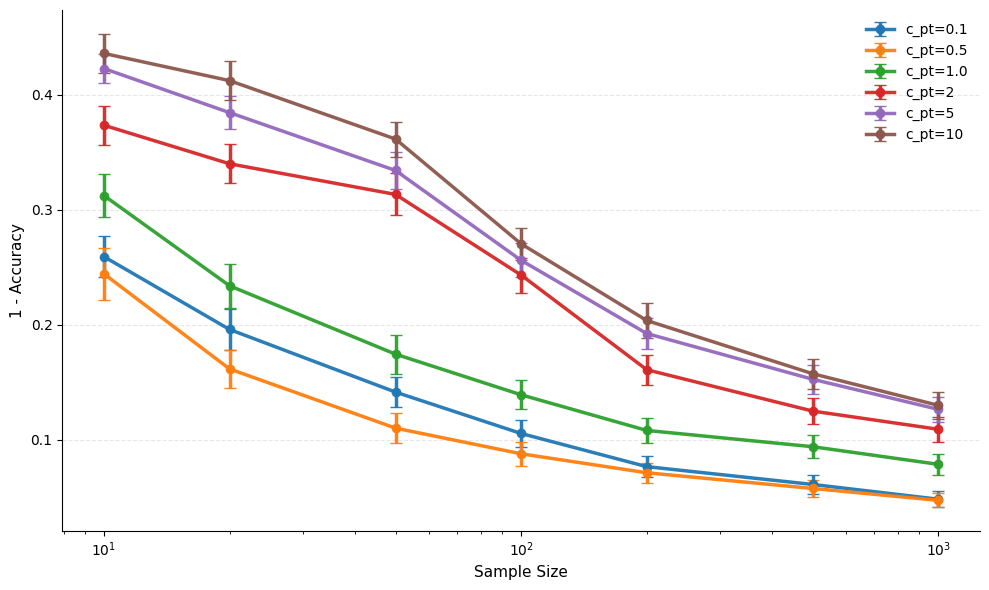

In [3]:
plot_merged_run_and_csv(
    run_data=run_data,
    #csv_path="/nfs/nhome/live/cdomine/nested_feature/experiments/cifar/data/cifar/resnet_acc_max.csv",
    metric_name="accs",
    type_val="valid",
    alphas = [0.1,0.5,1.0,2,5,10],
    seeds=list(range(30)),
    samples=[10, 20, 50, 100, 200, 500, 1000],
    error_type="se")

[WARN] α=0.1 produced all-NaN. Skipping.
[WARN] α=0.5 produced all-NaN. Skipping.
[WARN] α=1.0 produced all-NaN. Skipping.
[WARN] α=2 produced all-NaN. Skipping.
[WARN] α=5 produced all-NaN. Skipping.
[WARN] α=10 produced all-NaN. Skipping.


/tmp/ipykernel_2633098/1654182257.py:97: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


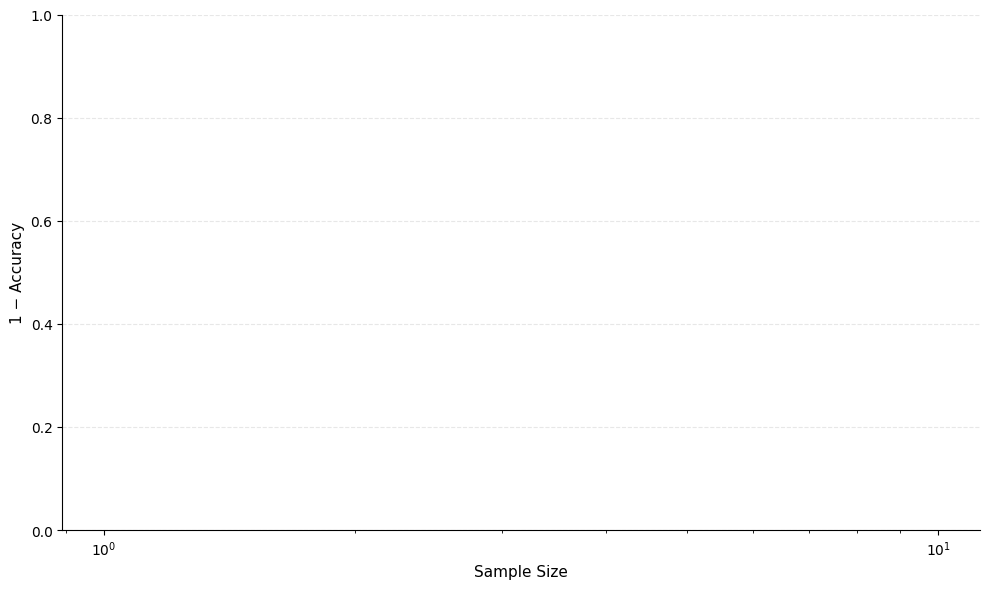

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm


def _err_from_vals(vals, error_type="se"):
    vals = np.asarray(vals, dtype=float)
    mean = float(np.mean(vals))
    std = float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0
    err = std if error_type == "std" else std / np.sqrt(len(vals))
    return mean, err


def plot_merged_run_and_csv(
    run_data,
    metric_name,
    type_val,
    alphas,
    seeds,
    samples,
    log_x=True,
    use_one_minus_acc=True,
    error_type="se",
):
    assert error_type in {"std", "se"}

    fig, ax = plt.subplots(figsize=(10, 6))

    # ---- colormap with LOG-scaled alpha ----
    cmap = plt.colormaps["viridis"] if hasattr(plt, "colormaps") else plt.cm.get_cmap("viridis")
    norm = LogNorm(vmin=min(alphas), vmax=max(alphas))

    metric_lower = str(metric_name).lower()
    do_one_minus_run = use_one_minus_acc and ("acc" in metric_lower or "accuracy" in metric_lower)

    # --------- RUN_DATA PLOT ----------
    for alpha in alphas:
        means, errs = [], []

        for sample in samples:
            vals = []
            for seed in seeds:
                try:
                    data_matrix = run_data[metric_name][alpha][sample]
                    v = data_matrix[seed]
                    data_dict = v.item() if hasattr(v, "item") else v

                    y = np.max(data_dict[type_val])
                    if do_one_minus_run:
                        y = 1.0 - y

                    # protect log plots
                    if y <= 0:
                        continue

                    vals.append(y)

                except (KeyError, IndexError, TypeError, ValueError):
                    continue

            if len(vals) == 0:
                means.append(np.nan)
                errs.append(np.nan)
            else:
                m, e = _err_from_vals(vals, error_type)
                means.append(m)
                errs.append(e)

        if np.all(np.isnan(means)):
            print(f"[WARN] α={alpha} produced all-NaN. Skipping.")
            continue

        ax.errorbar(
            samples,
            means,
            yerr=errs,
            label=f"c_pt={alpha}",
            color=cmap(norm(alpha)),
            marker="o",
            linestyle="-",
            linewidth=2.5,
            capsize=4,
            alpha=0.95,
            zorder=3,
        )

    # --------- Styling ----------
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if log_x:
        ax.set_xscale("log")

    ax.set_xlabel("Sample Size", fontsize=11)
    ax.set_ylabel("1 − Accuracy", fontsize=11)

    ax.legend(frameon=False)
    ax.yaxis.grid(True, linestyle="--", alpha=0.3)

    # --------- Log-scaled colorbar ----------
    # sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    # sm.set_array([])
    # cbar = plt.colorbar(sm, ax=ax, pad=0.02)
    # cbar.set_label("c_pt (alpha)", rotation=270, labelpad=15)

    plt.tight_layout()
    plt.show()

plot_merged_run_and_csv(
    run_data=run_data,
    #csv_path="/nfs/nhome/live/cdomine/nested_feature/experiments/cifar/data/cifar/resnet_acc_max.csv",
    metric_name="accs",
    type_val="valid",
    alphas = [0.1,0.5,1.0,2,5,10],
    seeds=list(range(30)),
    samples=[10, 20, 50, 100, 200, 500, 1000],
    error_type="se")

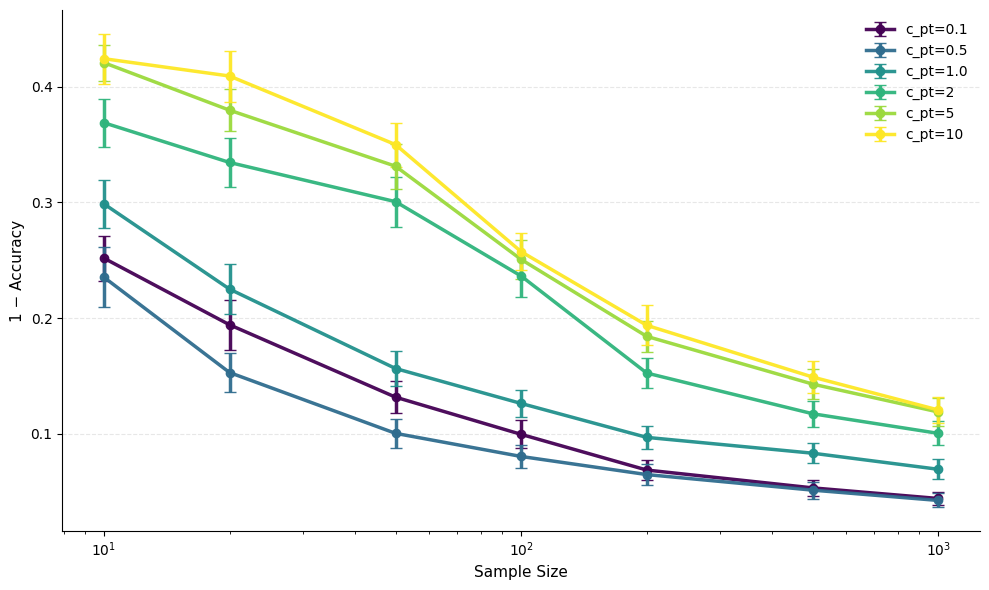

In [ ]:
plot_merged_run_and_csv(
    run_data=run_data,
    #csv_path="/nfs/nhome/live/cdomine/nested_feature/experiments/cifar/data/cifar/resnet_acc_max.csv",
    metric_name="accs",
    type_val="valid",
    alphas = [0.1,0.5,1.0,2,5,10],
    seeds=list(range(30)),
    samples=[10, 20, 50, 100, 200, 500, 1000],
    error_type="se")

In [118]:
import torch
import numpy as np
import pandas as pd
from pathlib import Path

# --- Configuration ---
seeds = list(range(20))
n_samples= [10, 50, 100, 200, 500, 1000]
alphas = [0.1,0.5,1.0,2,5,10]
base_path = Path("/nfs/scistore19/locatgrp/cdomine/multi-task/data/cifar/ensd_sam_scalled_2/")


# Nested dictionary for structured access
run_data = {
    "df": {a: {s: [] for s in n_samples} for a in alphas},
}
all_long = []  # Stores long-format rows for every run
all_wide = []  # Stores wide-format per run

# --- Data Loading Loop ---
for alpha in alphas:
    for seed in seeds:
        for n_sample in n_samples:
            # Construct folder name based on experimental parameters
            folder_name = (
                f"random_seed={seed}--n_samples={n_sample}--alpha_load={alpha}"
            ) 
           
            dir_path = base_path / folder_name
            csv_path = dir_path / "df.csv"

            if not csv_path.exists():
                print(f'not downloaded {csv_path}')
                continue

            # --- Read CSV (long format: value, variable, layer) ---
            df = pd.read_csv(csv_path)

            # Cleanup: drop stray index column if present
            if "Unnamed: 0" in df.columns:
                df = df.drop(columns=["Unnamed: 0"])

            # Ensure expected columns exist
            expected = {"value", "variable", "layer"}
            missing = expected - set(df.columns)
            if missing:
                raise ValueError(f"{csv_path} is missing columns: {missing}")

            # Enforce data types
            df["value"] = df["value"].astype(float)
            df["layer"] = df["layer"].astype(int)

            # Add metadata for filtering/grouping
            df["alpha"] = float(alpha)
            df["seed"] = int(seed)
            df["n_samples"] = int(n_sample)

            # Save in nested structure and global list
            run_data["df"][alpha][n_sample].append(df)
            all_long.append(df)
            # --- Optional: build wide-format for this run ---
            # Transforms: Layer | Variable_A_Value | Variable_B_Value
            df_wide = (
                df.pivot(index="layer", columns="variable", values="value")
                  .reset_index()
            )
            df_wide["alpha"] = float(alpha)
            df_wide["seed"] = int(seed)
            df_wide["n_samples"] = int(n_sample)
            all_wide.append(df_wide)

# --- Final Aggregation ---
if all_long:
    df_all_long = pd.concat(all_long, ignore_index=True)
else:
    df_all_long = pd.DataFrame()

if all_wide:
    df_all_wide = pd.concat(all_wide, ignore_index=True)
else:
    df_all_wide = pd.DataFrame()
print("All long-format rows:", df_all_long.shape)
print("All wide-format rows:", df_all_wide.shape)



All long-format rows: (20160, 6)
All wide-format rows: (5040, 8)


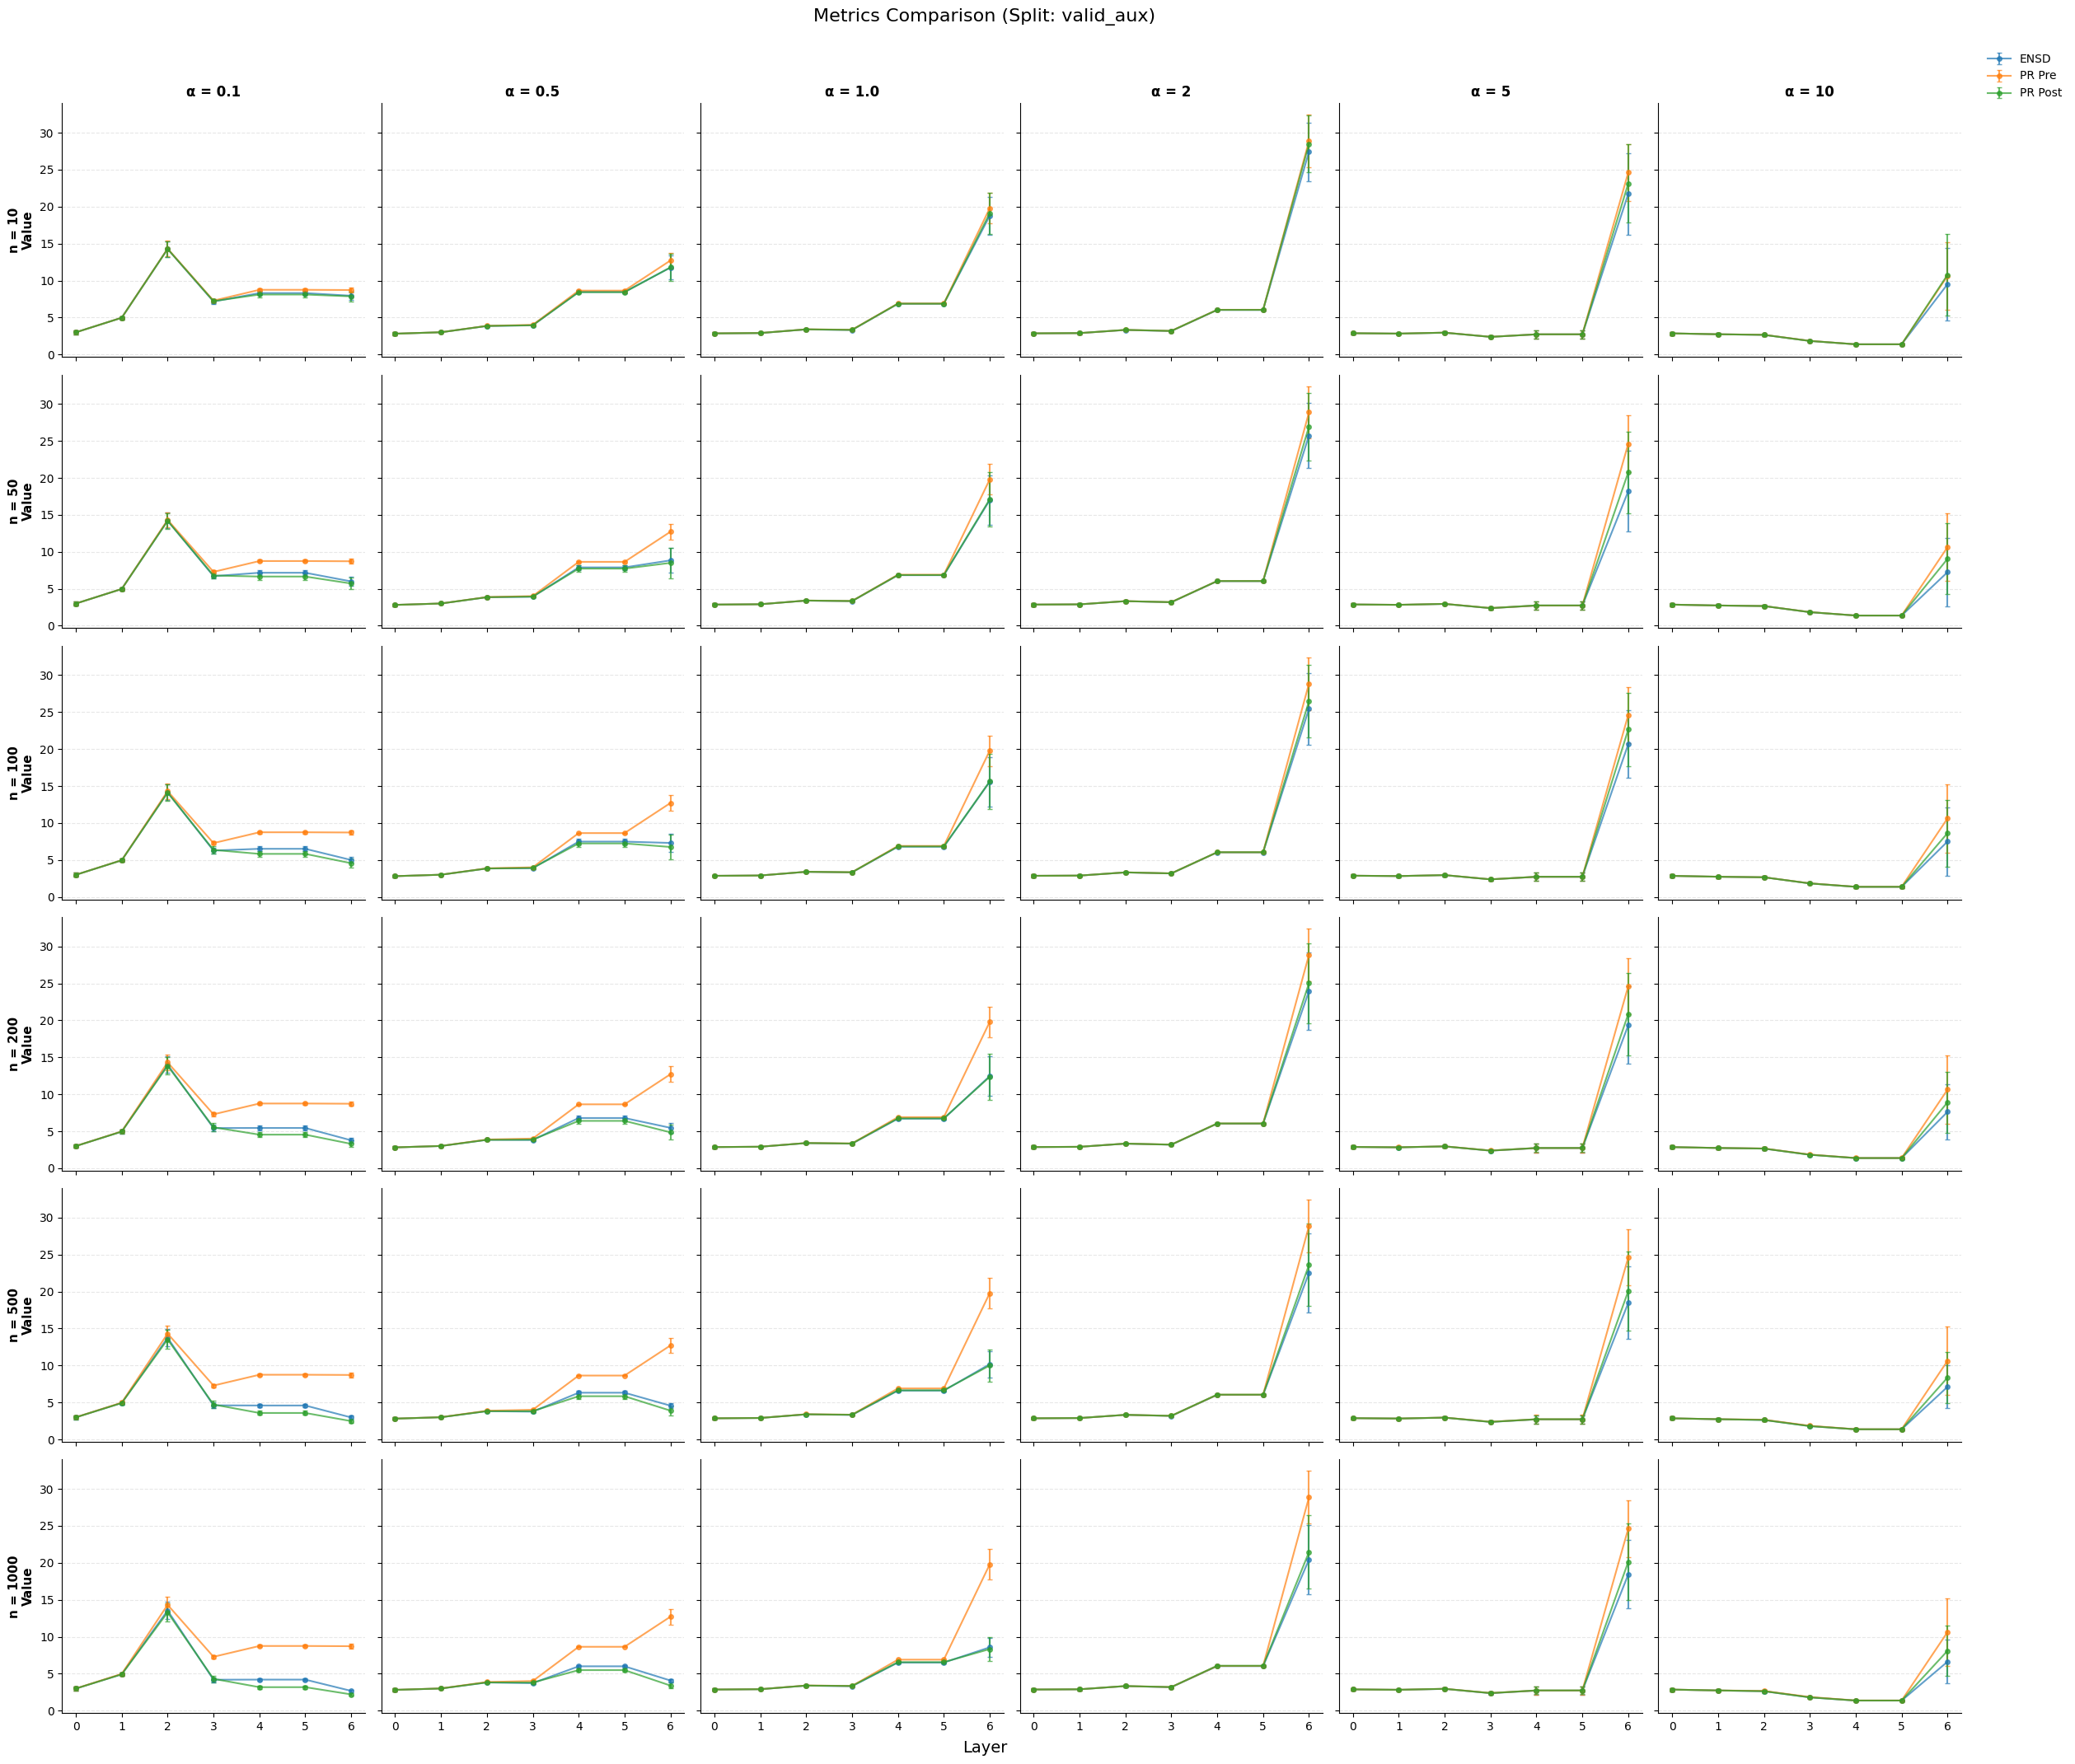

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_values_by_alpha_grid(
    run_data,
    split_name=None,
    *,
    n_samples=[100],
    alphas=(0.1, 0.5, 1.0),
    seeds=None,
    variables=("ENSD", "PR Pre", "PR Post"),
    split_col=("split", "dataset", "name"),
):
    """
    Creates a single large figure grid.
    Rows = n_samples
    Cols = alphas
    """
    num_samples = len(n_samples)
    num_alphas = len(alphas)

    # Create the grid
    fig, axes = plt.subplots(
        num_samples, num_alphas, 
        figsize=(4 * num_alphas, 3.5 * num_samples),
        sharex=True, 
        sharey=True,
        squeeze=False # Ensures axes is always a 2D array [row, col]
    )

    for row_idx, n_sample in enumerate(n_samples):
        for col_idx, alpha in enumerate(alphas):
            ax = axes[row_idx, col_idx]
            
            # Data retrieval
            df_list = run_data["df"].get(alpha, {}).get(n_sample, [])
            
            if not df_list:
                ax.set_title(f"n={n_sample}, α={alpha} (No Data)", fontsize=10)
                continue

            rows = []
            for df in df_list:
                d = df.copy()
                if seeds is not None and "seed" in d.columns:
                    d = d[d["seed"].isin(seeds)]
                if split_name is not None:
                    found_col = next((c for c in split_col if c in d.columns), None)
                    if found_col is not None:
                        d = d[d[found_col] == split_name]
                
                # Filter specifically for your 3 variables
                d = d[d["variable"].isin(variables)]
                if not d.empty:
                    rows.append(d)

            if not rows:
                continue

            df_all = pd.concat(rows, ignore_index=True)
            stats = (
                df_all.groupby(["variable", "layer"])["value"]
                .agg(mean="mean", std="std")
                .reset_index()
            )

            # Plotting
            for var in variables:
                sub = stats[stats["variable"] == var]
                ax.errorbar(
                    sub["layer"], sub["mean"], yerr=sub["std"].fillna(0),
                    marker="o", markersize=4, label=var, linewidth=1.5, capsize=2, alpha=0.7
                )

            # Labels and Styling
            if row_idx == 0:
                ax.set_title(f"α = {alpha}", fontsize=12, fontweight='bold')
            if col_idx == 0:
                ax.set_ylabel(f"n = {n_sample}\nValue", fontsize=11, fontweight='bold')
            
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.grid(True, axis='y', linestyle='--', alpha=0.3)

    # Global labels
    fig.supxlabel("Layer", fontsize=14)
    fig.suptitle(f"Metrics Comparison (Split: {split_name})", fontsize=16, y=1.02)
    
    # Single legend for the whole figure
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(1.05, 1), frameon=False)

    plt.tight_layout()
    plt.show()

# Execution
plot_values_by_alpha_grid(
    run_data,
    split_name="valid_aux",
    n_samples=[10, 50, 100, 200, 500, 1000],
    alphas = [0.1,0.5,1.0,2,5,10],
    seeds=seeds,
    variables=["ENSD", "PR Pre", "PR Post"])

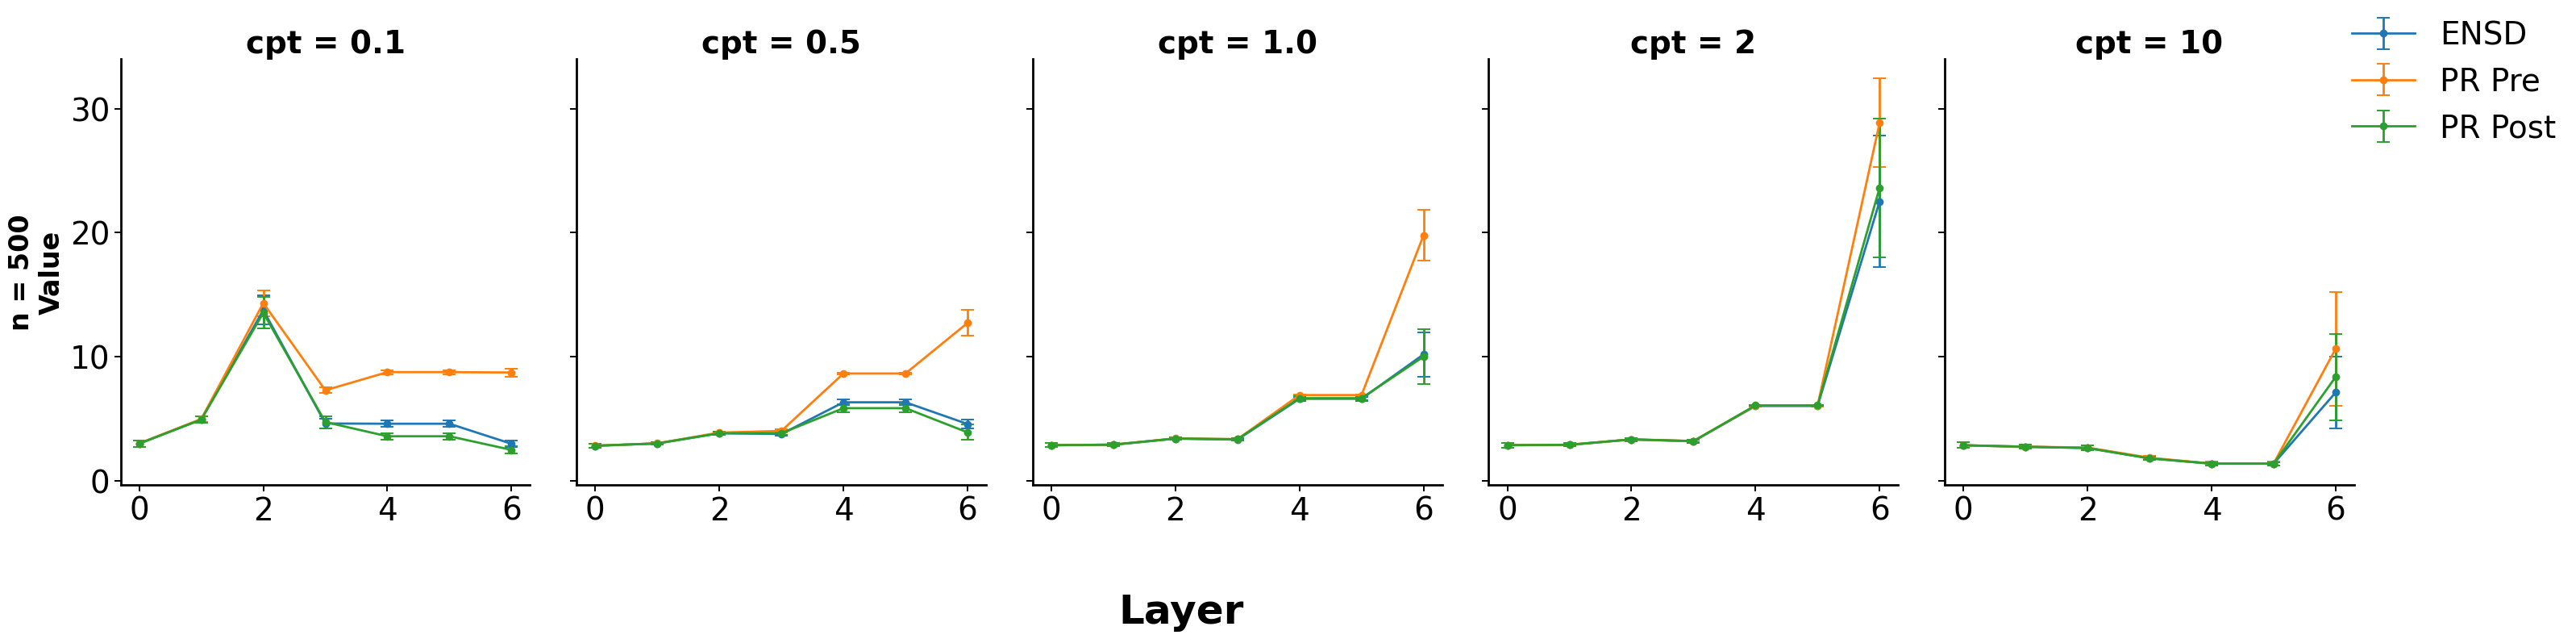

In [124]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

def plot_values_by_alpha_grid(
    run_data,
    split_name=None,
    *,
    n_samples=(100,),
    alphas=(0.1, 0.5, 1.0),
    seeds=None,
    variables=("ENSD", "PR Pre", "PR Post"),
    split_col=("split", "dataset", "name"),
):
    # -----------------------------
    # Global styling (ggplot-like)
    # -----------------------------
    mpl.rcParams.update({
       "font.size": 30,
        "axes.titlesize": 28,
        "axes.labelsize": 24,
        "xtick.labelsize": 28,
        "ytick.labelsize": 28,
        "legend.fontsize": 28,
        "figure.titlesize": 28,
        "axes.linewidth": 2,
    })

    num_rows = len(n_samples)
    num_cols = len(alphas)

    fig, axes = plt.subplots(
        num_rows,
        num_cols,
        figsize=(6 * num_cols, 8 * num_rows),
        sharex=True,
        sharey=True,
        squeeze=False,
    )

    for row_idx, n_sample in enumerate(n_samples):
        for col_idx, alpha in enumerate(alphas):
            ax = axes[row_idx, col_idx]

            df_list = run_data["df"].get(alpha, {}).get(n_sample, [])
            if not df_list:
                ax.set_title(f"n={n_sample}, α={alpha} (No data)")
                continue

            rows = []
            for df in df_list:
                d = df.copy()

                if seeds is not None and "seed" in d.columns:
                    d = d[d["seed"].isin(seeds)]

                if split_name is not None:
                    col = next((c for c in split_col if c in d.columns), None)
                    if col is not None:
                        d = d[d[col] == split_name]

                d = d[d["variable"].isin(variables)]
                if not d.empty:
                    rows.append(d)

            if not rows:
                continue

            df_all = pd.concat(rows, ignore_index=True)

            stats = (
                df_all.groupby(["variable", "layer"])["value"]
                .agg(mean="mean", std="std")
                .reset_index()
            )

            # -----------------------------
            # Plot with caps
            # -----------------------------
            for var in variables:
                sub = stats[stats["variable"] == var]
                ax.errorbar(
                    sub["layer"],
                    sub["mean"],
                    yerr=sub["std"].fillna(0),
                    marker="o",
                    markersize=6,
                    linewidth=2.0,
                    capsize=6,
                    capthick=1.4,
                    label=var,
                )

            # -----------------------------
            # Titles & labels
            # -----------------------------
            if row_idx == 0:
                ax.set_title(f"cpt = {alpha}", fontweight="bold")

            if col_idx == 0:
                ax.set_ylabel(f"n = {n_sample}\nValue", fontweight="bold")

            # -----------------------------
            # Classic theme styling
            # -----------------------------
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            ax.tick_params(axis="both", width=1.4, length=6)
            ax.grid(False)

    # -----------------------------
    # Global labels
    # -----------------------------
    fig.supxlabel("Layer", fontweight="bold")
    #fig.suptitle(
      #  f"Metrics Comparison (Split: {split_name})",
      ##  y=1.02,
       # fontweight="bold",
   # )

    # -----------------------------
    # One legend for all subplots
    # -----------------------------
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="upper right",
        bbox_to_anchor=(1.08, 1.0),
        frameon=False,
    )

    plt.tight_layout()
    plt.show()
plot_values_by_alpha_grid(
    run_data,
    split_name="valid_aux",
    n_samples=[500],
    alphas =[0.1,0.5,1.0,2,10],
    seeds=seeds,
    variables=["ENSD", "PR Pre", "PR Post"])

In [3]:
import torch
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
def plot_metric_across_alphas(run_data, metric_name, type, alphas, seeds):
    """
    Plots a specific metric for all alphas with error bars and removed top/right borders.
    """
    fig, ax = plt.subplots(figsize=(10, 6))
    
    colors = plt.cm.get_cmap('tab10', len(alphas))
   
    for i, alpha in enumerate(alphas):
        train_aux_values = []
        for seed in seeds:
            data_matrix = run_data[metric_name][alpha]
            data_dict = data_matrix[seed].item()
            train_aux_values.append(data_dict[type])
                
        # Calculate statistics
        min_len = min(len(arr) for arr in train_aux_values)
        truncated_matrix = np.stack([arr[:min_len] for arr in train_aux_values])

        mean_vector = np.mean(truncated_matrix, axis=0)
        std_vector = np.std(truncated_matrix, axis=0)
        epochs = np.arange(len(mean_vector))
        color = colors(i)
        
        # Plot with error bars instead of fill_between
        # 'errorevery=5' prevents the plot from becoming too cluttered
        ax.errorbar(
            epochs, 
            mean_vector, 
            yerr=std_vector, 
            label=f'α={alpha}', 
            color=color, 
            linewidth=2,
            capsize=3,
            errorevery=1, 
            alpha=0.8
        )

    # --- Styling ---
    # Remove top and right spines (borders)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.set_title(f'Mean {metric_name.capitalize()} {type.capitalize()} across Seeds', fontsize=14)
    ax.set_xlabel('Epochs')
    ax.set_ylabel(metric_name.capitalize())
    ax.legend(title="Alpha Values", frameon=False) # Removed frame to match clean style
    
    plt.tight_layout()
    plt.show()
# --- Example Usage ---
# plot_metric_across_alphas(run_data, 'accs', alphas=[0.1, 0.5, 1.0])
# plot_metric_across_alphas(run_data, 'losses', alphas=[0.1, 0.5, 1.0])
    


In [ ]:
# 12334 block

In [1]:
import torch
import numpy as np
from pathlib import Path

seeds = list(range(30))
alphas=[0.1,0.5,1.0,2,5,10]
base_path = Path("/nfs/scistore19/locatgrp/cdomine/multi-task/data/cifar/pretrain_base/")
run_data = {
    'losses': {a: [] for a in alphas},
    'accs': {a: [] for a in alphas},
    'models': {a: [] for a in alphas},
    'l2_regs': {a: [] for a in alphas}
}

for alpha in alphas:
    for seed in seeds:
        folder_name = (
            f"random_seed={seed}"
            f"--model=resnet"
            f"--alpha={alpha}"
        )
        print(seed, alpha)
        dir_path = base_path / folder_name
        if dir_path.exists():
            # Load and append data to the lists
            if (dir_path / "losses.npy").exists():
                run_data['losses'][alpha].append(np.load(dir_path / "losses.npy",allow_pickle=True))
                print(f"✅ Loaded Seed {seed}, Alpha {alpha}, Losses")
            if (dir_path / "accs.npy").exists():
                run_data['accs'][alpha].append(np.load(dir_path / "accs.npy",allow_pickle=True))
                print(f"✅ Loaded Seed {seed}, Alpha {alpha}, Accs")
        else:
            print(f"Missing directory: {folder_name}")

# Convert lists to numpy arrays for easier math later: run_data['accs'][0.1] will be (10, epochs)
for metric in ['losses', 'accs','l2_regs']:
    for alpha in alphas:
        if run_data[metric][alpha]:
            run_data[metric][alpha] = np.array(run_data[metric][alpha])




0 0.1
✅ Loaded Seed 0, Alpha 0.1, Losses
✅ Loaded Seed 0, Alpha 0.1, Accs
1 0.1
✅ Loaded Seed 1, Alpha 0.1, Losses
✅ Loaded Seed 1, Alpha 0.1, Accs
2 0.1
✅ Loaded Seed 2, Alpha 0.1, Losses
✅ Loaded Seed 2, Alpha 0.1, Accs
3 0.1
✅ Loaded Seed 3, Alpha 0.1, Losses
✅ Loaded Seed 3, Alpha 0.1, Accs
4 0.1
✅ Loaded Seed 4, Alpha 0.1, Losses
✅ Loaded Seed 4, Alpha 0.1, Accs
5 0.1
✅ Loaded Seed 5, Alpha 0.1, Losses
✅ Loaded Seed 5, Alpha 0.1, Accs
6 0.1
✅ Loaded Seed 6, Alpha 0.1, Losses
✅ Loaded Seed 6, Alpha 0.1, Accs
7 0.1
✅ Loaded Seed 7, Alpha 0.1, Losses
✅ Loaded Seed 7, Alpha 0.1, Accs
8 0.1
✅ Loaded Seed 8, Alpha 0.1, Losses
✅ Loaded Seed 8, Alpha 0.1, Accs
9 0.1
✅ Loaded Seed 9, Alpha 0.1, Losses
✅ Loaded Seed 9, Alpha 0.1, Accs
10 0.1
✅ Loaded Seed 10, Alpha 0.1, Losses
✅ Loaded Seed 10, Alpha 0.1, Accs
11 0.1
✅ Loaded Seed 11, Alpha 0.1, Losses
✅ Loaded Seed 11, Alpha 0.1, Accs
12 0.1
✅ Loaded Seed 12, Alpha 0.1, Losses
✅ Loaded Seed 12, Alpha 0.1, Accs
13 0.1
✅ Loaded Seed 13, Alph

/tmp/ipykernel_2480864/2253447913.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(alphas))


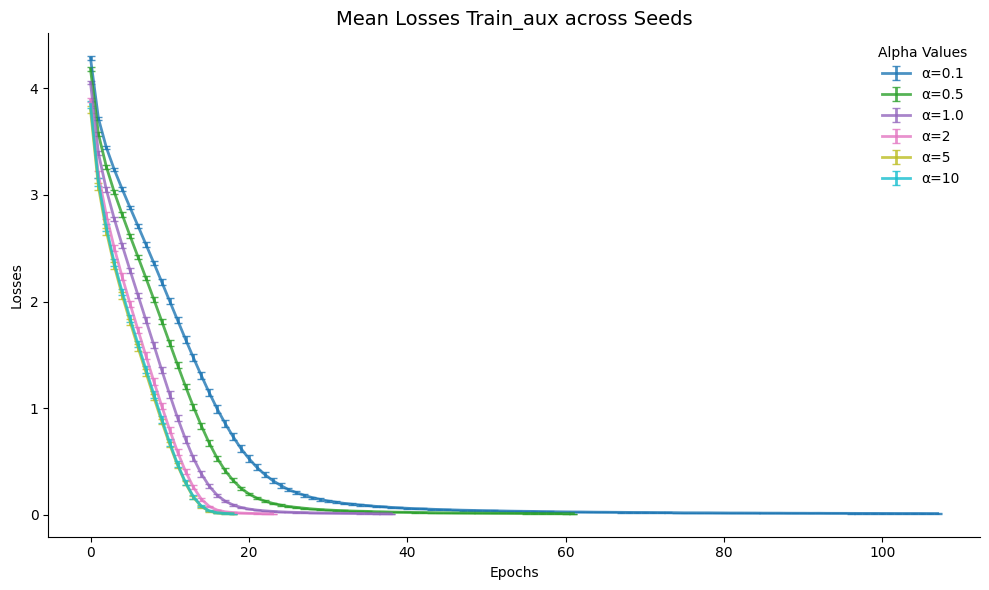

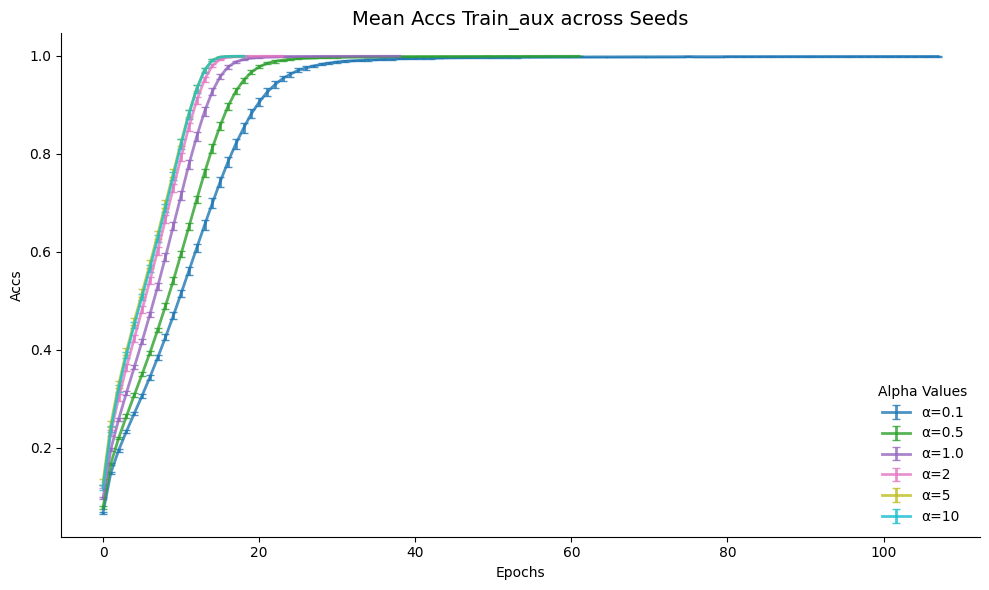

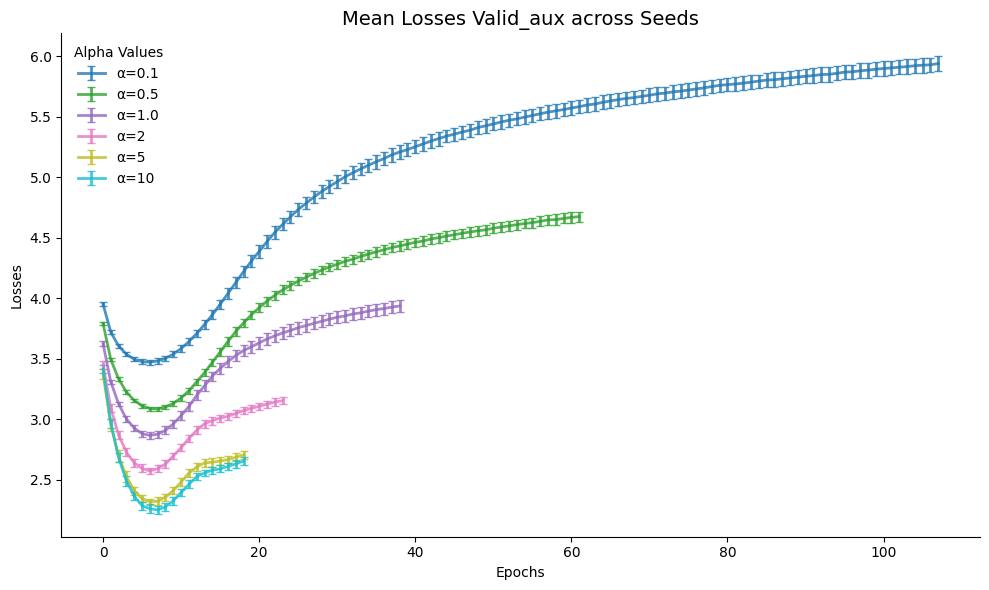

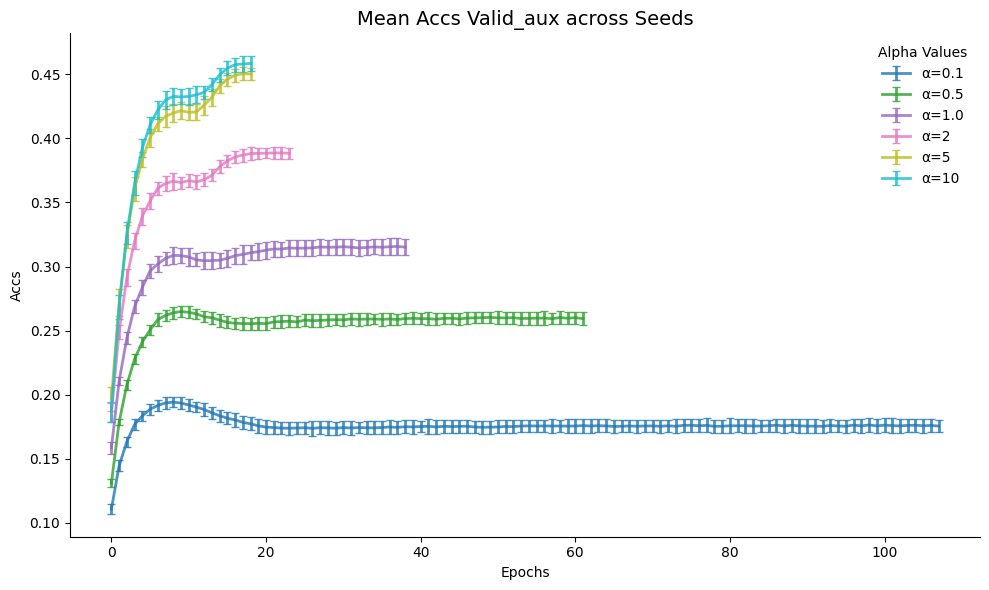

In [5]:
seeds = list(range(30))
plot_metric_across_alphas(run_data, 'losses','train_aux' ,   alphas=[0.1,0.5,1.0,2,5,10],seeds=seeds) #plot_metric_across_alphas(run_data, 'losses', alphas=[0.1, 0.5, 1.0])
plot_metric_across_alphas(run_data, 'accs', 'train_aux', alphas=[0.1,0.5,1.0,2,5,10],seeds=seeds)
plot_metric_across_alphas(run_data, 'losses','valid_aux' , alphas=[0.1,0.5,1.0,2,5,10],seeds=seeds) #plot_metric_across_alphas(run_data, 'losses', alphas=[0.1, 0.5, 1.0])
plot_metric_across_alphas(run_data, 'accs', 'valid_aux' , alphas=[0.1,0.5,1.0,2,5,10],seeds=seeds) #

In [126]:
import os
import pandas as pd
import numpy as np
import plotnine as gg
from pathlib import Path

# Updated path based on your snippet
base_path = Path("/nfs/scistore19/locatgrp/cdomine/multi-task/data/cifar/finetune_123alpha/")
output_path = '/nfs/scistore19/locatgrp/cdomine/multi-task/data/cifar/finetune_123alpha_max.csv'

data_list = []

for folder in os.listdir(base_path):
    folder_path = base_path / folder
    acc_file = folder_path / 'accs.npy'
    
    if acc_file.exists():
        try:
            # Load the dictionary of accuracies
            acc_data = np.load(acc_file, allow_pickle=True)[()]
            
            # Create dataframe with max values for each metric
            new_df = pd.DataFrame({
                k: [v.max()] for k, v in acc_data.items() if len(v) != 0
            })
            
            # Parse the new folder naming convention: 
            # random_seed={seed}--alpha_load={alpha}--n_samples={n_sample}--model=resnet
            parts = folder.split('--')
            params = {p.split('=')[0]: p.split('=')[1] for p in parts}
            
            new_df['rs'] = params.get('random_seed')
            new_df['scaling'] = float(params.get('alpha_load', 1.0)) # alpha_load is scaling
            new_df['n_samples'] = int(params.get('n_samples', 0))
            new_df['model'] = params.get('model')
            
            # Setting 'mode' as 'finetuning' for consistency with your plotting code
            new_df['mode'] = 'finetuning' 
            
            data_list.append(new_df)
        except Exception as e:
            print(f"Skipping {folder} due to error: {e}")

# Combine and save
df = pd.concat(data_list, ignore_index=True)
df.to_csv(output_path, index=False)

### Visualization




/nfs/scistore19/locatgrp/cdomine/miniforge3/envs/NPG-env/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
/nfs/scistore19/locatgrp/cdomine/miniforge3/envs/NPG-env/lib/python3.12/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_summary : Removed 12 rows containing non-finite values.
/nfs/scistore19/locatgrp/cdomine/miniforge3/envs/NPG-env/lib/python3.12/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_summary : Removed 12 rows containing non-finite values.


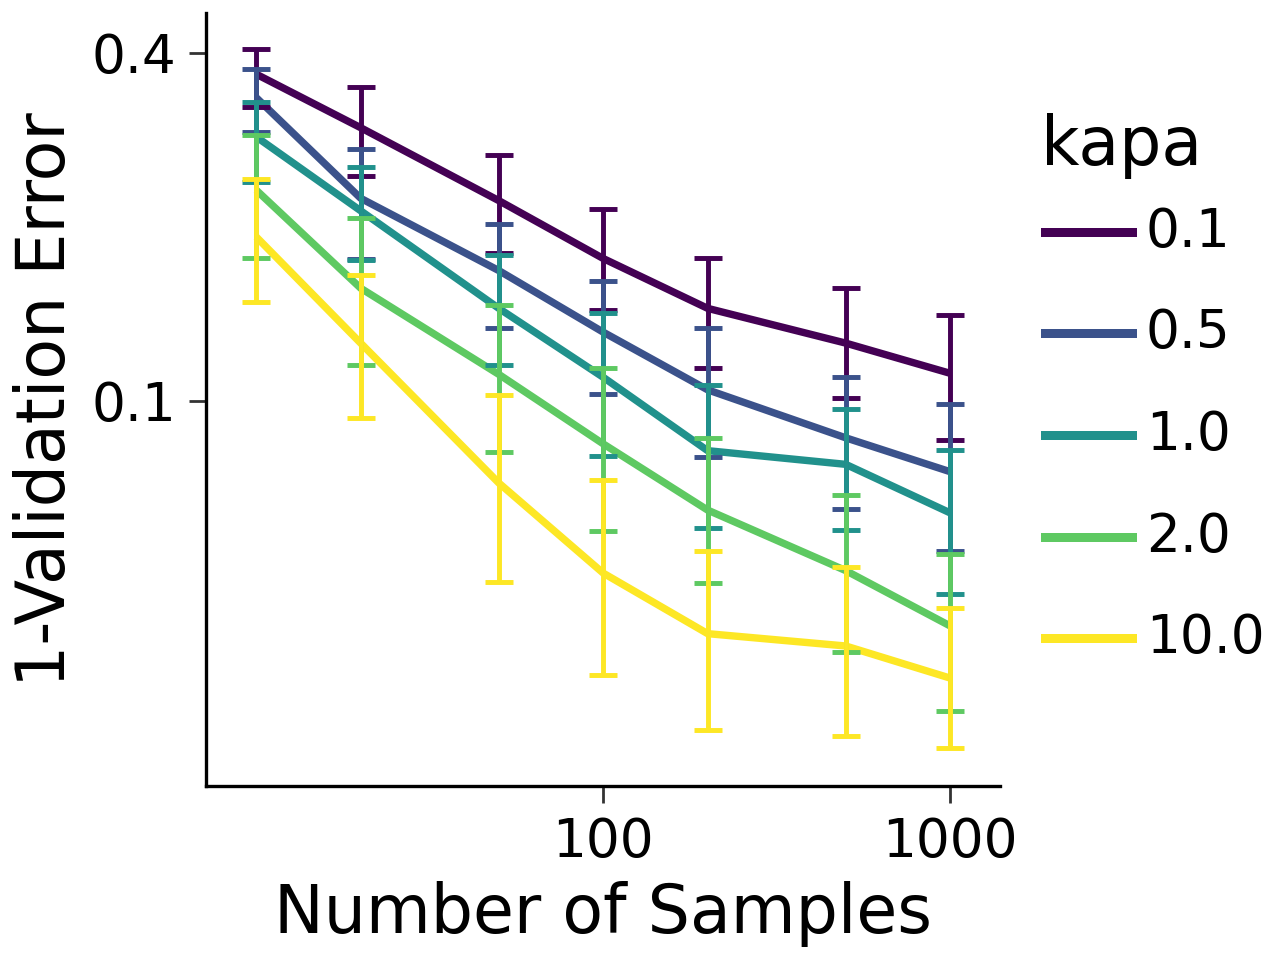

In [129]:
(
    gg.ggplot(
        df_plot,
        gg.aes(
            x='n_samples',
            y='1-valid',
            color='factor(scaling)',
            group='scaling'
        )
    ) +
    gg.stat_summary(geom='line', size=1.5) +
    gg.stat_summary(
        geom='errorbar',
        size=1.0,
        width=0.08
    ) +
    gg.scale_x_log10(breaks=x_breaks) +
    gg.scale_y_log10(breaks=y_breaks) +
    gg.scale_color_cmap_d(name='kapa') +
    gg.theme_classic(base_size=24) +
    gg.labs(
        x="Number of Samples",
        y="1-Validation Error",
        color="Alpha Load"
    ) +
    gg.theme(
        panel_grid_major=gg.element_blank(),
        panel_grid_minor=gg.element_blank(),
        axis_text=gg.element_text(color="black"),
        axis_line=gg.element_line(size=1.2)
    )
)




/nfs/scistore19/locatgrp/cdomine/miniforge3/envs/NPG-env/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
/nfs/scistore19/locatgrp/cdomine/miniforge3/envs/NPG-env/lib/python3.12/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_summary : Removed 12 rows containing non-finite values.
/nfs/scistore19/locatgrp/cdomine/miniforge3/envs/NPG-env/lib/python3.12/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_summary : Removed 12 rows containing non-finite values.


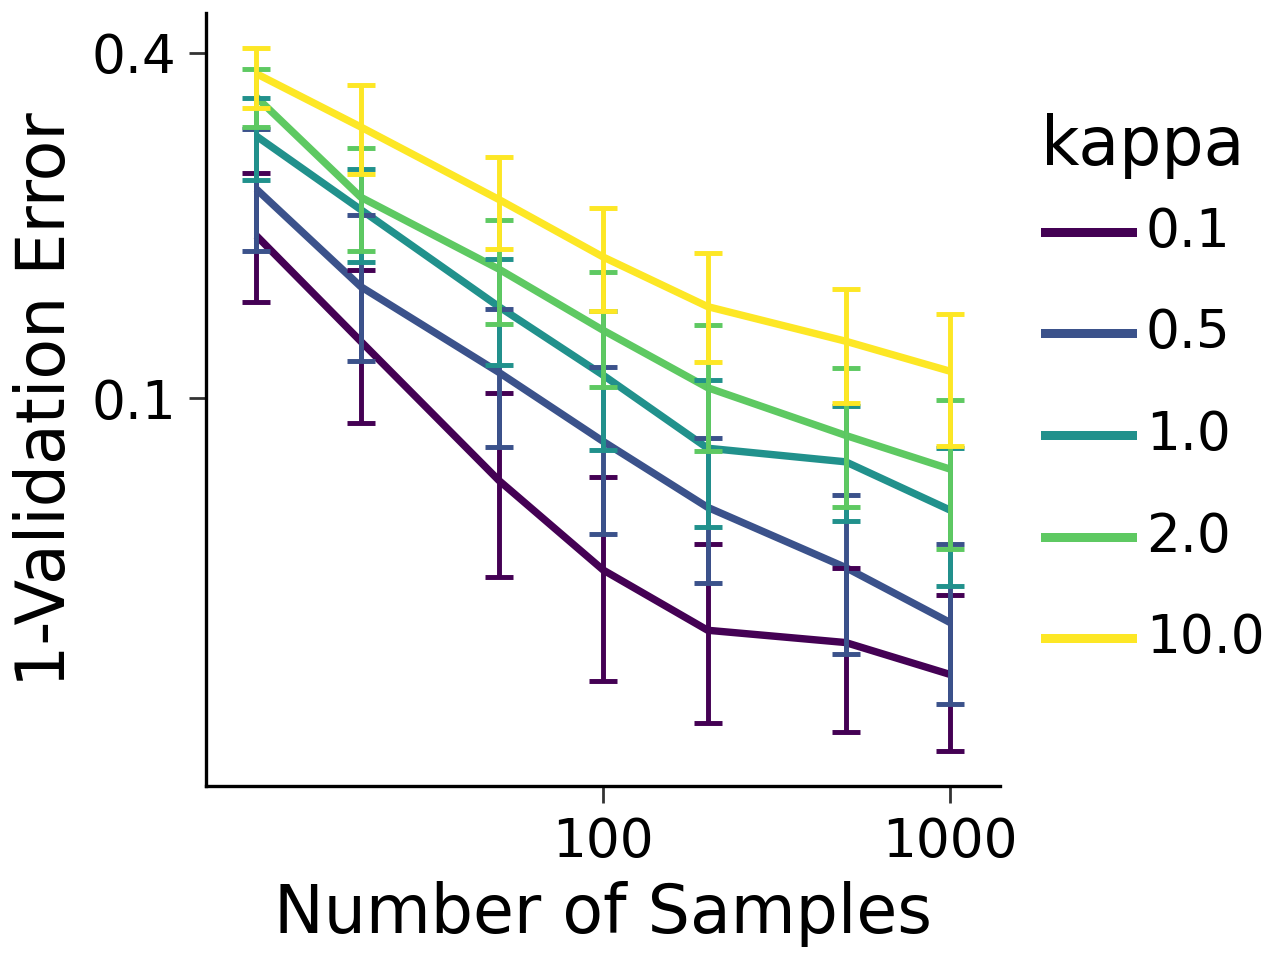

In [128]:
x_breaks = [100, 1000, 10000] 
y_breaks = [0.1, 0.4]    
df_plot = df[df['scaling'] != 5].copy()
df_plot['inv_scaling'] = 1.0 / df_plot['scaling']


(
    gg.ggplot(
        df_plot,
        gg.aes(
            x='n_samples',
            y='1-valid',
            color='factor(inv_scaling)',
            group='inv_scaling'
        )
    ) +
    gg.stat_summary(geom='line', size=1.5) +
    gg.stat_summary(
        geom='errorbar',
        size=1.0,
        width=0.08
    ) +
    gg.scale_x_log10(breaks=x_breaks) +
    gg.scale_y_log10(breaks=y_breaks) +
    gg.scale_color_cmap_d(name='kappa') +
    gg.theme_classic(base_size=24) +
    gg.labs(
        x="Number of Samples",
        y="1-Validation Error",
        color="1 / Scaling"
    ) +
    gg.theme(
        panel_grid_major=gg.element_blank(),
        panel_grid_minor=gg.element_blank(),
        axis_text=gg.element_text(color="black"),
        axis_line=gg.element_line(size=1.2)
    )
)


/nfs/scistore19/locatgrp/cdomine/miniforge3/envs/NPG-env/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
/nfs/scistore19/locatgrp/cdomine/miniforge3/envs/NPG-env/lib/python3.12/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_summary : Removed 4 rows containing non-finite values.
/nfs/scistore19/locatgrp/cdomine/miniforge3/envs/NPG-env/lib/python3.12/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_summary : Removed 4 rows containing non-finite values.


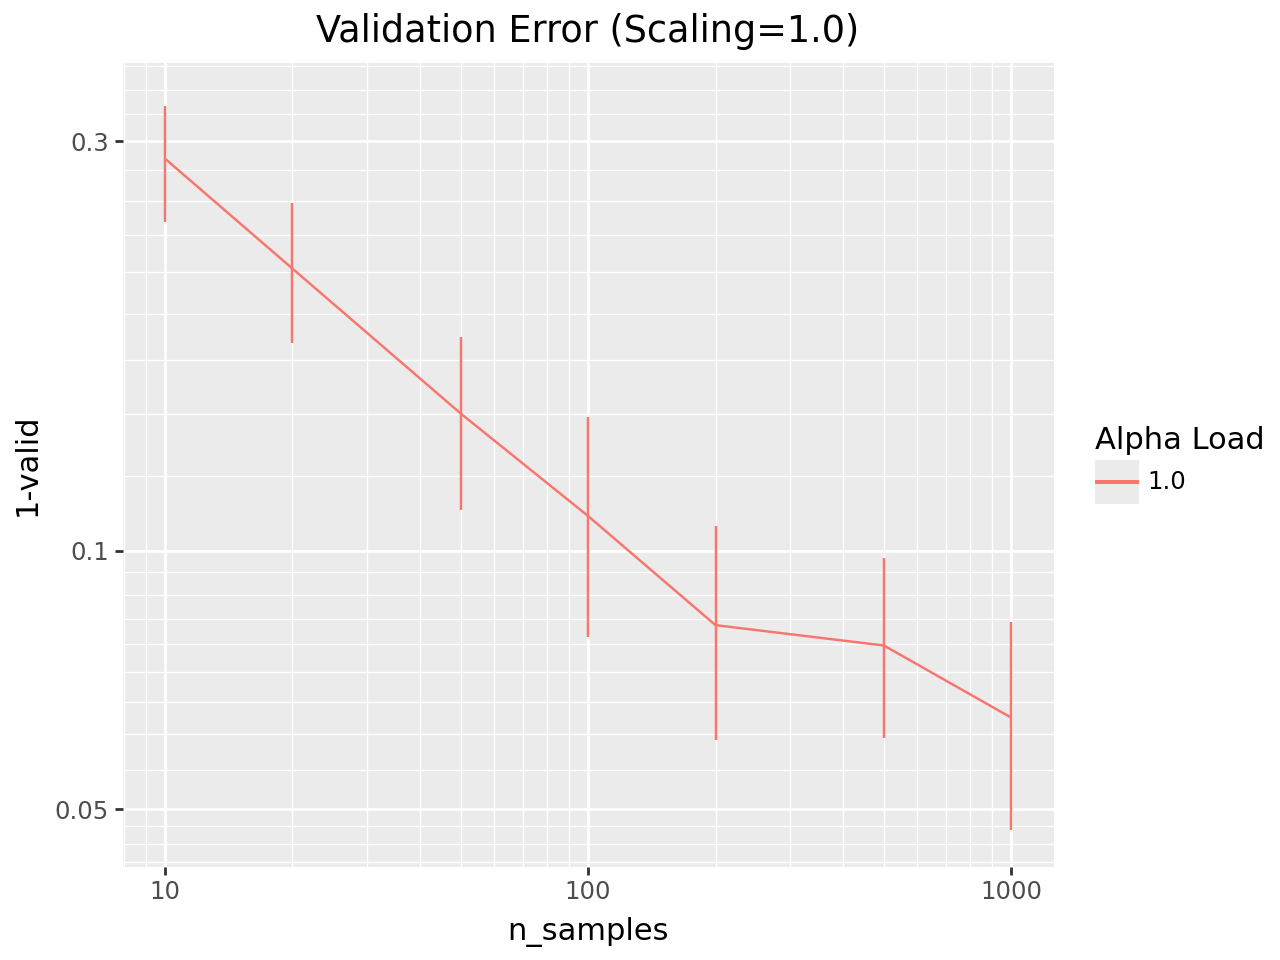

In [ ]:
import torch
import numpy as np
from pathlib import Path
seeds = list(range(30))
alphas = [0.1,0.5,1.0,2,5,10]
 #/nfs/gatsbystor/cdomine/cifar_testing/cifar/main_3/
n_samples=[10, 20, 50, 100, 200, 500, 1000]
#random_seed=0--mode=finetuning--n_samples=10--alpha=1.0--alpha_policy=first_vs_rest--model=resnet
base_path = Path("/nfs/scistore19/locatgrp/cdomine/multi-task/data/cifar/finetune_123alpha/")
 #base_path = Path("/nfs/nhome/live/cdomine/nested_feature/experiments/cifar/data/cifar/main_3/")
run_data = {
    'losses': {a:{s: [] for s in n_samples} for a in alphas},
    'accs': {a: {s: [] for s in n_samples} for a in alphas},
    'models': {a: {s: [] for s in n_samples} for a in alphas},
    'l2_regs': {a: {s: [] for s in n_samples} for a in alphas}
}
for alpha in alphas:
    for seed in seeds:
        for n_sample in n_samples :
            folder_name = (
                f"random_seed={seed}--alpha_load={alpha}--n_samples={n_sample}--model=resnet"
            )
            dir_path = base_path / folder_name
            if dir_path.exists():
              #    print(f" {seed}, Alpha {alpha}, Sample {n_sample}, Accs"),
                # Load and append data to the lists
                if (dir_path / "losses.npy").exists():
                    run_data['losses'][alpha][n_sample].append(np.load(dir_path / "losses.npy",allow_pickle=True))
                    print(f"✅ Loaded Seed {seed}, Alpha {alpha}, Sample {n_sample}, Losses")
                if (dir_path / "l2_regs.npy").exists():
                    run_data['l2_regs'][alpha][n_sample].append(np.load(dir_path / "l2_regs.npy",allow_pickle=True))
                    print(f"✅ Loaded Seed {seed}, Alpha {alpha}, Sample {n_sample}, l2_regs")
                if (dir_path / "accs.npy").exists():
                    run_data['accs'][alpha][n_sample].append(np.load(dir_path / "accs.npy",allow_pickle=True))
                   #   print(f"✅ Loaded Seed {seed}, Alpha {alpha}, Sample {n_sample}, Accs"),
            else:
                print(f"Missing directory: {folder_name}")

✅ Loaded Seed 0, Alpha 0.1, Sample 10, Losses
✅ Loaded Seed 0, Alpha 0.1, Sample 20, Losses
✅ Loaded Seed 0, Alpha 0.1, Sample 50, Losses
✅ Loaded Seed 0, Alpha 0.1, Sample 100, Losses
✅ Loaded Seed 0, Alpha 0.1, Sample 200, Losses
✅ Loaded Seed 0, Alpha 0.1, Sample 500, Losses
✅ Loaded Seed 0, Alpha 0.1, Sample 1000, Losses
✅ Loaded Seed 1, Alpha 0.1, Sample 10, Losses
✅ Loaded Seed 1, Alpha 0.1, Sample 20, Losses
✅ Loaded Seed 1, Alpha 0.1, Sample 50, Losses
✅ Loaded Seed 1, Alpha 0.1, Sample 100, Losses
✅ Loaded Seed 1, Alpha 0.1, Sample 200, Losses
✅ Loaded Seed 1, Alpha 0.1, Sample 500, Losses
✅ Loaded Seed 1, Alpha 0.1, Sample 1000, Losses
✅ Loaded Seed 2, Alpha 0.1, Sample 10, Losses
✅ Loaded Seed 2, Alpha 0.1, Sample 20, Losses
✅ Loaded Seed 2, Alpha 0.1, Sample 50, Losses
✅ Loaded Seed 2, Alpha 0.1, Sample 100, Losses
✅ Loaded Seed 2, Alpha 0.1, Sample 200, Losses
✅ Loaded Seed 2, Alpha 0.1, Sample 500, Losses
✅ Loaded Seed 2, Alpha 0.1, Sample 1000, Losses
✅ Loaded Seed 3, Al

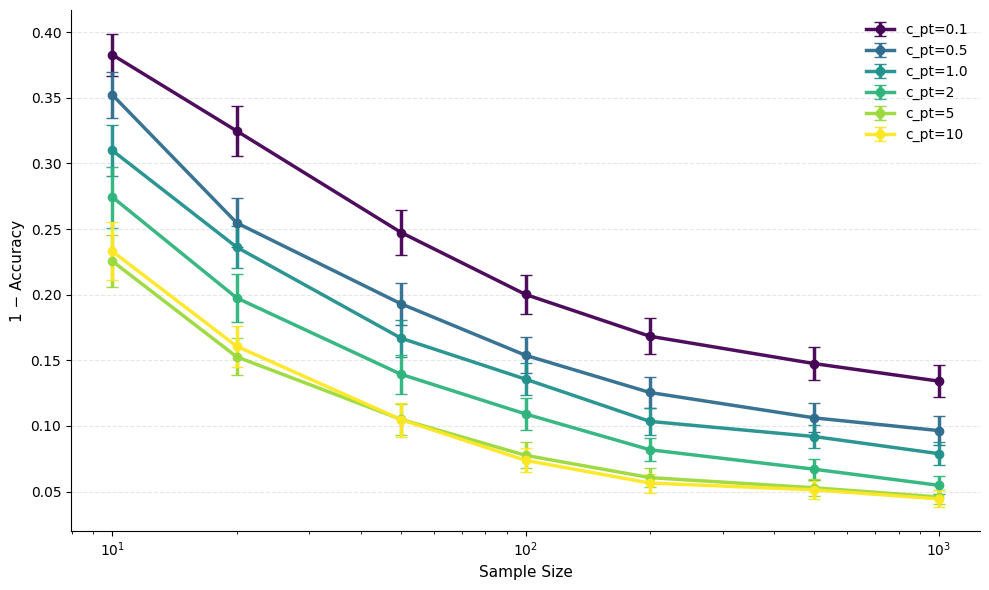

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm


def _err_from_vals(vals, error_type="se"):
    vals = np.asarray(vals, dtype=float)
    mean = float(np.mean(vals))
    std = float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0
    err = std if error_type == "std" else std / np.sqrt(len(vals))
    return mean, err


def plot_merged_run_and_csv(
    run_data,
    metric_name,
    type_val,
    alphas,
    seeds,
    samples,
    log_x=True,
    use_one_minus_acc=True,
    error_type="se",
):
    assert error_type in {"std", "se"}

    fig, ax = plt.subplots(figsize=(10, 6))

    # ---- colormap with LOG-scaled alpha ----
    cmap = plt.colormaps["viridis"] if hasattr(plt, "colormaps") else plt.cm.get_cmap("viridis")
    norm = LogNorm(vmin=min(alphas), vmax=max(alphas))

    metric_lower = str(metric_name).lower()
    do_one_minus_run = use_one_minus_acc and ("acc" in metric_lower or "accuracy" in metric_lower)

    # --------- RUN_DATA PLOT ----------
    for alpha in alphas:
        means, errs = [], []

        for sample in samples:
            vals = []
            for seed in seeds:
                try:
                    data_matrix = run_data[metric_name][alpha][sample]
                    v = data_matrix[seed]
                    data_dict = v.item() if hasattr(v, "item") else v

                    y = np.max(data_dict[type_val])
                    if do_one_minus_run:
                        y = 1.0 - y

                    # protect log plots
                    if y <= 0:
                        continue

                    vals.append(y)

                except (KeyError, IndexError, TypeError, ValueError):
                    continue

            if len(vals) == 0:
                means.append(np.nan)
                errs.append(np.nan)
            else:
                m, e = _err_from_vals(vals, error_type)
                means.append(m)
                errs.append(e)

        if np.all(np.isnan(means)):
            print(f"[WARN] α={alpha} produced all-NaN. Skipping.")
            continue

        ax.errorbar(
            samples,
            means,
            yerr=errs,
            label=f"c_pt={alpha}",
            color=cmap(norm(alpha)),
            marker="o",
            linestyle="-",
            linewidth=2.5,
            capsize=4,
            alpha=0.95,
            zorder=3,
        )

    # --------- Styling ----------
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if log_x:
        ax.set_xscale("log")

    ax.set_xlabel("Sample Size", fontsize=11)
    ax.set_ylabel("1 − Accuracy", fontsize=11)

    ax.legend(frameon=False)
    ax.yaxis.grid(True, linestyle="--", alpha=0.3)

    # --------- Log-scaled colorbar ----------
    # sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    # sm.set_array([])
    # cbar = plt.colorbar(sm, ax=ax, pad=0.02)
    # cbar.set_label("c_pt (alpha)", rotation=270, labelpad=15)

    plt.tight_layout()
    plt.show()


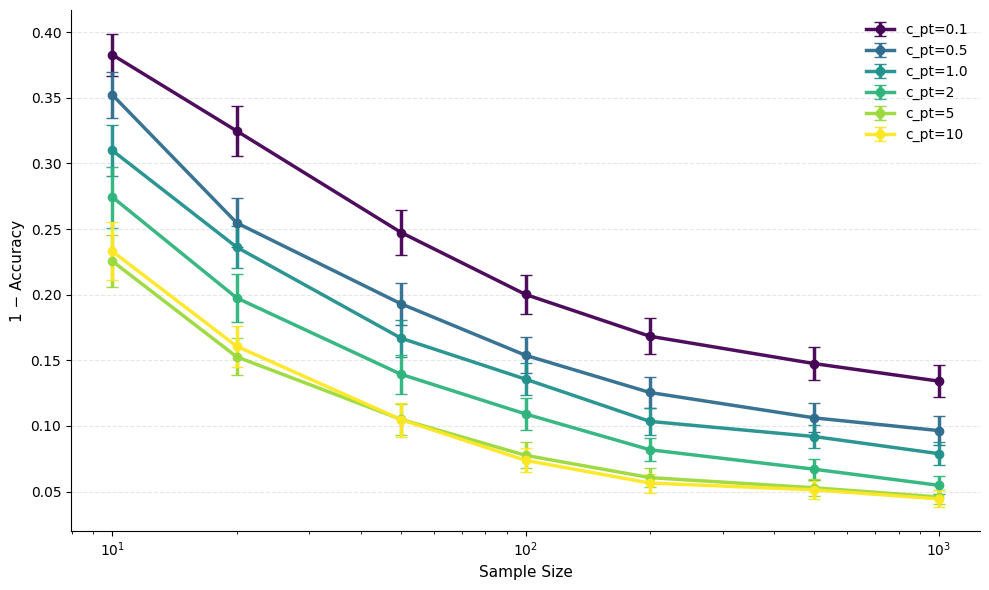

In [8]:
plot_merged_run_and_csv(
    run_data=run_data,
    #csv_path="/nfs/nhome/live/cdomine/nested_feature/experiments/cifar/data/cifar/resnet_acc_max.csv",
    metric_name="accs",
    type_val="valid",
    alphas = [0.1,0.5,1.0,2,5,10],
    seeds=list(range(50)),
    samples=[10, 20, 50, 100, 200, 500, 1000],
    error_type="se")

In [116]:
import numpy as np
import pandas as pd
from pathlib import Path

# --- Configuration ---
seeds = list(range(20))
n_samples= [10, 50, 100, 200, 500, 1000]
alphas = [0.1,0.5,1.0,2,5,10]
base_path = Path("/nfs/scistore19/locatgrp/cdomine/multi-task/data/cifar/ensd_123alpha/")


# Nested dictionary for structured access
run_data = {
    "df": {a: {s: [] for s in n_samples} for a in alphas},
}
all_long = []  # Stores long-format rows for every run
all_wide = []  # Stores wide-format per run

# --- Data Loading Loop ---
for alpha in alphas:
    for seed in seeds:
        for n_sample in n_samples:
            # Construct folder name based on experimental parameters
            folder_name = (
                f"random_seed={seed}--n_samples={n_sample}--alpha_load={alpha}"
            ) 
           
            dir_path = base_path / folder_name
            csv_path = dir_path / "df.csv"

            if not csv_path.exists():
                print(f'not downloaded {csv_path}')
                continue

            # --- Read CSV (long format: value, variable, layer) ---
            df = pd.read_csv(csv_path)

            # Cleanup: drop stray index column if present
            if "Unnamed: 0" in df.columns:
                df = df.drop(columns=["Unnamed: 0"])

            # Ensure expected columns exist
            expected = {"value", "variable", "layer"}
            missing = expected - set(df.columns)
            if missing:
                raise ValueError(f"{csv_path} is missing columns: {missing}")

            # Enforce data types
            df["value"] = df["value"].astype(float)
            df["layer"] = df["layer"].astype(int)

            # Add metadata for filtering/grouping
            df["alpha"] = float(alpha)
            df["seed"] = int(seed)
            df["n_samples"] = int(n_sample)

            # Save in nested structure and global list
            run_data["df"][alpha][n_sample].append(df)
            all_long.append(df)
            # --- Optional: build wide-format for this run ---
            # Transforms: Layer | Variable_A_Value | Variable_B_Value
            df_wide = (
                df.pivot(index="layer", columns="variable", values="value")
                  .reset_index()
            )
            df_wide["alpha"] = float(alpha)
            df_wide["seed"] = int(seed)
            df_wide["n_samples"] = int(n_sample)
            all_wide.append(df_wide)

# --- Final Aggregation ---
if all_long:
    df_all_long = pd.concat(all_long, ignore_index=True)
else:
    df_all_long = pd.DataFrame()

if all_wide:
    df_all_wide = pd.concat(all_wide, ignore_index=True)
else:
    df_all_wide = pd.DataFrame()
print("All long-format rows:", df_all_long.shape)
print("All wide-format rows:", df_all_wide.shape)


All long-format rows: (20160, 6)
All wide-format rows: (5040, 8)


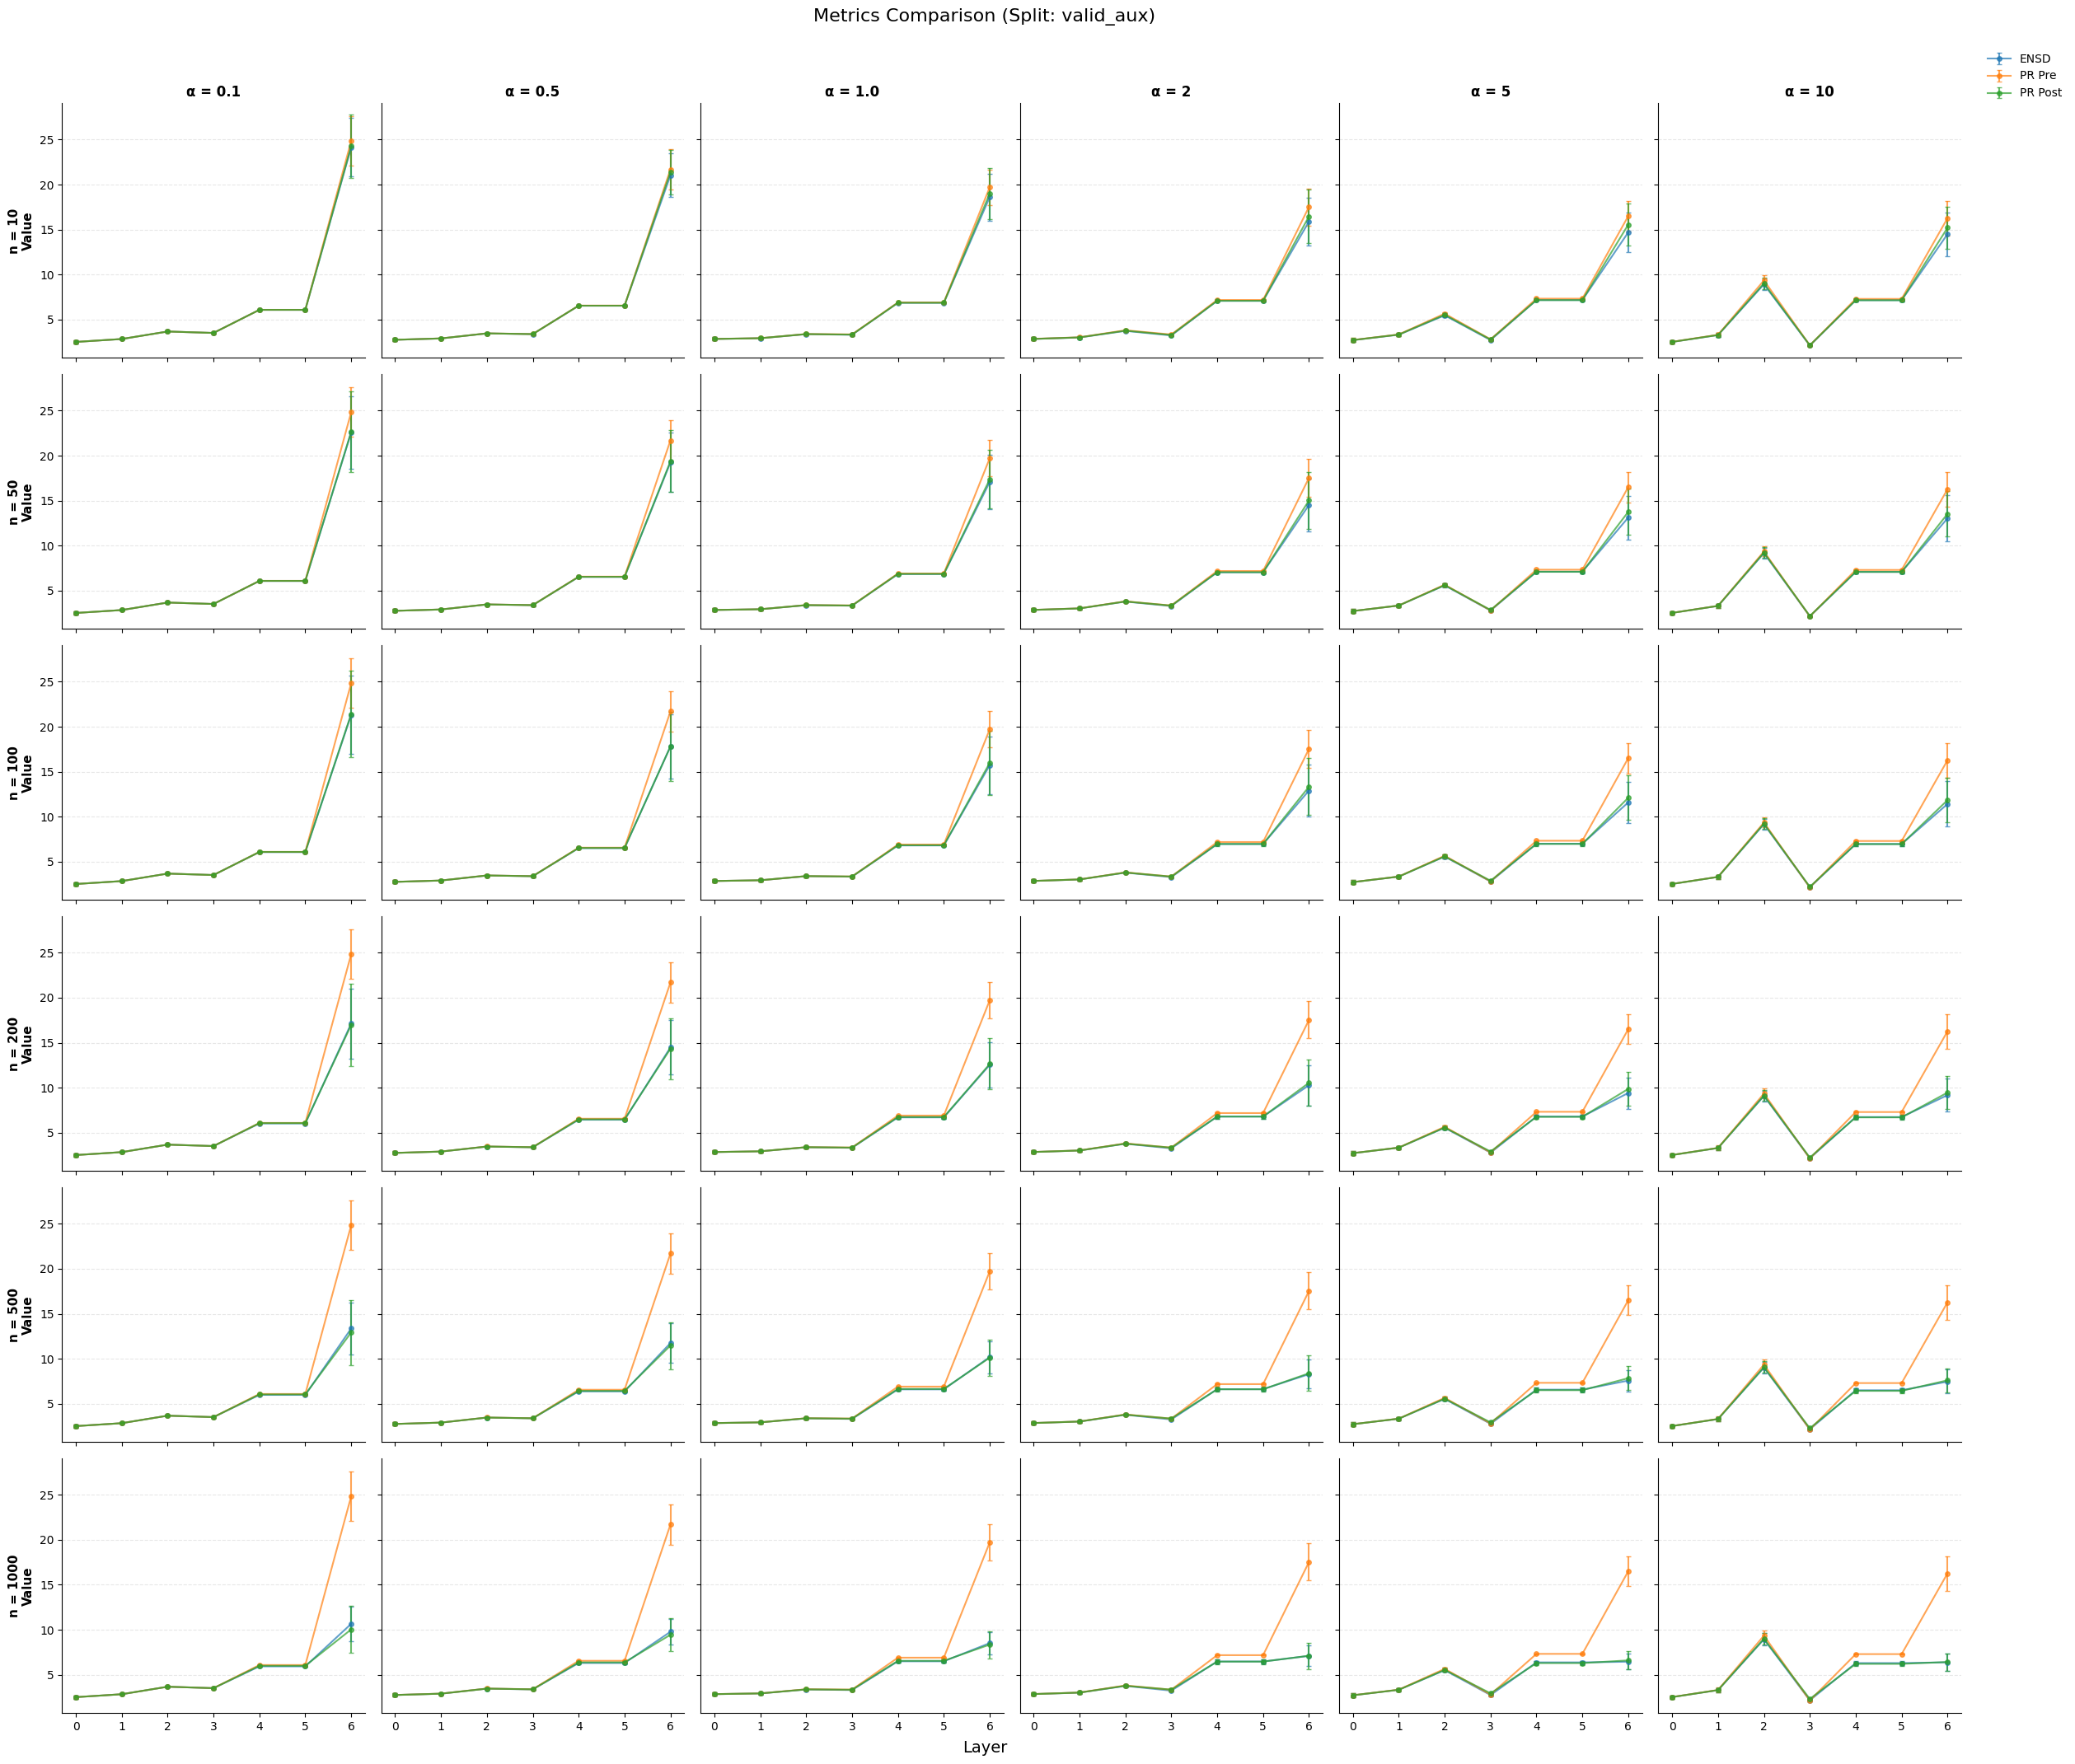

In [2]:

import pandas as pd
import matplotlib.pyplot as plt

def plot_values_by_alpha_grid(
    run_data,
    split_name=None,
    *,
    n_samples=[100],
    alphas=(0.1, 0.5, 1.0),
    seeds=None,
    variables=("ENSD", "PR Pre", "PR Post"),
    split_col=("split", "dataset", "name"),
):
    """
    Creates a single large figure grid.
    Rows = n_samples
    Cols = alphas
    """
    num_samples = len(n_samples)
    num_alphas = len(alphas)

    # Create the grid
    fig, axes = plt.subplots(
        num_samples, num_alphas, 
        figsize=(4 * num_alphas, 3.5 * num_samples),
        sharex=True, 
        sharey=True,
        squeeze=False # Ensures axes is always a 2D array [row, col]
    )

    for row_idx, n_sample in enumerate(n_samples):
        for col_idx, alpha in enumerate(alphas):
            ax = axes[row_idx, col_idx]
            
            # Data retrieval
            df_list = run_data["df"].get(alpha, {}).get(n_sample, [])
            
            if not df_list:
                ax.set_title(f"n={n_sample}, α={alpha} (No Data)", fontsize=10)
                continue

            rows = []
            for df in df_list:
                d = df.copy()
                if seeds is not None and "seed" in d.columns:
                    d = d[d["seed"].isin(seeds)]
                if split_name is not None:
                    found_col = next((c for c in split_col if c in d.columns), None)
                    if found_col is not None:
                        d = d[d[found_col] == split_name]
                
                # Filter specifically for your 3 variables
                d = d[d["variable"].isin(variables)]
                if not d.empty:
                    rows.append(d)

            if not rows:
                continue

            df_all = pd.concat(rows, ignore_index=True)
            stats = (
                df_all.groupby(["variable", "layer"])["value"]
                .agg(mean="mean", std="std")
                .reset_index()
            )

            # Plotting
            for var in variables:
                sub = stats[stats["variable"] == var]
                ax.errorbar(
                    sub["layer"], sub["mean"], yerr=sub["std"].fillna(0),
                    marker="o", markersize=4, label=var, linewidth=1.5, capsize=2, alpha=0.7
                )

            # Labels and Styling
            if row_idx == 0:
                ax.set_title(f"α = {alpha}", fontsize=12, fontweight='bold')
            if col_idx == 0:
                ax.set_ylabel(f"n = {n_sample}\nValue", fontsize=11, fontweight='bold')
            
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.grid(True, axis='y', linestyle='--', alpha=0.3)

    # Global labels
    fig.supxlabel("Layer", fontsize=14)
    fig.suptitle(f"Metrics Comparison (Split: {split_name})", fontsize=16, y=1.02)
    
    # Single legend for the whole figure
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(1.05, 1), frameon=False)

    plt.tight_layout()
    plt.show()

# Execution
plot_values_by_alpha_grid(
    run_data,
    split_name="valid_aux",
    n_samples=[10, 50, 100, 200, 500, 1000],
    alphas = [0.1,0.5,1.0,2,5,10],
    seeds=seeds,
    variables=["ENSD", "PR Pre", "PR Post"])

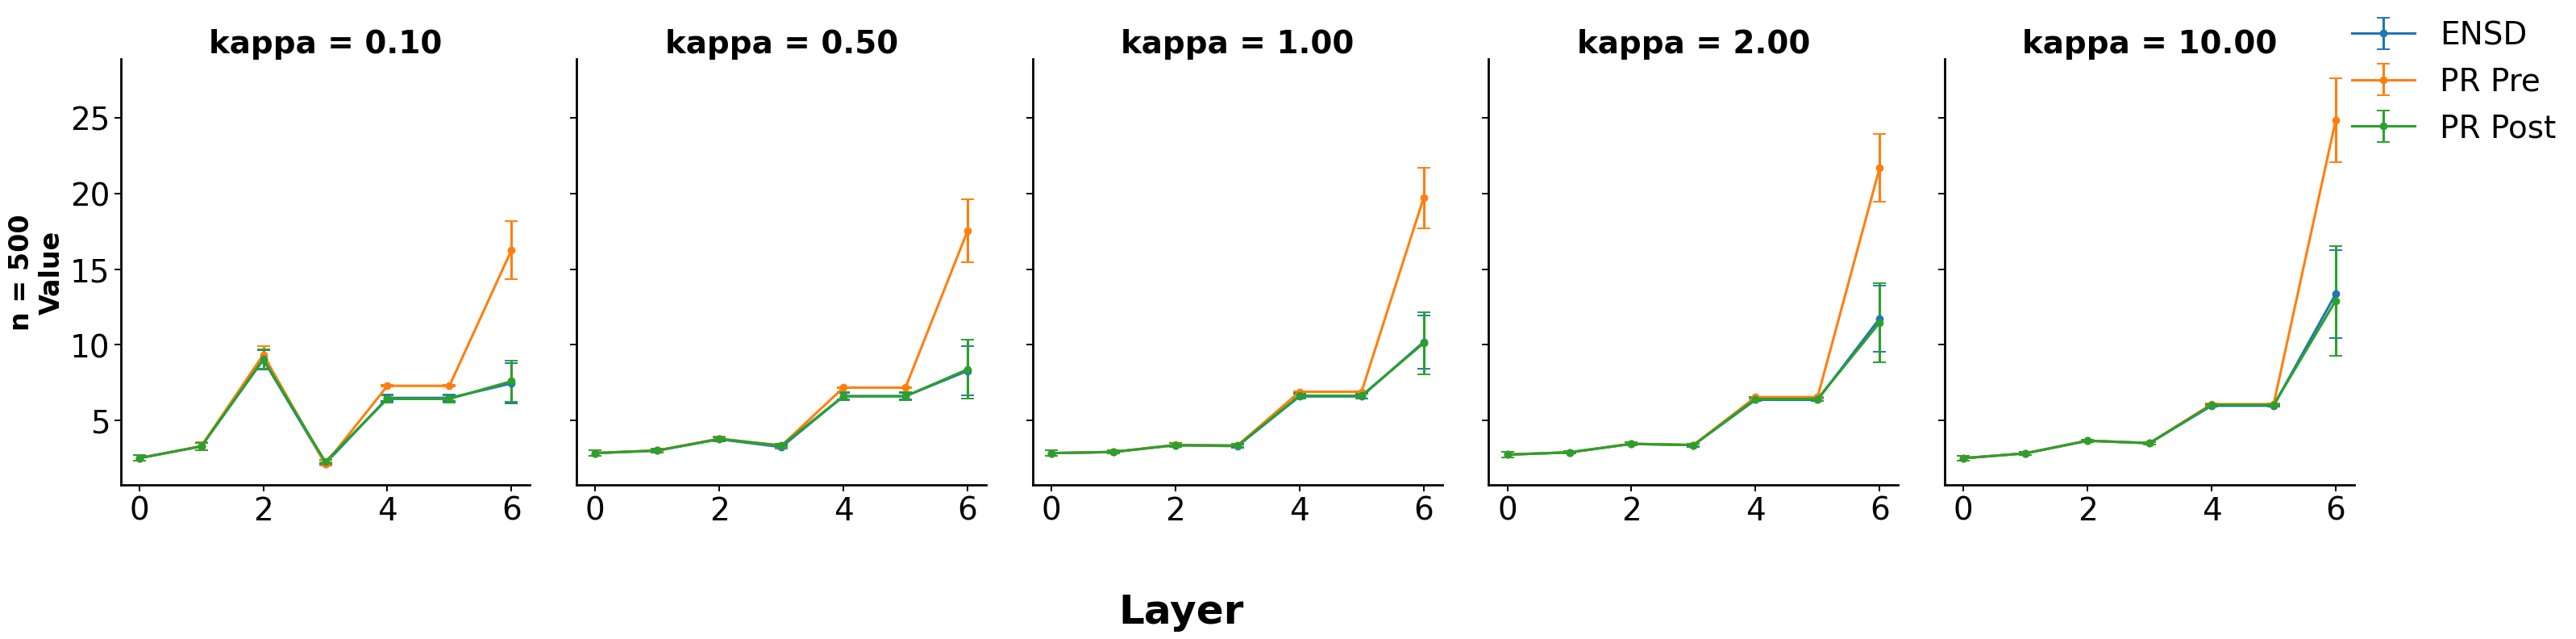

In [117]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

def plot_values_by_alpha_grid(
    run_data,
    split_name=None,
    *,
    n_samples=(100,),
    alphas=(0.1, 0.5, 1.0),
    seeds=None,
    variables=("ENSD", "PR Pre", "PR Post"),
    split_col=("split", "dataset", "name"),
):
    # -----------------------------
    # Global styling (ggplot-like)
    # -----------------------------
    mpl.rcParams.update({
        "font.size": 30,
        "axes.titlesize": 28,
        "axes.labelsize": 24,
        "xtick.labelsize": 28,
        "ytick.labelsize": 28,
        "legend.fontsize": 28,
        "figure.titlesize": 28,
        "axes.linewidth": 2,
    })

    num_rows = len(n_samples)
    num_cols = len(alphas)

    fig, axes = plt.subplots(
        num_rows,
        num_cols,
        figsize=(6 * num_cols, 8 * num_rows),
        sharex=True,
        sharey=True,
        squeeze=False,
    )

    for row_idx, n_sample in enumerate(n_samples):
        for col_idx, alpha in enumerate(alphas):
            ax = axes[row_idx, col_idx]

            df_list = run_data["df"].get(alpha, {}).get(n_sample, [])
            if not df_list:
                ax.set_title(f"n={n_sample}, 1/α={1/alpha:.2f} (No data)")
                continue

            rows = []
            for df in df_list:
                d = df.copy()

                if seeds is not None and "seed" in d.columns:
                    d = d[d["seed"].isin(seeds)]

                if split_name is not None:
                    col = next((c for c in split_col if c in d.columns), None)
                    if col is not None:
                        d = d[d[col] == split_name]

                d = d[d["variable"].isin(variables)]
                if not d.empty:
                    rows.append(d)

            if not rows:
                continue

            df_all = pd.concat(rows, ignore_index=True)

            stats = (
                df_all.groupby(["variable", "layer"])["value"]
                .agg(mean="mean", std="std")
                .reset_index()
            )

            # -----------------------------
            # Plot with caps
            # -----------------------------
            for var in variables:
                sub = stats[stats["variable"] == var]
                ax.errorbar(
                    sub["layer"],
                    sub["mean"],
                    yerr=sub["std"].fillna(0),
                    marker="o",
                    markersize=6,
                    linewidth=2.2,
                    capsize=6,
                    capthick=1.4,
                    label=var,
                )

            # -----------------------------
            # Titles & labels using 1/alpha
            # -----------------------------
            if row_idx == 0:
                ax.set_title(f"kappa = {1/alpha:.2f}", fontweight="bold")

            if col_idx == 0:
                ax.set_ylabel(f"n = {n_sample}\nValue", fontweight="bold")

            # -----------------------------
            # Classic theme styling
            # -----------------------------
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            ax.tick_params(axis="both", width=1.4, length=6)
            ax.grid(False)

    # -----------------------------
    # Global labels
    # -----------------------------
    fig.supxlabel("Layer", fontweight="bold")

    # -----------------------------
    # One legend for all subplots
    # -----------------------------
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="upper right",
        bbox_to_anchor=(1.08, 1.0),
        frameon=False,
    )

    plt.tight_layout()
    plt.show()

plot_values_by_alpha_grid(
    run_data,
    split_name="valid_aux",
    n_samples=[500],
    alphas =[10,2,1.0,0.5,0.1],
    seeds=seeds,
    variables=["ENSD", "PR Pre", "PR Post"])


In [ ]:
# Base results 

In [7]:
import torch
import numpy as np
from pathlib import Path

seeds = list(range(30))
alphas=[1]
base_path = Path("/nfs/scistore19/locatgrp/cdomine/multi-task/data/cifar/pretrain_base/")
run_data = {
    'losses': {a: [] for a in alphas},
    'accs': {a: [] for a in alphas},
    'models': {a: [] for a in alphas},
    'l2_regs': {a: [] for a in alphas}
}

for alpha in alphas:
    for seed in seeds:
        folder_name = (
            f"random_seed={seed}"
            f"--model=resnet"
        )
        print(seed, alpha)
        dir_path = base_path / folder_name
        if dir_path.exists():
            # Load and append data to the lists
            if (dir_path / "losses.npy").exists():
                run_data['losses'][alpha].append(np.load(dir_path / "losses.npy",allow_pickle=True))
                print(f"✅ Loaded Seed {seed}, Alpha {alpha}, Losses")
            if (dir_path / "accs.npy").exists():
                run_data['accs'][alpha].append(np.load(dir_path / "accs.npy",allow_pickle=True))
                print(f"✅ Loaded Seed {seed}, Alpha {alpha}, Accs")
        else:
            print(f"Missing directory: {folder_name}")

# Convert lists to numpy arrays for easier math later: run_data['accs'][0.1] will be (10, epochs)
for metric in ['losses', 'accs','l2_regs']:
    for alpha in alphas:
        if run_data[metric][alpha]:
            run_data[metric][alpha] = np.array(run_data[metric][alpha])




0 1
✅ Loaded Seed 0, Alpha 1, Losses
✅ Loaded Seed 0, Alpha 1, Accs
1 1
✅ Loaded Seed 1, Alpha 1, Losses
✅ Loaded Seed 1, Alpha 1, Accs
2 1
✅ Loaded Seed 2, Alpha 1, Losses
✅ Loaded Seed 2, Alpha 1, Accs
3 1
✅ Loaded Seed 3, Alpha 1, Losses
✅ Loaded Seed 3, Alpha 1, Accs
4 1
✅ Loaded Seed 4, Alpha 1, Losses
✅ Loaded Seed 4, Alpha 1, Accs
5 1
✅ Loaded Seed 5, Alpha 1, Losses
✅ Loaded Seed 5, Alpha 1, Accs
6 1
✅ Loaded Seed 6, Alpha 1, Losses
✅ Loaded Seed 6, Alpha 1, Accs
7 1
✅ Loaded Seed 7, Alpha 1, Losses
✅ Loaded Seed 7, Alpha 1, Accs
8 1
✅ Loaded Seed 8, Alpha 1, Losses
✅ Loaded Seed 8, Alpha 1, Accs
9 1
✅ Loaded Seed 9, Alpha 1, Losses
✅ Loaded Seed 9, Alpha 1, Accs
10 1
✅ Loaded Seed 10, Alpha 1, Losses
✅ Loaded Seed 10, Alpha 1, Accs
11 1
✅ Loaded Seed 11, Alpha 1, Losses
✅ Loaded Seed 11, Alpha 1, Accs
12 1
✅ Loaded Seed 12, Alpha 1, Losses
✅ Loaded Seed 12, Alpha 1, Accs
13 1
✅ Loaded Seed 13, Alpha 1, Losses
✅ Loaded Seed 13, Alpha 1, Accs
14 1
✅ Loaded Seed 14, Alpha 1, Loss

/tmp/ipykernel_534737/2253447913.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(alphas))


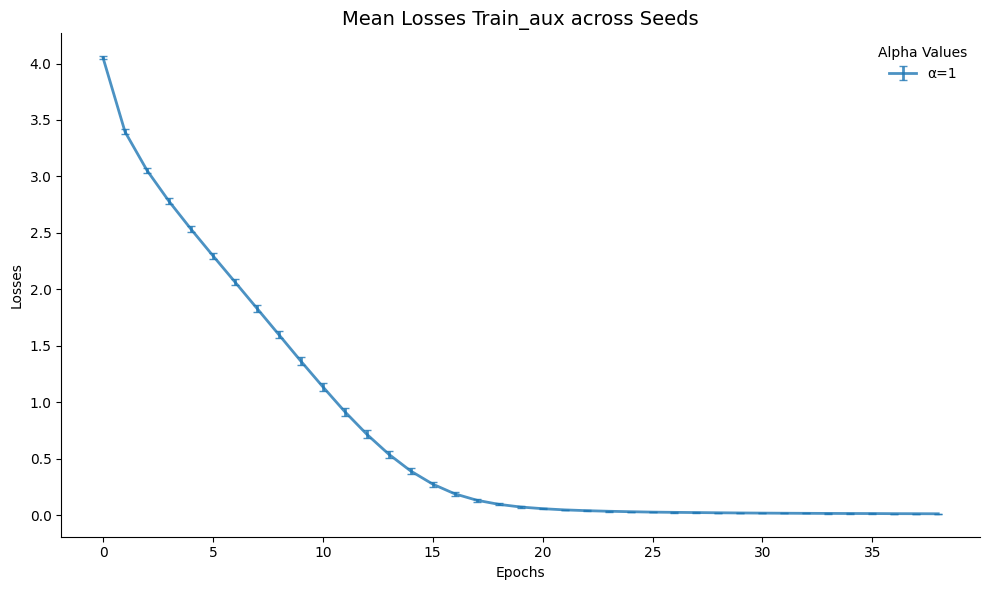

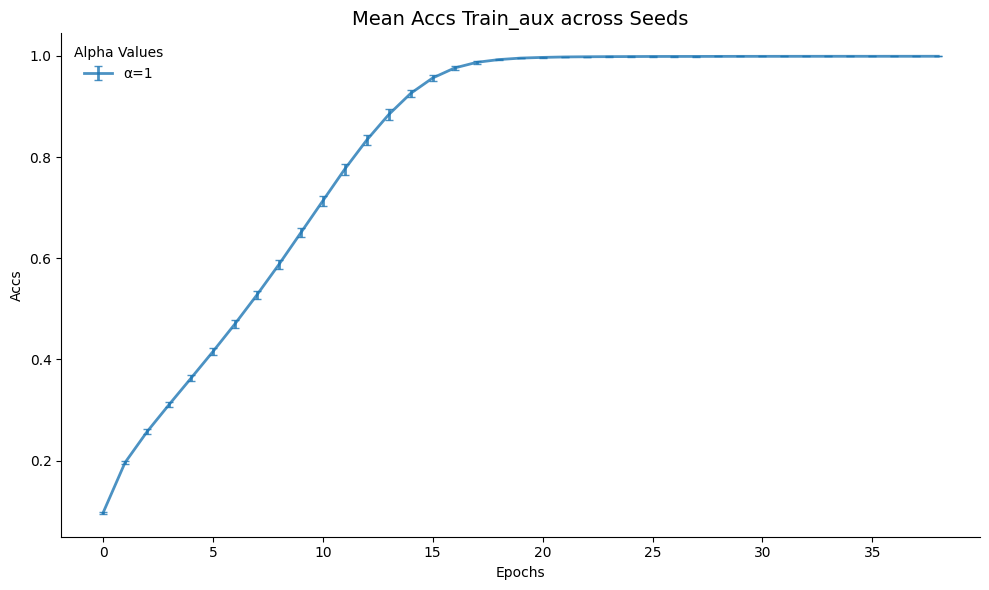

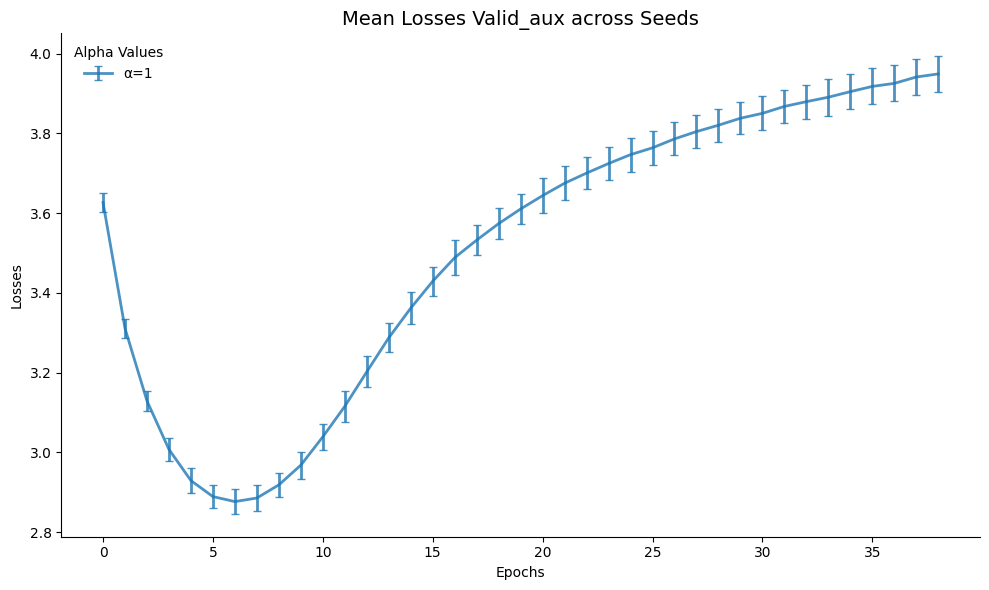

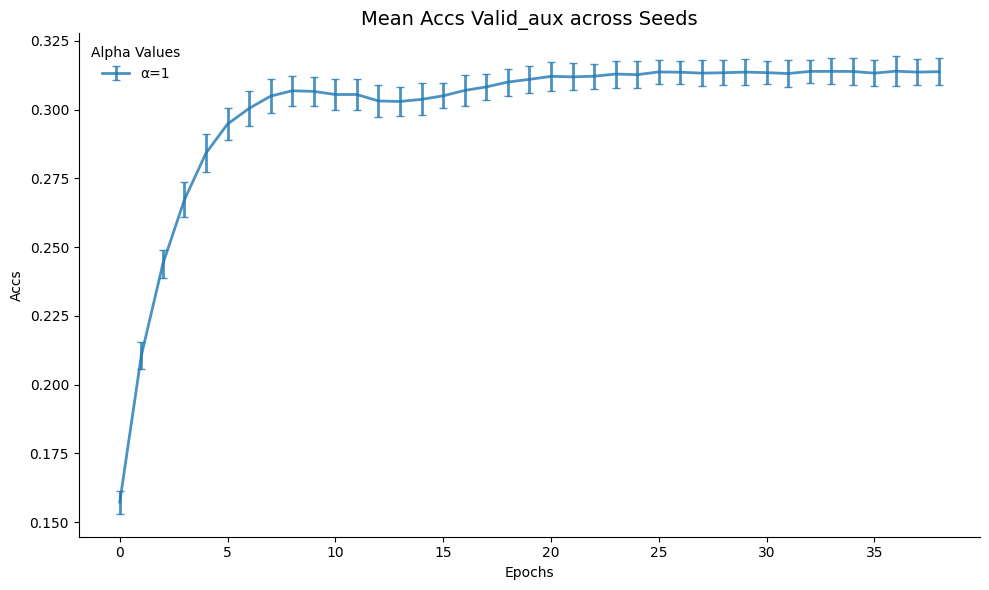

In [11]:
seeds = list(range(30))
plot_metric_across_alphas(run_data, 'losses','train_aux' ,   alphas=[1],seeds=seeds) #plot_metric_across_alphas(run_data, 'losses', alphas=[0.1, 0.5, 1.0])
plot_metric_across_alphas(run_data, 'accs', 'train_aux', alphas=[1],seeds=seeds)
plot_metric_across_alphas(run_data, 'losses','valid_aux' , alphas=[1],seeds=seeds) #plot_metric_across_alphas(run_data, 'losses', alphas=[0.1, 0.5, 1.0])
plot_metric_across_alphas(run_data, 'accs', 'valid_aux' , alphas=[1],seeds=seeds) #

In [61]:
import os
import pandas as pd
import numpy as np
import plotnine as gg
from pathlib import Path

base_path = Path("/nfs/scistore19/locatgrp/cdomine/multi-task/data/cifar/finetune_base/")
output_path = "/nfs/scistore19/locatgrp/cdomine/multi-task/data/cifar/finetune_base_max.csv"

data_list = []

for folder in os.listdir(base_path):
    folder_path = base_path / folder
    acc_file = folder_path / "accs.npy"

    if not acc_file.exists():
        continue

    try:
        # Load accuracy dict
        acc_data = np.load(acc_file, allow_pickle=True).item()

        # Max over time for each metric
        new_df = pd.DataFrame({
            k: [v.max()] for k, v in acc_data.items() if len(v) > 0
        })

        # Parse folder name safely
        parts = folder.split("--")
        params = {p.split("=")[0]: p.split("=")[1] for p in parts}

        new_df["rs"] = int(params.get("random_seed", -1))
        new_df["n_samples"] = int(params.get("n_samples", 0))
        new_df["scaling"] = float(params.get("finetune_scaling", 1.0))
        new_df["model"] = params.get("model", "unknown")

        # Consistent with plotting code
        new_df["mode"] = "finetuning"

        data_list.append(new_df)

    except Exception as e:
        print(f"Skipping {folder} due to error: {e}")

# Combine & save
df = pd.concat(data_list, ignore_index=True)
df.to_csv(output_path, index=False)



/nfs/scistore19/locatgrp/cdomine/miniforge3/envs/NPG-env/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
/nfs/scistore19/locatgrp/cdomine/miniforge3/envs/NPG-env/lib/python3.12/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_summary : Removed 5 rows containing non-finite values.
/nfs/scistore19/locatgrp/cdomine/miniforge3/envs/NPG-env/lib/python3.12/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_summary : Removed 5 rows containing non-finite values.


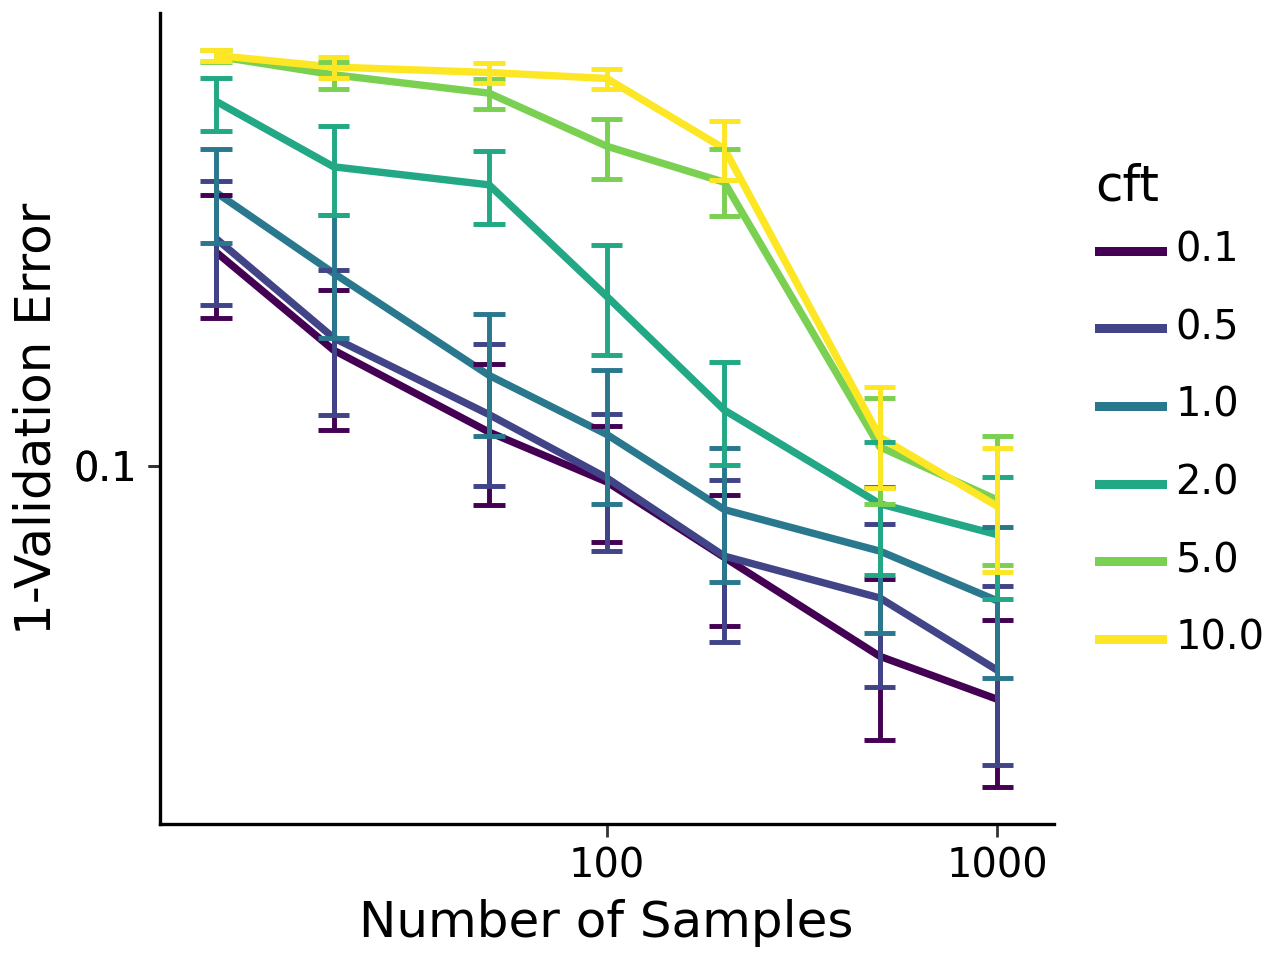

In [65]:
x_breaks = [100, 1000, 10000] 
y_breaks = [0.1, 0.1]    

df_plot = df[df['scaling'] != 5]
df_plot = df[df['scaling'] != 0.01]
(
    gg.ggplot(
        df_plot,
        gg.aes(
            x='n_samples',
            y='1-valid',
            color='factor(scaling)',
            group='scaling'
        )
    ) +
    gg.stat_summary(geom='line', size=1.5) +
    gg.stat_summary(
        geom='errorbar',
        size=1.0,
        width=0.08
    ) +
    gg.scale_x_log10(breaks=x_breaks) +
    gg.scale_y_log10(breaks=y_breaks) +
    gg.scale_color_cmap_d(name='cft') +
    gg.theme_classic(base_size=18) +
    gg.labs(
        x="Number of Samples",
        y="1-Validation Error",
        color="Alpha Load"
    ) +
    gg.theme(
        panel_grid_major=gg.element_blank(),
        panel_grid_minor=gg.element_blank(),
        axis_text=gg.element_text(color="black"),
        axis_line=gg.element_line(size=1.2)
    )
)


In [ ]:
import torch
import numpy as np
from pathlib import Path
seeds = list(range(30))
alphas = [0.1,0.5,1.0,2,5,10]
 #/nfs/gatsbystor/cdomine/cifar_testing/cifar/main_3/
n_samples=[10, 20, 50, 100, 200, 500, 1000]
#random_seed=0--mode=finetuning--n_samples=10--alpha=1.0--alpha_policy=first_vs_rest--model=resnet
base_path = Path("/nfs/scistore19/locatgrp/cdomine/multi-task/data/cifar/finetune_base/")
 #base_path = Path("/nfs/nhome/live/cdomine/nested_feature/experiments/cifar/data/cifar/main_3/")
run_data = {
    'losses': {a:{s: [] for s in n_samples} for a in alphas},
    'accs': {a: {s: [] for s in n_samples} for a in alphas},
    'models': {a: {s: [] for s in n_samples} for a in alphas},
    'l2_regs': {a: {s: [] for s in n_samples} for a in alphas}
}
for alpha in alphas:
    for seed in seeds:
        for n_sample in n_samples :
            folder_name = (
                f"random_seed={seed}--n_samples={n_sample}--finetune_scaling={alpha}--model=resnet"
            )
            dir_path = base_path / folder_name
            if dir_path.exists():
              #    print(f" {seed}, Alpha {alpha}, Sample {n_sample}, Accs"),
                # Load and append data to the lists
                if (dir_path / "losses.npy").exists():
                    run_data['losses'][alpha][n_sample].append(np.load(dir_path / "losses.npy",allow_pickle=True))
                    print(f"✅ Loaded Seed {seed}, Alpha {alpha}, Sample {n_sample}, Losses")
                if (dir_path / "l2_regs.npy").exists():
                    run_data['l2_regs'][alpha][n_sample].append(np.load(dir_path / "l2_regs.npy",allow_pickle=True))
                    print(f"✅ Loaded Seed {seed}, Alpha {alpha}, Sample {n_sample}, l2_regs")
                if (dir_path / "accs.npy").exists():
                    run_data['accs'][alpha][n_sample].append(np.load(dir_path / "accs.npy",allow_pickle=True))
                   #   print(f"✅ Loaded Seed {seed}, Alpha {alpha}, Sample {n_sample}, Accs"),
            else:
                print(f"Missing directory: {folder_name}")

✅ Loaded Seed 0, Alpha 0.1, Sample 10, Losses
✅ Loaded Seed 0, Alpha 0.1, Sample 20, Losses
✅ Loaded Seed 0, Alpha 0.1, Sample 50, Losses
✅ Loaded Seed 0, Alpha 0.1, Sample 100, Losses
✅ Loaded Seed 0, Alpha 0.1, Sample 200, Losses
✅ Loaded Seed 0, Alpha 0.1, Sample 500, Losses
✅ Loaded Seed 0, Alpha 0.1, Sample 1000, Losses
✅ Loaded Seed 1, Alpha 0.1, Sample 10, Losses
✅ Loaded Seed 1, Alpha 0.1, Sample 20, Losses
✅ Loaded Seed 1, Alpha 0.1, Sample 50, Losses
✅ Loaded Seed 1, Alpha 0.1, Sample 100, Losses
✅ Loaded Seed 1, Alpha 0.1, Sample 200, Losses
✅ Loaded Seed 1, Alpha 0.1, Sample 500, Losses
✅ Loaded Seed 1, Alpha 0.1, Sample 1000, Losses
✅ Loaded Seed 2, Alpha 0.1, Sample 10, Losses
✅ Loaded Seed 2, Alpha 0.1, Sample 20, Losses
✅ Loaded Seed 2, Alpha 0.1, Sample 50, Losses
✅ Loaded Seed 2, Alpha 0.1, Sample 100, Losses
✅ Loaded Seed 2, Alpha 0.1, Sample 200, Losses
✅ Loaded Seed 2, Alpha 0.1, Sample 500, Losses
✅ Loaded Seed 2, Alpha 0.1, Sample 1000, Losses
✅ Loaded Seed 3, Al

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm


def _err_from_vals(vals, error_type="se"):
    vals = np.asarray(vals, dtype=float)
    mean = float(np.mean(vals))
    std = float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0
    err = std if error_type == "std" else std / np.sqrt(len(vals))
    return mean, err


def plot_merged_run_and_csv(
    run_data,
    metric_name,
    type_val,
    alphas,
    seeds,
    samples,
    log_x=True,
    use_one_minus_acc=True,
    error_type="se",
):
    assert error_type in {"std", "se"}

    fig, ax = plt.subplots(figsize=(10, 6))

    # ---- colormap with LOG-scaled alpha ----
    cmap = plt.colormaps["viridis"] if hasattr(plt, "colormaps") else plt.cm.get_cmap("viridis")
    norm = LogNorm(vmin=min(alphas), vmax=max(alphas))

    metric_lower = str(metric_name).lower()
    do_one_minus_run = use_one_minus_acc and ("acc" in metric_lower or "accuracy" in metric_lower)

    # --------- RUN_DATA PLOT ----------
    for alpha in alphas:
        means, errs = [], []

        for sample in samples:
            vals = []
            for seed in seeds:
                try:
                    data_matrix = run_data[metric_name][alpha][sample]
                    v = data_matrix[seed]
                    data_dict = v.item() if hasattr(v, "item") else v

                    y = np.max(data_dict[type_val])
                    if do_one_minus_run:
                        y = 1.0 - y

                    # protect log plots
                    if y <= 0:
                        continue

                    vals.append(y)

                except (KeyError, IndexError, TypeError, ValueError):
                    continue

            if len(vals) == 0:
                means.append(np.nan)
                errs.append(np.nan)
            else:
                m, e = _err_from_vals(vals, error_type)
                means.append(m)
                errs.append(e)

        if np.all(np.isnan(means)):
            print(f"[WARN] α={alpha} produced all-NaN. Skipping.")
            continue

        ax.errorbar(
            samples,
            means,
            yerr=errs,
            label=f"c_pt={alpha}",
            color=cmap(norm(alpha)),
            marker="o",
            linestyle="-",
            linewidth=2.5,
            capsize=4,
            alpha=0.95,
            zorder=3,
        )

    # --------- Styling ----------
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if log_x:
        ax.set_xscale("log")

    ax.set_xlabel("Sample Size", fontsize=11)
    ax.set_ylabel("1 − Accuracy", fontsize=11)

    ax.legend(frameon=False)
    ax.yaxis.grid(True, linestyle="--", alpha=0.3)

    # --------- Log-scaled colorbar ----------
    # sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    # sm.set_array([])
    # cbar = plt.colorbar(sm, ax=ax, pad=0.02)
    # cbar.set_label("c_pt (alpha)", rotation=270, labelpad=15)

    plt.tight_layout()
    plt.show()



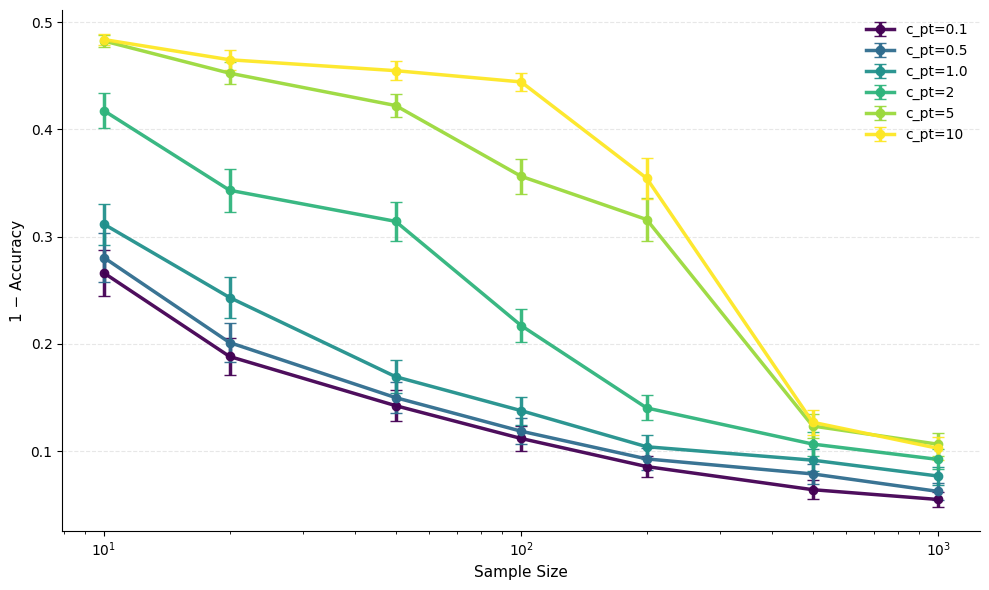

In [14]:
plot_merged_run_and_csv(
    run_data=run_data,
    #csv_path="/nfs/nhome/live/cdomine/nested_feature/experiments/cifar/data/cifar/resnet_acc_max.csv",
    metric_name="accs",
    type_val="valid",
    alphas = [0.1,0.5,1.0,2,5,10],
    seeds=list(range(50)),
    samples=[10, 20, 50, 100, 200, 500, 1000],
    error_type="se")

In [112]:
import torch
import numpy as np
import pandas as pd
from pathlib import Path

# --- Configuration ---
seeds = list(range(20))
n_samples= [10, 50, 100, 200, 500, 1000]
alphas = [0.1,0.5,1.0,2,5,10]
base_path = Path("/nfs/scistore19/locatgrp/cdomine/multi-task/data/cifar/ensd_base/")


# Nested dictionary for structured access
run_data = {
    "df": {a: {s: [] for s in n_samples} for a in alphas},
}
all_long = []  # Stores long-format rows for every run
all_wide = []  # Stores wide-format per run

# --- Data Loading Loop ---
for alpha in alphas:
    for seed in seeds:
        for n_sample in n_samples:
            # Construct folder name based on experimental parameters
            folder_name = (
                f"random_seed={seed}--n_samples={n_sample}--scaling={alpha}"
            ) 
           
            dir_path = base_path / folder_name
            csv_path = dir_path / "df.csv"

            if not csv_path.exists():
                print(f'not downloaded {csv_path}')
                continue

            # --- Read CSV (long format: value, variable, layer) ---
            df = pd.read_csv(csv_path)

            # Cleanup: drop stray index column if present
            if "Unnamed: 0" in df.columns:
                df = df.drop(columns=["Unnamed: 0"])

            # Ensure expected columns exist
            expected = {"value", "variable", "layer"}
            missing = expected - set(df.columns)
            if missing:
                raise ValueError(f"{csv_path} is missing columns: {missing}")

            # Enforce data types
            df["value"] = df["value"].astype(float)
            df["layer"] = df["layer"].astype(int)

            # Add metadata for filtering/grouping
            df["alpha"] = float(alpha)
            df["seed"] = int(seed)
            df["n_samples"] = int(n_sample)

            # Save in nested structure and global list
            run_data["df"][alpha][n_sample].append(df)
            all_long.append(df)
            # --- Optional: build wide-format for this run ---
            # Transforms: Layer | Variable_A_Value | Variable_B_Value
            df_wide = (
                df.pivot(index="layer", columns="variable", values="value")
                  .reset_index()
            )
            df_wide["alpha"] = float(alpha)
            df_wide["seed"] = int(seed)
            df_wide["n_samples"] = int(n_sample)
            all_wide.append(df_wide)

# --- Final Aggregation ---
if all_long:
    df_all_long = pd.concat(all_long, ignore_index=True)
else:
    df_all_long = pd.DataFrame()

if all_wide:
    df_all_wide = pd.concat(all_wide, ignore_index=True)
else:
    df_all_wide = pd.DataFrame()
print("All long-format rows:", df_all_long.shape)
print("All wide-format rows:", df_all_wide.shape)



All long-format rows: (20160, 6)
All wide-format rows: (5040, 8)


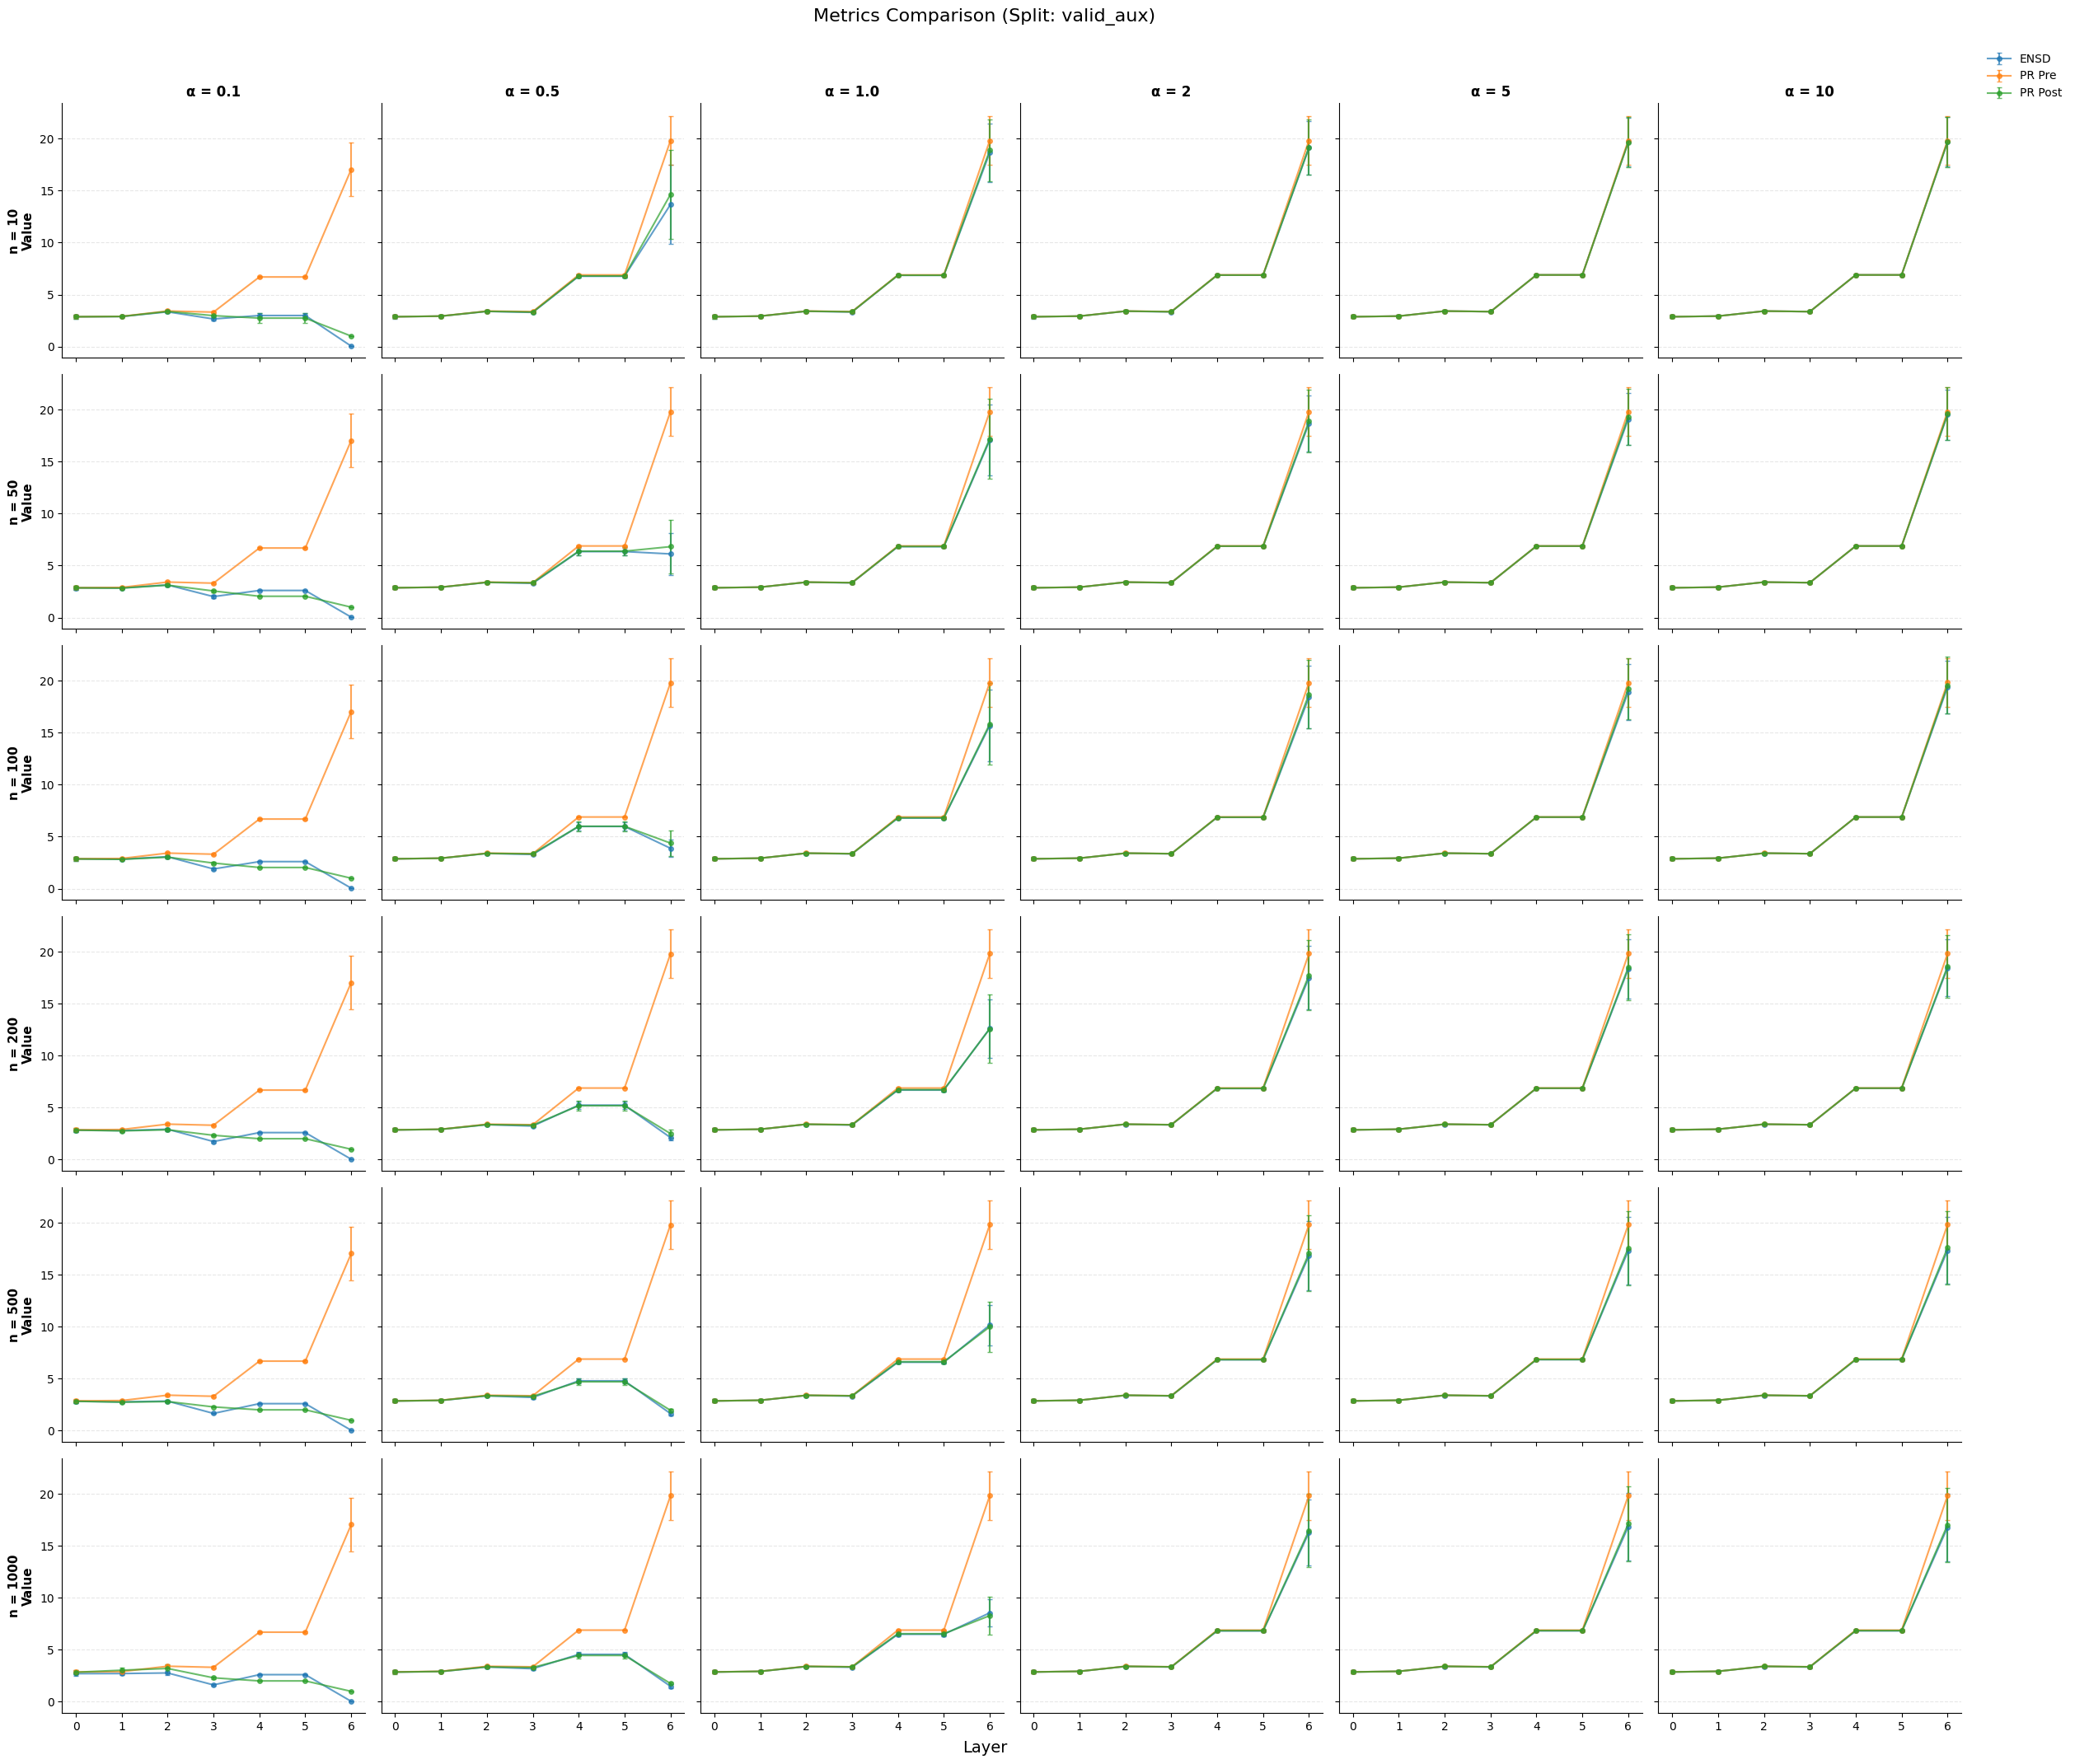

In [ ]:

# Execution


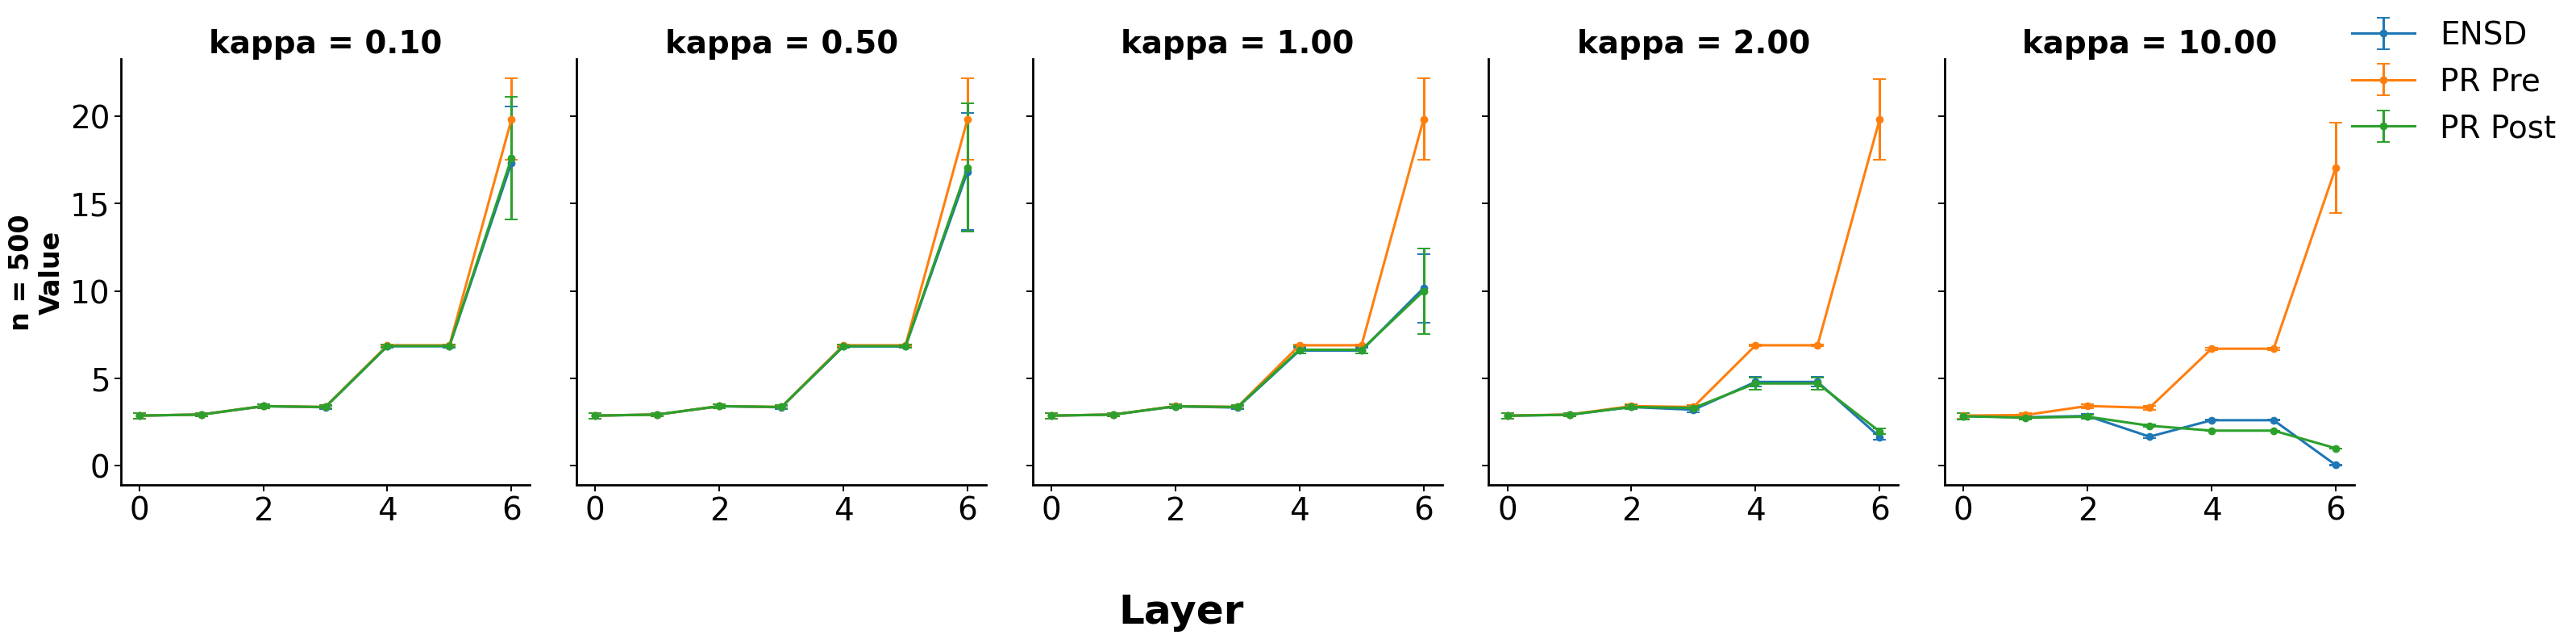

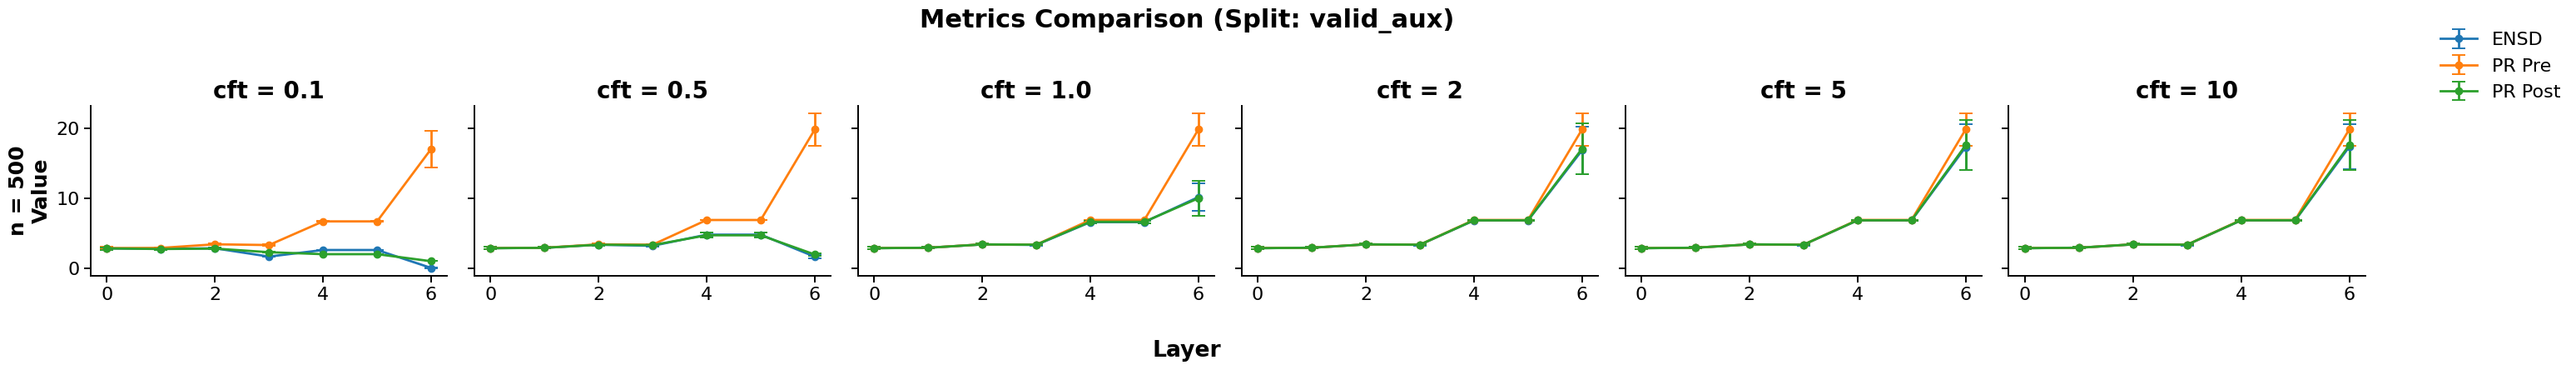

In [115]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

def plot_values_by_alpha_grid(
    run_data,
    split_name=None,
    *,
    n_samples=(100,),
    alphas=(0.1, 0.5, 1.0),
    seeds=None,
    variables=("ENSD", "PR Pre", "PR Post"),
    split_col=("split", "dataset", "name"),
):
    # -----------------------------
    # Global styling (ggplot-like)
    # -----------------------------
    mpl.rcParams.update({
        "font.size": 16,
        "axes.titlesize": 20,
        "axes.labelsize": 18,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 16,
        "figure.titlesize": 22,
        "axes.linewidth": 1.4,
    })

    num_rows = len(n_samples)
    num_cols = len(alphas)

    fig, axes = plt.subplots(
        num_rows,
        num_cols,
        figsize=(4.8 * num_cols, 4.2 * num_rows),
        sharex=True,
        sharey=True,
        squeeze=False,
    )

    for row_idx, n_sample in enumerate(n_samples):
        for col_idx, alpha in enumerate(alphas):
            ax = axes[row_idx, col_idx]

            df_list = run_data["df"].get(alpha, {}).get(n_sample, [])
            if not df_list:
                ax.set_title(f"n={n_sample}, α={alpha} (No data)")
                continue

            rows = []
            for df in df_list:
                d = df.copy()

                if seeds is not None and "seed" in d.columns:
                    d = d[d["seed"].isin(seeds)]

                if split_name is not None:
                    col = next((c for c in split_col if c in d.columns), None)
                    if col is not None:
                        d = d[d[col] == split_name]

                d = d[d["variable"].isin(variables)]
                if not d.empty:
                    rows.append(d)

            if not rows:
                continue

            df_all = pd.concat(rows, ignore_index=True)

            stats = (
                df_all.groupby(["variable", "layer"])["value"]
                .agg(mean="mean", std="std")
                .reset_index()
            )

            # -----------------------------
            # Plot with caps
            # -----------------------------
            for var in variables:
                sub = stats[stats["variable"] == var]
                ax.errorbar(
                    sub["layer"],
                    sub["mean"],
                    yerr=sub["std"].fillna(0),
                    marker="o",
                    markersize=6,
                    linewidth=2.0,
                    capsize=6,
                    capthick=1.4,
                    label=var,
                )

            # -----------------------------
            # Titles & labels
            # -----------------------------
            if row_idx == 0:
                ax.set_title(f"cft = {alpha}", fontweight="bold")

            if col_idx == 0:
                ax.set_ylabel(f"n = {n_sample}\nValue", fontweight="bold")

            # -----------------------------
            # Classic theme styling
            # -----------------------------
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            ax.tick_params(axis="both", width=1.4, length=6)
            ax.grid(False)

    # -----------------------------
    # Global labels
    # -----------------------------
    fig.supxlabel("Layer", fontweight="bold")
    fig.suptitle(
        f"Metrics Comparison (Split: {split_name})",
        y=1.02,
        fontweight="bold",
    )

    # -----------------------------
    # One legend for all subplots
    # -----------------------------
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="upper right",
        bbox_to_anchor=(1.08, 1.0),
        frameon=False,
    )

    plt.tight_layout()
    plt.show()
plot_values_by_alpha_grid(
    run_data,
    split_name="valid_aux",
    n_samples=[500],
    alphas =[0.1,0.5,1.0,2,5,10],
    seeds=seeds,
    variables=["ENSD", "PR Pre", "PR Post"])